# Forecast Direction: прогнозирование направления движения цены

## Описание проекта

Проект для портфолио, демонстрирующий навыки работы с временными рядами, EDA для финансовых данных, построение и оценку моделей бинарной классификации направления цены (up/down), работу с лагами и скользящими признаками, проверку сезонности и автокорреляции, а также подготовку интерпретируемых выводов.

__Цель проекта:__
- Разработать интерпретируемую модель машинного обучения для бинарной классификации, которая по историческим дневным данным по инструменту (open, high, low, close, vol) предсказывает направление движения цены на следующий день (target = 1, если цена закрытия завтра будет выше, чем сегодня; target = 0 — если ниже или равно).
  - не просто обучить модель, а построить устойчивый пайплайн, избегая "заглядывания в будущее" (look-ahead bias), и оценить её реальную предсказательную силу.
- Обосновать выбор метрик и подхода к валидации с учётом временной структуры данных

__Актуальность и бизнес-ценность:__
- Прогнозирование движения цен на финансовых рынках является ключевой задачей для трейдеров, инвестиционных фондов и алгоритмических систем.
- Даже небольшое преимущество в предсказании направления (выше/ниже) позволяет строить прибыльные торговые стратегии, управлять рисками и хеджировать позиции.
- В отличие от предсказания точной цены, предсказание направления (Binary Classification) более устойчиво к шуму и часто используется в реальной торговле для генерации сигналов.

__Практическая ценность:__
- Оценка вероятности направления движения цены (рост/падение).
- Формирование простых торговых/аналитических сигналов (например, «ожидается рост»).
- Понимание, какие факторы (признаки) лучше всего объясняют направление движения.

## Выбор метрики

Поскольку задача—бинарная классификация направления цены и классы могут быть несбалансированны (рынок не всегда движется вверх 50% времени), а ложные сигналы стоят денег, метрики нужно выбирать исходя из реалистичного торгового подхода.:
- __Основные метрики:__
  - F1-score (для класса 1, если классы несбалансированы).
    - Важен баланс между тем, чтобы не пропустить прибыльное движение (Recall) и не входить в убыточные сделки (Precision).
  - Precision и Recall для класса 1 (например, «рост»).
- __Дополнительные метрики:__
  - ROC-AUC — общая способность отделять классы (чем ближе к 1, тем лучше).
  - PR-AUC — если классы сильно несбалансированы (например, дней роста меньше, чем дней падения).
  - Accuracy — доля правильных предсоложений направления.

Бизнес-интерпретация:
- если важнее не пропускать движения в определённую сторону—делаем акцент на Recall;
- если важнее избегать ложных сигналов—делаем акцент на Precision.

## Описание данных

Данные представляют собой стандартный временной ряд OHLCV (Open, High, Low, Close, Volume) за период с 2014 по 2024 год с колонками:
- __date__ — дата (дневные бары) торгов.
- __open__ — цена открытия.
- __high__ — максимальная цена за день.
- __low__ — минимальная цена за день.
- __close__ — цена закрытия (ключевая метрика для расчета таргета).
- __vol__ — объём торгов.
- __target__ — направление движения цены на следующий день (бинарная целевая переменная: 0/1).
  - 1: Цена закрытия завтра (close на t+1) будет выше цены закрытия сегодня (close на t).
  - 0: Цена закрытия завтра будет ниже или равна сегодняшней.

__Особенности:__
- Временная структура: данные идут по датам, важно сохранять хронологию.
- Целевая переменная: уже сформирована как направление на следующий день (нужно проверить, нет ли утечки).
- Финансовая природа: возможны тренды, волатильность, сезонность (по дням недели, месяцам, фазам рынка).
- Индексация по времени критична — перемешивать данные при кросс-валидации стандартным способом (K-Fold) нельзя.

Финальное качество модели будет оцениваться не только по стандартным метрикам при пороге 0.5, но и с учётом возможности выбора порога (threshold-tuning) под конкретную бизнес-задачу (минимизация ложных срабатываний или максимизация обнаружения движений).

## Цели исследования

__Основные цели:__
- Построить модель бинарной классификации, предсказывающую target (направление цены на следующий день).
- Выбрать и обосновать метрики качества, учитывая бизнес-смысл (ложные сигналы vs пропуск движения).
- Показать метрики и матрицу ошибок на трейне и тесте (как требует задание).

__Аналитические цели:__
- Проверить временную структуру:
  - монотонность дат;
  - пропуски дат (выходные/праздники).
- Изучить свойства ряда:
  - тренды, сезонность, волатильность;
  - автокорреляция и значимость лагов.
- Выявить полезные признаки:
  - лаги цен и доходностей;
  - скользящие средние, волатильность;
  - технические индикаторы (по желанию).

__Моделирование:__
- Сравнить несколько моделей (логистическая регрессия, деревья/ансамбли).
- Использовать time series split (валидация по времени, без перемешивания).
- Оценить устойчивость модели на отложенном тесте.

## Ход исследования

Шаг 1: Загрузка, первичный осмотр и предобработка данных
- Загрузка данных
- Преобразование типов
- Проверка структуры
- Проверка временной структуры:
  - монотонность дат
  - пропуски дат
- Обработка пропусков
- Проверка дубликатов
- Проверка целевой переменной:
  - распределение target (баланс классов)
  - логическая проверка target:
    - действительно ли target соответствует направлению close_{t+1} - close_t
    - рассчитать target_check = (close.shift(-1) > close).astype(int) и сравнить с исходным столбцом target

Шаг 2: Feature Engineering (создание признаков)
- 2.1. Базовые признаки:
  - Размер свечи (тело):
    - body = abs(close - open)
  - Тень свечи (верхняя/нижняя):
    - upper_shadow = high - max(open, close),
    - lower_shadow = min(open, close) - low
  - Диапазон дня:
    - high_low_ratio = (high - low) / open (волатильность дня)    
  - Доходности:
    - return_1d (текущая дневная доходность);
    - лаги доходностей: return_lag1, return_lag2, ….
  - Лаги цены закрытия и объема:
    - close_lag1, close_lag2, … (если нужно)
    - vol_lag1...
  - "Gap" (Разрывов) между сессиями
    - overnight_return = (open_t / close_t-1) - 1
- 2.2. Скользящие статистики (Rolling Windows):
  - Скользящее среднее цены закрытия за N дней:
    - sma_5, sma_10, sma_20, sma 50
  - Расстояние текущей цены от скользящего среднего:
    - close / SMA_20 - 1
  - Скользящая стандартное отклонение (волатильность) за 5, 20 дней:
    - rolling_std_5, rolling_std_10 по return_1d
  - Скользящие по объёму:
    - vol_ma_5, vol_ma_10
  - Скользящие максимумы/минимумы 
- 2.3. Технические индикаторы:
  - Momentum / ROC: разница между текущей ценой и ценой N дней назад
  - RSI (Индекс относительной силы) за 14 дней
- 2.4. Календарные признаки:
  - day_of_week (0–4): понедельник часто бывает волатильным
  - month: эффект календаря, например, "эффект января"
  
Важно:
  - Все признаки должны использовать только информацию из прошлого (лаговые и скользящие окна), чтобы не было утечки в будущее
  - Целевую переменную target не трогаем

Шаг 3: Исследовательский анализ данных (EDA) для временных рядов
- 3.1. Базовые распределения:
  - Распределение целевой переменной target
  - Распределения цен и объёма
  - Распределение доходностей (log returns)
  - Ящик с усами для анализа выбросов
  - Проверка нормальности распределения доходностей:
    - Q-Q plot
    - тест Шапиро–Уилка
    - анализ хвостов распределения
- 3.2. Временные графики:
  - close vs date (общий тренд)
    - отметить на графике точки, где target=1 (зеленым) и target=0 (красным), чтобы увидеть тренды.
  - vol vs date (изменение активности)
  - распределние доходности
- 3.3. Декомпозиция и сезонность:
  - Декомпозиция временного ряда close
  - Сезонность
  - Скользящее стандартное отклонение остатков
- 3.4. Автокорреляция и лаги:
  - Проверка стационарности
  - ACF/PACF
- 3.5. Корреляционный анализ:
  - построить тепловую карту корреляций Пирсона между признаками
  - исключить мультиколлинеарность

Шаг 4: Подготовка к моделированию
- 4.1 Выбор признаков для модели на основе EDA
- 4.2. Удаление Look-Ahead Bias и обработка пропусков:
  - проверить созданные признаки на наличие inf и NaN
  - из-за создания лагов и скользящих окон первые N строк станут NaN.
  - их нужно удалить (dropna()), так как модели не работают с пропусками
- 4.3. Проверка утечки данных (Data Leakage)
- 4.4. Формирование выборок:
  - разделение на признаки и цель
- 4.5. Разделение на train/valid/test с учётом времени:
  - train/valid через TimeSeriesSplit и  Walk-Forward Validation (кросс-валидация по времени)
  - схема: обучаемся на прошлом, валидируемся на будущем:
    - Train: 2014 – 2021
    - Validation: 2022 – 2023
    - Test: 2024 (последние данные, которые не трогали до самого конца)
- 4.6. Масштабирование и кодирование:
  - StandardScaler или RobustScaler(устойчив к выбросам)  по числовым признакам
  - fit только на train, transform на train/valid/test

Шаг 5: Моделирование
- 5.1. Бейзлайн: DummyClassifier:
  - стратегия: "most_frequent","stratified", "naive strategy"
    - "naive strategy": «наивный» финансовый бейзлайн
  - покажет, насколько наша модель лучше простого угадывания
- 5.2. Логистическая регрессия LogReg:
  - с регуляризацией (L2)
  - со стандартизацией признаков
  - оценка коэффициентов (какие признаки увеличивают вероятность роста)
- 5.3. Модели деревьев и ансамблей:
  - Decision TreeClassifier — как базовый нелинейный алгоритм
  - RandomForestClassifier, Gradient Boosting (XGBoost/LightGBM):
    - подбор гиперпараметров (GridSearchCV или RandomizedSearchCV) с TimeSeriesSplit
    - сравнение по выбранной основной метрике (например, F1 или ROC-AUC)
- 5.4. Валидация и выбор лучшей модели: 
  - использовать TimeSeriesSplit
  - для каждой модели:
    - метрики на train и validation (или через кросс-валидацию)
    - проверка на переобучение (слишком высокий train vs низкий test)
  - выбор лучшей модели по основной метрике
    - сравнить модели по F1-score на валидационной выборке и выбрать лучшую.
- 5.5 Выбор порога (по умолчанию порог 0.5):
  - как меняются Precision/Recall при изменении порога
  - выбрать порог под конкретную «стратегию» (например, повышаем Precision, чтобы уменьшить ложные сигналы)
- 5.6 Калибровка вероятностей:
  - Platt scaling или Isotonic Regression
  - сравнение калиброванных и некалиброванных вероятностей

Шаг 6: Оценка на тесте и визуализация результатов
- 6.1. Метрики для выбранной лучшей модели на тесте:
  - Accuracy,Directional Accuracy, Precision, Recall, F1, ROC-AUC
  - отчёт classification_report (precision, recall, f1-score)
- 6.2. Матрица ошибок Confusion matrix на тесте:
  - Интерпретация:
    - сколько верных предсказаний роста/падения
    - сколько ложных сигналов
    - сколько пропущенных движений
- 6.3. ROC и PR-кривые на тесте
- 6.4. Проверка распределения ошибок модели на тесте
- 6.5. Анализ стабильности модели во времени:
  - метрики по годам или кварталам;
  - проверка деградации качества на последних данных.

Шаг 7: Интерпретация модели и признаков
- 7.1. Важность признаков: feature importance
- 7.2. SHAP-анализ:
  - глобальная важность признаков (summary plot);
  - локальные объяснения отдельных предсказаний;
  - проверка, какие признаки дают наибольший вклад в сигналы модели.
- 7.3. Проверка стабильность важности признаков importance stability на  train, validation, test
- 7.4. Аналитические инсайты:
  - Какие признаки сильнее всего связаны с направлением
  - Есть ли устойчивые паттерны

Шаг 8: Заключительный отчёт и выводы
- Краткое описание данных и задачи
- Ключевые результаты EDA
- Описание созданных признаков
- Результаты моделирования
- Интерпретация
- Инсайты
- Ограничения
- Идеи для развития

## Ожидаемые результаты

- Jupyter Notebook с полным кодом, визуализациями и выводами.
- Обязательные ячейки:
  - Вывод метрик (F1, Precision, Recall, ROC-AUC) на тренировочной выборке.
  - Вывод метрик на тестовой выборке.
  - Матрица ошибок (Confusion Matrix) для train и test.
- Графики:
  - График цены с разметкой реальных и предсказанных трендов.
  - ROC-кривая.
  - Топ-10 самых важных признаков (feature importance).
  - Матрица ошибок (heatmap).
- Выводы:
  - Краткое резюме о том, насколько модель эффективнее случайного угадывания.
  - Какие признаки оказались наиболее информативными.
  - Почему модель может ошибаться и в каких условиях её нельзя применять.

<a class="anchor" id="contents"></a>
# Содержание:<a class="anchor" id="ch4"></a>

* [Шаг 1: Загрузка, первичный осмотр и предобработка данных](#ch4_1)
* [Шаг 2: Feature Engineering (создание признаков)](#ch4_2)
  * [2.1. Базовые признаки](#ch4_2_1)
  * [2.2. Скользящие статистики](#ch4_2_2)
  * [2.3. Технические индикаторы](#ch4_2_3)
  * [2.4. Календарные признаки](#ch4_2_4)
* [Шаг 3: Исследовательский анализ данных (EDA) для временных рядов](#ch4_3)
  * [3.1. Базовые распределения](#ch4_3_1)
  * [3.2. Временные графики](#ch4_3_2)
  * [3.3. Декомпозиция и сезонность](#ch4_3_3)
  * [3.4. Автокорреляция и лаги](#ch4_3_4)
  * [3.5. Корреляционный анализ](#ch4_3_5)
* [Шаг 4: Подготовка к моделированию](#ch4_4)
  * [4.1 Выбор признаков для модели на основе EDA](#ch4_4_1)
  * [4.2. Удаление Look-Ahead Bias и обработка пропусков](#ch4_4_2)
  * [4.3. Проверка утечки данных (Data Leakage)](#ch4_4_3)
  * [4.4. Формирование выборок](#ch4_4_4)
  * [4.5. Разделение на train/valid/test с учётом времени](#ch4_4_5)
  * [4.6. Масштабирование и кодирование](#ch4_4_6)
* [Шаг 5: Моделирование](#ch4_5)
  * [5.1. Бейзлайн: DummyClassifier](#ch4_5_1)
  * [5.2. Логистическая регрессия LogReg](#ch4_5_2)
  * [5.3. Модели деревьев и ансамблей](#ch4_5_3)
  * [5.4. Валидация и выбор лучшей модели](#ch4_5_4)
  * [5.5. Выбор порога](#ch4_5_5)
  * [5.6 Калибровка вероятностей](#ch4_5_6)
  * [5.7 Запасная модель](#ch4_5_7)
  * [5.8 Сравнение основной и запасной моделей](#ch4_5_8)
* [Шаг 6: Оценка на тесте и визуализация результатов](#ch4_6)
  * [6.1. Метрики для выбранной лучшей модели на тесте](#ch4_6_1)
  * [6.2. Матрица ошибок Confusion matrix на тесте](#ch4_6_2)
  * [6.3. ROC и PR-кривые на тесте](#ch4_6_3)
  * [6.4. Проверка распределения ошибок модели на тесте](#ch4_6_4)
  * [6.5. Анализ стабильности модели во времени](#ch4_6_5)
* [Шаг 7: Интерпретация модели и признаков](#ch4_7)
  * [7.1. Важность признаков: feature importance](#ch4_7_1)
  * [7.2. SHAP-анализ](#ch4_7_2)
  * [7.3. Проверка стабильность важности признаков importance stability на train, validation, test](#ch4_7_3)
  * [7.4. Аналитические инсайты](#ch4_7_4)
* [Шаг 8: Заключительный отчёт и выводы](#ch4_8)
  * [8.1. Краткое описание данных и задачи](#ch4_8_1)
  * [8.2. Ключевые результаты EDA](#ch4_8_2)
  * [8.3. Описание созданных признаков](#ch4_8_3)
  * [8.4. Результаты моделирования](#ch4_8_4)
  * [8.5. Интерпретация](#ch4_8_5)
  * [8.6. Инсайты](#ch4_8_6)
  * [8.7. Ограничения](#ch4_8_7)
  * [8.8. Идеи для развития](#ch4_8_8)

# Выполнение проекта

## Технический стек

- Проект написан на Python с использованием следующих библиотек:

In [1]:
# ============================================
# 📦 БАЗОВЫЕ БИБЛИОТЕКИ
# ============================================
import os
import time
import requests
import numpy as np
import pandas as pd

# ============================================
# 📊 ВИЗУАЛИЗАЦИЯ
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# 📈 ВРЕМЕННЫЕ РЯДЫ И СТАТИСТИКА
# ============================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from scipy.stats import shapiro, probplot

# ============================================
# 🔗 КОРРЕЛЯЦИИ (PHIK)
# ============================================
from phik import resources, report
from phik.report import plot_correlation_matrix

# ============================================
# 🤖 МАШИННОЕ ОБУЧЕНИЕ
# ============================================
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import (
    TimeSeriesSplit, GridSearchCV, cross_validate
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, make_scorer,
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.utils import resample
from sklearn.feature_selection import mutual_info_classif

# ============================================
# ⚡ ГРАДИЕНТНЫЕ БУСТИНГИ
# ============================================
from xgboost import XGBClassifier
import lightgbm as lgb

# ============================================
# 🔍 ИНТЕРПРЕТАЦИЯ МОДЕЛЕЙ
# ============================================
import shap

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Шаг 1: Загрузка, первичный осмотр и предобработка данных <a class="anchor" id="ch4_1"></a>

In [3]:
# -----------------------------
# 1. Загрузка данных
# -----------------------------
def process_dataframe(file_path):
    if os.path.exists(file_path):
        print("Загружаем Excel-файл...")

        df = pd.read_excel(
            file_path,
            index_col=0,      # первый столбец — дата
            parse_dates=[0]   # преобразуем дату
        )
    else:
        print("Ошибка: локальный файл не найден.")
        return None

    print("\nПервые 8 строк датафрейма:")
    display(df.head(8))

    print("\nЛюбые 5 строк датафрейма:")
    display(df.sample(5))

    print("\nПоследние 8 строк датафрейма:")
    display(df.tail(8))

    print("\nИнформация о датафрейме:")
    df.info()

    print("\nРазмер датафрейма:")
    print(df.shape)

    print("\nНазвание столбцов датафрейма:")
    print(df.columns)

    return df

In [4]:
# Вызов функции
df = process_dataframe("data_OHLCV.xlsx")

Загружаем Excel-файл...

Первые 8 строк датафрейма:


,open,high,low,close,vol,target
date,,,,,,
2014-06-16,2092.2,2153.3,2067.3,2149.0,3720757,0
2014-06-17,2205.1,2205.1,2122.5,2130.0,1494451,0
2014-06-18,2135.0,2152.3,2121.8,2126.9,1129635,0
2014-06-19,2140.0,2147.9,2112.0,2112.1,1140105,0
2014-06-20,2119.0,2127.3,2086.1,2100.0,1067446,0
2014-06-23,2122.6,2122.6,2073.5,2082.6,1145096,1
2014-06-24,2084.3,2105.0,2078.0,2099.1,1140093,0
2014-06-25,2087.2,2103.9,2035.1,2037.4,1263150,0



Любые 5 строк датафрейма:


,open,high,low,close,vol,target
date,,,,,,
2015-04-27,2640.0,2700.0,2633.1,2662.0,875427,0
2017-11-10,3361.5,3368.0,3322.0,3344.5,569553,0
2014-06-30,2020.5,2036.0,2012.0,2036.0,720849,1
2017-04-18,2881.0,2893.5,2816.5,2828.5,478019,1
2022-02-18,6739.0,6832.0,6415.0,6456.5,1700147,0



Последние 8 строк датафрейма:


,open,high,low,close,vol,target
date,,,,,,
2024-06-04,7249.0,7454.5,7185.0,7426.0,1046272,0
2024-06-05,7439.0,7544.0,7377.0,7412.5,754429,0
2024-06-06,7430.0,7478.5,7351.0,7398.0,406546,1
2024-06-07,7401.0,7599.0,7401.0,7489.0,1063345,0
2024-06-10,7520.0,7523.5,7261.0,7315.0,785549,0
2024-06-11,7315.0,7370.0,7235.0,7290.0,698787,1
2024-06-13,7050.0,7276.0,6923.0,7178.5,1277680,1
2024-06-14,7198.0,7403.5,7181.5,7368.0,735998,0



Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2507 entries, 2014-06-16 to 2024-06-14
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    2507 non-null   float64
 1   high    2507 non-null   float64
 2   low     2507 non-null   float64
 3   close   2507 non-null   float64
 4   vol     2507 non-null   int64  
 5   target  2507 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 137.1 KB

Размер датафрейма:
(2507, 6)

Название столбцов датафрейма:
Index(['open', 'high', 'low', 'close', 'vol', 'target'], dtype='object')


In [5]:
print("\nТипы данных:")
print(df.dtypes)


Типы данных:
open      float64
high      float64
low       float64
close     float64
vol         int64
target      int64
dtype: object


In [6]:
print("\nДубликаты дат:")
print(df.index.duplicated().sum())


Дубликаты дат:
0


In [7]:
print("Уникальных дат:", df.index.nunique())
print("Всего строк:", len(df))

Уникальных дат: 2507
Всего строк: 2507


In [8]:
df.describe()

,open,high,low,close,vol,target
count,2507.000000,2507.000000,2507.000000,2507.000000,2.507000e+03,2507.000000
mean,4460.243638,4511.057519,4405.094655,4461.615836,9.725856e+05,0.512964
std,1601.778261,1614.741585,1585.718511,1601.606745,6.599666e+05,0.499932
min,1916.000000,1949.000000,1911.500000,1925.100000,5.404300e+04,0.000000
25%,2939.050000,2964.750000,2901.750000,2936.500000,5.602675e+05,0.000000
50%,4452.000000,4512.500000,4381.500000,4456.000000,8.043300e+05,1.000000
75%,5621.500000,5692.500000,5566.500000,5618.750000,1.197488e+06,1.000000
max,8152.500000,8175.000000,8080.000000,8152.000000,7.526760e+06,1.000000


In [9]:
# ============================================================
# 2. Проверка временной структуры
# ============================================================

print("\nПроверяем монотонность индекса (дат):")
print(df.index.is_monotonic_increasing)


# Если даты не монотонны — сортируем
if not df.index.is_monotonic_increasing:
    df = df.sort_index()
    print("Даты были не монотонны — выполнена сортировка по индексу.")
else:
    print("Даты уже монотонны — сортировка не требуется.")


Проверяем монотонность индекса (дат):
True
Даты уже монотонны — сортировка не требуется.


In [10]:
# Проверка пропущенных календарных дат
all_dates = pd.date_range(start=df.index.min(), end=df.index.max(), freq="D")
missing_dates = all_dates.difference(df.index)

print("\nКоличество пропущенных календарных дат:", len(missing_dates))
if len(missing_dates) > 0:
    print("Примеры пропущенных дат:", missing_dates[:10])
    
print("Пропуски связаны с выходными и праздниками биржи — это нормально.")


Количество пропущенных календарных дат: 1145
Примеры пропущенных дат: DatetimeIndex(['2014-06-21', '2014-06-22', '2014-06-28', '2014-06-29',
               '2014-07-05', '2014-07-06', '2014-07-12', '2014-07-13',
               '2014-07-19', '2014-07-20'],
              dtype='datetime64[ns]', freq=None)
Пропуски связаны с выходными и праздниками биржи — это нормально.


In [11]:
# Проверка: являются ли пропущенные даты выходными?
missing_weekends = missing_dates[missing_dates.dayofweek >= 5]
print(f"Из {len(missing_dates)} пропущенных дат {len(missing_weekends)} — выходные ({len(missing_weekends)/len(missing_dates)*100:.1f}%)")

Из 1145 пропущенных дат 1036 — выходные (90.5%)


In [12]:
# ============================================================
# 3. Обработка пропусков
# ============================================================

print("\nПропуски по столбцам:")
print(df.isna().sum())


Пропуски по столбцам:
open      0
high      0
low       0
close     0
vol       0
target    0
dtype: int64


In [13]:
# ============================================================
# 4. Проверка дубликатов
# ============================================================

dups = df.duplicated().sum()
print("\nКоличество дубликатов:", dups)


Количество дубликатов: 0


In [14]:
# ============================================================
# 5. Проверка целевой переменной
# ============================================================

print("\nРаспределение target:")
print(df["target"].value_counts(normalize=True))


Распределение target:
target
1    0.512964
0    0.487036
Name: proportion, dtype: float64


In [15]:
# Логическая проверка соответствия target направлению цены
df["target_check"] = (df["close"].shift(-1) > df["close"]).astype(int)

comparison = df.iloc[:-1]   # убираем последнюю строку

mismatch = (comparison["target"] != comparison["target_check"]).sum()
print("\nНесовпадений между target и target_check:", mismatch)

if mismatch > 0:
    print("\nПримеры несовпадений:")
    display(df[df["target"] != df["target_check"]].head())


Несовпадений между target и target_check: 254

Примеры несовпадений:


,open,high,low,close,vol,target,target_check
date,,,,,,,
2014-07-17,2030.0,2045.0,1975.4,2004.8,2070446,1,0
2014-07-22,1954.0,1978.8,1951.0,1970.0,1393861,0,1
2014-08-08,1935.0,1974.0,1924.9,1928.3,1281580,0,1
2014-08-25,2069.4,2092.0,2069.4,2088.0,292630,1,0
2014-08-27,2073.2,2107.1,2067.4,2096.5,586592,1,0


In [16]:
df.loc["2014-07-11":"2014-07-18"]

,open,high,low,close,vol,target,target_check
date,,,,,,,
2014-07-11,2100.1,2113.9,2082.1,2105.0,1292720,0,0
2014-07-14,2055.0,2073.1,2015.3,2016.5,1447650,1,1
2014-07-15,2017.8,2043.0,2006.0,2018.0,1299149,1,1
2014-07-16,2018.0,2054.9,2009.7,2050.8,1341344,0,0
2014-07-17,2030.0,2045.0,1975.4,2004.8,2070446,1,0
2014-07-18,1971.0,1996.0,1963.0,1990.0,1676898,0,0


In [17]:
# Анализ причин несовпадений
mismatch_df = df[df["target"] != df["target_check"]].copy()
mismatch_df["price_change"] = mismatch_df["close"].shift(-1) - mismatch_df["close"]
mismatch_df["price_change_pct"] = mismatch_df["price_change"] / mismatch_df["close"] * 100

print("\nСтатистика по несовпадениям:")
print(f"Среднее изменение цены при несовпадениях: {mismatch_df['price_change'].mean():.2f}")
print(f"Медианное изменение цены при несовпадениях: {mismatch_df['price_change'].median():.2f}")
print(f"Доля несовпадений, где изменение цены близко к нулю (<0.1%): {(abs(mismatch_df['price_change_pct']) < 0.1).mean():.2%}")

# Гипотеза: возможно target = 1 только при изменении > некоторого порога (например, 0.5%)
threshold_hypothesis = (abs(mismatch_df['price_change_pct']) > 0.5).mean()
print(f"Доля несовпадений с изменением >0.5%: {threshold_hypothesis:.2%}")


Статистика по несовпадениям:
Среднее изменение цены при несовпадениях: 20.89
Медианное изменение цены при несовпадениях: 2.00
Доля несовпадений, где изменение цены близко к нулю (<0.1%): 3.54%
Доля несовпадений с изменением >0.5%: 82.68%


На основе анализа 254 несовпадений (≈10% данных) между исходным `target` и пересчитанным `target_check` выявлены следующие закономерности:

| Показатель | Значение |
|------------|----------|
| Медианное изменение цены при несовпадениях | 2.00 |
| Доля несовпадений с изменением >0.5% | 82.7% |
| Доля несовпадений с изменением <0.1% | 3.5% |

In [18]:
df[["target_check", "target"]].phik_matrix().loc["target_check", "target"]

interval columns not set, guessing: ['target_check', 'target']


0.9492567484381101

__Интерпретация:__

- Исходный `target` систематически отличается от простого сравнения цен закрытия.
- Высокая доля несовпадений с существенным изменением цены (>0.5%) указывает на то, что это не случайные ошибки, а другая логика расчета (возможно, с учётом волатильности, high/low или пороговых значений).

__Решение для дальнейшего моделирования:__
- проанализировать корреляционный анализ обоих таргетов перед моделированием
- но все же отдать предпочтение исходному таргету, поскольку именно его по условию проекта нужно учитывать

<div style="border:solid green 4px; padding: 5px">

__Выводы по шагу 1:__

Данные загружены корректно:
  - дата установлена в качестве индекса (DatetimeIndex)  
  - цены и объёмы — числовые (float64, int64)
  - индекс — даты (datetime64[ns])

Структура данных корректна:
  - 2507 строк, 6 столбцов
  - пропусков нет
  - дубликатов строк нет
  - дубликатов дат нет
  - диапазон дат: 2014-06-16 → 2024-06-14

Временная структура данных корректна
  - даты монотонны, сортиовки не требуется
  - обнаружено 1145 пропущенных календарных дат, но это нормально, так как:
    - данные — дневные биржевые бары
    - биржа не работает по выходным и праздникам
  - пропуски — это не ошибки, а естественная структура торгового календаря

Проверка целевой переменной (target)
- Распределение классов:
  - 1 → 51.3%
  - 0 → 48.7%
  - классы почти сбалансированы 

Логическая проверка target: target частично не совпадает с target_check (254 случаев из 2507, это примерно 10.1% строк)
  - target НЕ является простым (close_{t+1} > close_t)
  - 82.7% несовпадений — значимые движения (>0.5%): это не шум, значит логика расчёта target отличается от close-to-close
  - возможночто target может быть рассчитан по другой логике:
    - с учётом high/low
    - фильтра по минимальному движению
    - с лагом
    - по open→close
    - по close→close через 2 дня
    - с порогом движения
  - это не ошибка — просто особенность датасета, которую нужно учитывать при моделировании
  - Решение: использовать исходный target как есть — он предоставлен и является целевой переменной по условию задачи
</div>

<div class="alert alert-info">
  <b> * <a href="#ch4">к содержанию</a> </b> 
</div>

---

## Шаг 2: Feature Engineering (создание признаков) <a class="anchor" id="ch4_2"></a>

In [19]:
df

,open,high,low,close,vol,target,target_check
date,,,,,,,
2014-06-16,2092.2,2153.3,2067.3,2149.0,3720757,0,0
2014-06-17,2205.1,2205.1,2122.5,2130.0,1494451,0,0
2014-06-18,2135.0,2152.3,2121.8,2126.9,1129635,0,0
2014-06-19,2140.0,2147.9,2112.0,2112.1,1140105,0,0
2014-06-20,2119.0,2127.3,2086.1,2100.0,1067446,0,0
...,...,...,...,...,...,...,...
2024-06-07,7401.0,7599.0,7401.0,7489.0,1063345,0,0
2024-06-10,7520.0,7523.5,7261.0,7315.0,785549,0,0
2024-06-11,7315.0,7370.0,7235.0,7290.0,698787,1,0


In [20]:
df_fe = df.copy()

### 2.1. Базовые признаки <a class="anchor" id="ch4_2_1"></a>

In [21]:
# Размер свечи (тело)
df_fe["body"] = (df_fe["close"] - df_fe["open"]).abs()

# Верхняя и нижняя тени
df_fe["upper_shadow"] = df_fe["high"] - df_fe[["open", "close"]].max(axis=1)
df_fe["lower_shadow"] = df_fe[["open", "close"]].min(axis=1) - df_fe["low"]

# Диапазон дня (волатильность)
df_fe["high_low_ratio"] = (df_fe["high"] - df_fe["low"]) / df_fe["open"]

# Доходности
df_fe["return_1d"] = np.log(df_fe["close"] / df_fe["close"].shift(1))

# Лаги доходностей
df_fe["return_lag1"] = df_fe["return_1d"].shift(1)
df_fe["return_lag2"] = df_fe["return_1d"].shift(2)

# Лаги цены закрытия и объёма
df_fe["close_lag1"] = df_fe["close"].shift(1)
df_fe["close_lag2"] = df_fe["close"].shift(2)

df_fe["vol_lag1"] = df_fe["vol"].shift(1)
df_fe["vol_lag2"] = df_fe["vol"].shift(2)
                                       
# Gap между сессиями
df_fe["overnight_return"] = df_fe["open"] / df_fe["close"].shift(1) - 1

# Close Position in Range (0 = near low, 1 = near high)
df_fe["close_position"] = (df_fe["close"] - df_fe["low"]) / (df_fe["high"] - df_fe["low"] + 1e-9)

__Признаки свечного анализа (Candlestick features)__
- body
  - Разница между ценой закрытия и открытия.
  - Показывает силу движения внутри дня.
- upper_shadow
  - Расстояние от максимума дня до тела свечи.
  - Характеризует «выбросы» вверх.
- lower_shadow
  - Расстояние от тела свечи до минимума дня.
  - Характеризует «выбросы» вниз.
- high_low_ratio
  - (High – Low) / Open
  - Относительная внутридневная волатильность.
- close_position
  - положение цены внутри дневного диапазона

__Доходности и лаги__
- return_1d
  - логарифмическая дневная доходность
  - (close_t/close_t-1) - 1
- return_lag1, return_lag2
  - Доходности 1 и 2 дня назад
  - такие лаги тражают инерцию рынка
- close_lag1, close_lag2
  - Цена закрытия 1 и 2 дня назад.
  - Базовые временные зависимости.
- vol_lag1, vol_lag2
  - Объём торгов вчера.
  - Объём часто предвещает движение цены.
- overnight_return
  - (open_t/close_t-1) -1
  - Показывает разрыв между сессиями — важный сигнал.

### 2.2. Скользящие статистики  <a class="anchor" id="ch4_2_2"></a>

In [22]:
# Скользящие средние
df_fe["sma_5"] = df_fe["close"].rolling(5).mean()
df_fe["sma_10"] = df_fe["close"].rolling(10).mean()
df_fe["sma_20"] = df_fe["close"].rolling(20).mean()
df_fe["sma_50"] = df_fe["close"].rolling(50).mean()

# Расстояние цены от SMA20
df_fe["close_sma20_dist"] = df_fe["close"] / df_fe["sma_20"] - 1

# Скользящая волатильность (по доходностям)
df_fe["rolling_std_5"] = df_fe["return_1d"].rolling(5).std()
df_fe["rolling_std_10"] = df_fe["return_1d"].rolling(10).std()
df_fe['rolling_std_20'] = df_fe['return_1d'].rolling(20).std()

# Скользящие средние по объёму
df_fe["vol_ma_5"] = df_fe["vol"].rolling(5).mean()
df_fe["vol_ma_10"] = df_fe["vol"].rolling(10).mean()

# Скользящие максимумы/минимумы
df_fe["rolling_max_5"] = df_fe["high"].rolling(5).max()
df_fe["rolling_min_5"] = df_fe["low"].rolling(5).min()

# Отношение текущего объёма к среднему за 5 дней
df_fe["vol_ratio_5"] = df_fe["vol"] / df_fe["vol_ma_5"]
# Отношение текущего объёма к среднему за 10 дней  
df_fe["vol_ratio_10"] = df_fe["vol"] / df_fe["vol_ma_10"]

# Насколько текущая цена близка к максимуму за 5 дней
df_fe["dist_to_high_5"] = (df_fe["high"] - df_fe["close"]) / (df_fe["rolling_max_5"] - df_fe["rolling_min_5"] + 1e-10)
# Насколько текущая цена близка к минимуму за 5 дней
df_fe["dist_to_low_5"] = (df_fe["close"] - df_fe["low"]) / (df_fe["rolling_max_5"] - df_fe["rolling_min_5"] + 1e-10)

__Скользящие статистики (Rolling features)__
- sma_5, sma_10, sma_20, sma_50
  - Скользящие средние за 5, 10, 20, 50 дней.
  - Показывают тренд разных горизонтов.
- close_sma20_dist
  - Отклонение цены от SMA20.
  - Показывает перекупленность/перепроданность.
- rolling_std_5, rolling_std_10
  - Стандартное отклонение доходностей за 5 и 10 дней.
  - Измеряет краткосрочную волатильность.
- vol_ma_5, vol_ma_10
  - Скользящие средние объёма.
  - Рост объёма часто предшествует движению цены.
- rolling_max_5, rolling_min_5
  - Максимум и минимум за последние 5 дней.
  - Признаки уровня поддержки/сопротивления.
- vol_ratio_5, vol_ratio_10
  - "отношение объёма к скользящей средней"
  - Резкий рост объёма относительно среднего — сильный сигнал перед движением цены.
- dist_to_high_5, dist_to_low_5
  - "расстояние до минимума/максимума"
  - Показывает позицию цены внутри диапазона последних дней (перекупленность/перепроданность).

### 2.3. Технические индикаторы  <a class="anchor" id="ch4_2_3"></a>

In [23]:
# Momentum / ROC
df_fe["roc_5"] = df_fe["close"].pct_change(5)

# RSI (14)
delta = df_fe["close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
df_fe["rsi_14"] = 100 - (100 / (1 + rs))

# Волатильность × Объём (сильное движение с подтверждением объёмом)
df_fe["volatility_volume"] = df_fe["high_low_ratio"] * df_fe["vol_ratio_5"]

__Технические индикаторы__
- roc_5
  - Rate of Change за 5 дней.
  - Показывает скорость изменения цены.
- rsi_14
  - Индекс относительной силы за 14 дней.
  - Классический индикатор перекупленности/перепроданности.
- volatility_volume
  - комбинация волатильности и объёма (сильный сигнал)

### 2.4. Календарные признаки  <a class="anchor" id="ch4_2_4"></a>

In [24]:
df_fe["day_of_week"] = df_fe.index.dayofweek
df_fe["month"] = df_fe.index.month

__Календарные признаки__
- day_of_week
  - День недели (0–4).
  - Рынки часто ведут себя по-разному в разные дни.
- month
  - Месяц (1–12).
  - Сезонность — важный фактор.

In [25]:
# Находим полностью одинаковые признаки
duplicate_features = {}

cols = df_fe.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if df_fe[cols[i]].equals(df_fe[cols[j]]):
            duplicate_features.setdefault(cols[i], []).append(cols[j])

duplicate_features

{}

__Проверка на inf после создания признаков:__

In [26]:
# Проверка на бесконечные значения
inf_count = np.isinf(df_fe.select_dtypes('number')).sum()
print("Бесконечных значений (inf) по признакам:")
print(inf_count[inf_count > 0] if inf_count.sum() > 0 else "inf не обнаружено ✓")

Бесконечных значений (inf) по признакам:
inf не обнаружено ✓


__Сводная таблица по NaN__

In [27]:
# Сводка по NaN
nan_summary = df_fe.isnull().sum()
nan_summary = nan_summary[nan_summary > 0]
print(f"\nПризнаки с NaN (ожидаемо, из-за лагов и rolling):")
print(nan_summary)
print(f"\nВсего строк с хотя бы одним NaN: {df_fe.isnull().any(axis=1).sum()}")
print(f"Строк без NaN: {df_fe.dropna().shape[0]}")
print("\nNaN будут удалены через dropna() перед моделированием (Шаг 4).")


Признаки с NaN (ожидаемо, из-за лагов и rolling):
return_1d             1
return_lag1           2
return_lag2           3
close_lag1            1
close_lag2            2
vol_lag1              1
vol_lag2              2
overnight_return      1
sma_5                 4
sma_10                9
sma_20               19
sma_50               49
close_sma20_dist     19
rolling_std_5         5
rolling_std_10       10
rolling_std_20       20
vol_ma_5              4
vol_ma_10             9
rolling_max_5         4
rolling_min_5         4
vol_ratio_5           4
vol_ratio_10          9
dist_to_high_5        4
dist_to_low_5         4
roc_5                 5
rsi_14               14
volatility_volume     4
dtype: int64

Всего строк с хотя бы одним NaN: 49
Строк без NaN: 2458

NaN будут удалены через dropna() перед моделированием (Шаг 4).


In [28]:
df_fe.iloc[:, :11].head(11)

,open,high,low,close,vol,target,target_check,body,upper_shadow,lower_shadow,high_low_ratio
date,,,,,,,,,,,
2014-06-16,2092.2,2153.3,2067.3,2149.0,3720757,0,0,56.8,4.3,24.9,0.041105
2014-06-17,2205.1,2205.1,2122.5,2130.0,1494451,0,0,75.1,0.0,7.5,0.037459
2014-06-18,2135.0,2152.3,2121.8,2126.9,1129635,0,0,8.1,17.3,5.1,0.014286
2014-06-19,2140.0,2147.9,2112.0,2112.1,1140105,0,0,27.9,7.9,0.1,0.016776
2014-06-20,2119.0,2127.3,2086.1,2100.0,1067446,0,0,19.0,8.3,13.9,0.019443
2014-06-23,2122.6,2122.6,2073.5,2082.6,1145096,1,1,40.0,0.0,9.1,0.023132
2014-06-24,2084.3,2105.0,2078.0,2099.1,1140093,0,0,14.8,5.9,6.3,0.012954
2014-06-25,2087.2,2103.9,2035.1,2037.4,1263150,0,0,49.8,16.7,2.3,0.032963
2014-06-26,2049.0,2061.4,2021.6,2028.6,1666665,0,0,20.4,12.4,7.0,0.019424


In [29]:
df_fe.iloc[:, 11:22].head(10)

,return_1d,return_lag1,return_lag2,close_lag1,close_lag2,vol_lag1,vol_lag2,overnight_return,close_position,sma_5,sma_10
date,,,,,,,,,,,
2014-06-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.950000,NaN,NaN
2014-06-17,-0.008881,NaN,NaN,2149.0,NaN,3720757.0,NaN,0.026105,0.090799,NaN,NaN
2014-06-18,-0.001456,-0.008881,NaN,2130.0,2149.0,1494451.0,3720757.0,0.002347,0.167213,NaN,NaN
2014-06-19,-0.006983,-0.001456,-0.008881,2126.9,2130.0,1129635.0,1494451.0,0.006159,0.002786,NaN,NaN
2014-06-20,-0.005745,-0.006983,-0.001456,2112.1,2126.9,1140105.0,1129635.0,0.003267,0.337379,2123.60,NaN
2014-06-23,-0.008320,-0.005745,-0.006983,2100.0,2112.1,1067446.0,1140105.0,0.010762,0.185336,2110.32,NaN
2014-06-24,0.007892,-0.008320,-0.005745,2082.6,2100.0,1145096.0,1067446.0,0.000816,0.781481,2104.14,NaN
2014-06-25,-0.029834,0.007892,-0.008320,2099.1,2082.6,1140093.0,1145096.0,-0.005669,0.033430,2086.24,NaN
2014-06-26,-0.004329,-0.029834,0.007892,2037.4,2099.1,1263150.0,1140093.0,0.005694,0.175879,2069.54,NaN


In [30]:
df_fe.iloc[:, 22:34].head(10)

,sma_20,sma_50,close_sma20_dist,rolling_std_5,rolling_std_10,rolling_std_20,vol_ma_5,vol_ma_10,rolling_max_5,rolling_min_5,vol_ratio_5,vol_ratio_10
date,,,,,,,,,,,,
2014-06-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-06-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-06-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-06-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-06-20,NaN,NaN,NaN,NaN,NaN,NaN,1710478.8,NaN,2205.1,2067.3,0.624063,NaN
2014-06-23,NaN,NaN,NaN,0.002957,NaN,NaN,1195346.6,NaN,2205.1,2073.5,0.957961,NaN
2014-06-24,NaN,NaN,NaN,0.006570,NaN,NaN,1124475.0,NaN,2152.3,2073.5,1.013889,NaN
2014-06-25,NaN,NaN,NaN,0.013543,NaN,NaN,1151178.0,NaN,2147.9,2035.1,1.097267,NaN
2014-06-26,NaN,NaN,NaN,0.013674,NaN,NaN,1256490.0,NaN,2127.3,2021.6,1.326445,NaN


In [31]:
df_fe.iloc[:, 34:].head(10)

,dist_to_high_5,dist_to_low_5,roc_5,rsi_14,volatility_volume,day_of_week,month
date,,,,,,,
2014-06-16,NaN,NaN,NaN,NaN,NaN,0,6
2014-06-17,NaN,NaN,NaN,NaN,NaN,1,6
2014-06-18,NaN,NaN,NaN,NaN,NaN,2,6
2014-06-19,NaN,NaN,NaN,NaN,NaN,3,6
2014-06-20,0.198113,0.100871,NaN,NaN,0.012134,4,6
2014-06-23,0.303951,0.069149,-0.030898,NaN,0.022160,0,6
2014-06-24,0.074873,0.267766,-0.014507,NaN,0.013134,1,6
2014-06-25,0.589539,0.020390,-0.042080,NaN,0.036169,2,6
2014-06-26,0.310312,0.066225,-0.039534,NaN,0.025765,3,6


In [32]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2507 entries, 2014-06-16 to 2024-06-14
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   open               2507 non-null   float64
 1   high               2507 non-null   float64
 2   low                2507 non-null   float64
 3   close              2507 non-null   float64
 4   vol                2507 non-null   int64  
 5   target             2507 non-null   int64  
 6   target_check       2507 non-null   int32  
 7   body               2507 non-null   float64
 8   upper_shadow       2507 non-null   float64
 9   lower_shadow       2507 non-null   float64
 10  high_low_ratio     2507 non-null   float64
 11  return_1d          2506 non-null   float64
 12  return_lag1        2505 non-null   float64
 13  return_lag2        2504 non-null   float64
 14  close_lag1         2506 non-null   float64
 15  close_lag2         2505 non-null   float64
 16  vol_la

In [33]:
df_fe.describe().T

,count,mean,std,min,25%,50%,75%,max
open,2507.0,4460.243638,1601.778261,1916.000000,2939.050000,4452.000000,5.621500e+03,8.152500e+03
high,2507.0,4511.057519,1614.741585,1949.000000,2964.750000,4512.500000,5.692500e+03,8.175000e+03
low,2507.0,4405.094655,1585.718511,1911.500000,2901.750000,4381.500000,5.566500e+03,8.080000e+03
close,2507.0,4461.615836,1601.606745,1925.100000,2936.500000,4456.000000,5.618750e+03,8.152000e+03
vol,2507.0,972585.552453,659966.625026,54043.000000,560267.500000,804330.000000,1.197488e+06,7.526760e+06
target,2507.0,0.512964,0.499932,0.000000,0.000000,1.000000,1.000000e+00,1.000000e+00
target_check,2507.0,0.516953,0.499812,0.000000,0.000000,1.000000,1.000000e+00,1.000000e+00
body,2507.0,52.183446,59.172613,0.000000,16.500000,35.000000,6.800000e+01,7.605000e+02
upper_shadow,2507.0,24.036059,30.572420,0.000000,6.500000,16.000000,3.060000e+01,4.680000e+02
lower_shadow,2507.0,29.743359,45.320433,0.000000,9.500000,21.000000,3.750000e+01,1.630500e+03


<div style="border:solid green 4px; padding: 5px">

__Выводы по шагу 2:__

__1. Все признаки созданы корректно__
- Базовые свечные признаки: отражают структуру дневной свечи и внутридневную волатильность
  - body — размер тела свечи
  - upper_shadow, lower_shadow — тени
  - high_low_ratio — внутридневная волатильность
  - close_position — положение цены внутри дневного диапазона
- Доходности и лаги: добавляют информацию о краткосрочной динамике и инерции рынка
  - return_1d — логарифмическая доходность (ещё лучше, чем обычная pct_change)
  - return_lag1, return_lag2 — инерция рынка
  - close_lag1, close_lag2 — базовые временные зависимости
  - vol_lag1, vol_lag2 — лаги объёма
  - overnight_return — разрыв между сессиями 
- Gap между сессиями
  - overnight_return  
  - важный сигнал для финансовых временных рядов.

__2. Расчитаны скользящие статистики: эти признаки отражают тренды, волатильность и уровни поддержки/сопротивления__
  - sma_5, sma_10, sma_20, sma_50,
  - rolling_std_5, rolling_std_10,
  - vol_ma_5, vol_ma_10,
  - rolling_max_5, rolling_min_5,
  - vol_ratio_5, vol_ratio_10
  - dist_to_high_5, dist_to_low_5

__3. Добавлены технические индикаторы__
- roc_5 (скорость изменения цены)  и rsi_14 (классический индикатор перекупленности/перепроданности)  
  - классические индикаторы, которые часто оказываются полезными в моделях классификации направления цены.
  - RSI рассчитан корректно через gain/loss и rolling средние.
- volatility_volume — комбинация волатильности и объёма (сильный сигнал)
    
__4. Календарные признаки: позволяют модели учитывать сезонность и поведенческие паттерны рынка__
- day_of_week, month  

__5. Утечки в будущее отсутствуют__
- Все признаки:
  - используют только прошлые значения (shift, rolling),
  - не обращаются к будущим данным,
  - не используют target.
  - Это критически важно для временных рядов — и у тебя всё сделано правильно.

__6. Проверка на inf — пройдена__
- В датафрейме нет бесконечных значений, что подтверждает корректность всех вычислений    

__7. Появление NaN — ожидаемое и корректное: в df_fe.info() видно__
- NaN в lag‑признаках (1–2 строки),
- NaN в rolling‑признаках (5–50 строк),
- NaN в RSI (14 строк),
- NaN в SMA50 (50 строк).
  - удалять NaN сейчас не нужно — это будет сделано после EDA (Шаг 4), чтобы не потерять данные для анализа.

__8. Размер датафрейма увеличился с 7 до 41 признаков: это хороший, сбалансированный объём фичей__
- достаточно богатый набор фичей для моделей,
- без избыточного переусложнения.    
- хорошо подходит для моделей типа Logistic Regression, Random Forest, Gradient Boosting
</div>

<div class="alert alert-info">
  <b> * <a href="#ch4">к содержанию</a> </b> 
</div>

---

## Шаг 3: Исследовательский анализ данных (EDA) для временных рядов <a class="anchor" id="ch4_3"></a>

### 3.1. Базовые распределения <a class="anchor" id="ch4_3_1"></a>

__Распределение целевой переменной__

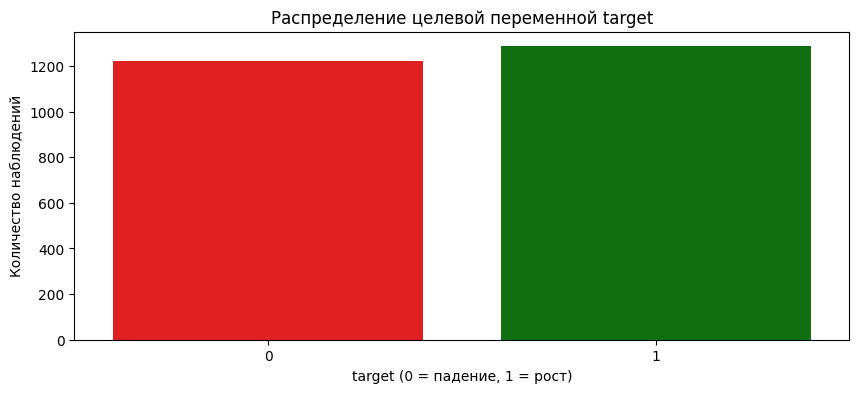

Абсолютные значения по целевой переменной target:
target
1    1286
0    1221
Name: count, dtype: int64

Доли по целевой переменной target:
target
1    0.513
0    0.487
Name: proportion, dtype: float64


In [34]:
# --- 3.1.1. Распределение целевой переменной target ---

plt.figure(figsize=(10, 4))
sns.countplot(data=df_fe, x="target", palette=["red", "green"])
plt.title("Распределение целевой переменной target")
plt.xlabel("target (0 = падение, 1 = рост)")
plt.ylabel("Количество наблюдений")
plt.show()

# Абсолютные значения
target_counts = df_fe["target"].value_counts()
print("Абсолютные значения по целевой переменной target:")
print(target_counts)

# Доли (нормализованные значения)
target_rate = df_fe["target"].value_counts(normalize=True).round(4)
print("\nДоли по целевой переменной target:")
print(target_rate)

📌 Что показал график и статистика:
- target=1 (рост) — 1286 наблюдений (51.3%)
- target=0 (падение) — 1221 наблюдений (48.7%)
- Столбчатая диаграмма показывает почти равную высоту столбцов для обоих классов. Зеленый столбец (рост) незначительно выше красного (падение).

📌 Интерпретация:
- Классы почти сбалансированы — разница всего ~2.6%
- Это важно: модели не будут страдать от дисбаланса.
- Лёгкий перевес в сторону роста — типично для фондовых индексов и акций (рынки растут чаще, чем падают).

__Вывод:__
- Классовый баланс хороший, можно использовать любые классификаторы без специальных техник балансировки.

__Распределения цен и объёма__

In [35]:
def plot_feature_distribution(df, feature, target="target", bins=40, title=None):
    """
    Простая и информативная функция для анализа распределения признака:
    - общая статистика
    - статистика по target
    - boxplot общий
    - гистограмма общая
    - boxplot по target
    - гистограмма по target
    """

    # Удаляем пропуски
    data = df[[feature, target]].dropna()

    # Общая статистика
    print(f"\n📊 Общая статистика по '{feature}':")
    print(data[feature].describe())

    # Статистика по группам target
    for val in sorted(data[target].unique()):
        print(f"\n{target} = {val}:")
        print(data.loc[data[target] == val, feature].describe())

    # Заголовок
    if title is None:
        title = f'Распределение "{feature}" (общие и по target)'

    # 4 графика
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(title, fontsize=18, fontweight='bold')

    # --- 1. Boxplot общий ---
    sns.boxplot(y=data[feature], ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title('Boxplot (общий)', fontsize=14)

    # --- 2. Гистограмма общая ---
    sns.histplot(
        data[feature], bins=bins, stat='count',
        color='steelblue', ax=axes[0, 1],
        alpha=0.6, edgecolor='gray'
    )
    axes[0, 1].set_title('Гистограмма (общая)', fontsize=14)

    # --- 3. Boxplot по target ---
    sns.boxplot(
        data=data, x=target, y=feature, hue=target,
        ax=axes[1, 0], palette='Set2', legend=False
    )
    axes[1, 0].set_title('Boxplot по target', fontsize=14)

    # --- 4. Гистограмма по target ---
    sns.histplot(
        data=data, x=feature, hue=target,
        bins=bins, stat="density", common_norm=False,
        palette='muted', ax=axes[1, 1]
    )
    axes[1, 1].set_title('Гистограмма по target', fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


Создана универсальная функция plot_feature_distribution(), которая для каждого признака выводит:
- Общую описательную статистику
- Статистику отдельно для классов target=0 и target=1
- Boxplot (общий и по классам)
- Гистограмму (общую и по классам)


📊 Общая статистика по 'open':
count    2507.000000
mean     4460.243638
std      1601.778261
min      1916.000000
25%      2939.050000
50%      4452.000000
75%      5621.500000
max      8152.500000
Name: open, dtype: float64

target = 0:
count    1221.000000
mean     4509.883948
std      1606.728877
min      1921.000000
25%      3000.500000
50%      4490.000000
75%      5690.000000
max      8098.500000
Name: open, dtype: float64

target = 1:
count    1286.000000
mean     4413.112364
std      1596.259728
min      1916.000000
25%      2890.000000
50%      4400.500000
75%      5583.250000
max      8152.500000
Name: open, dtype: float64


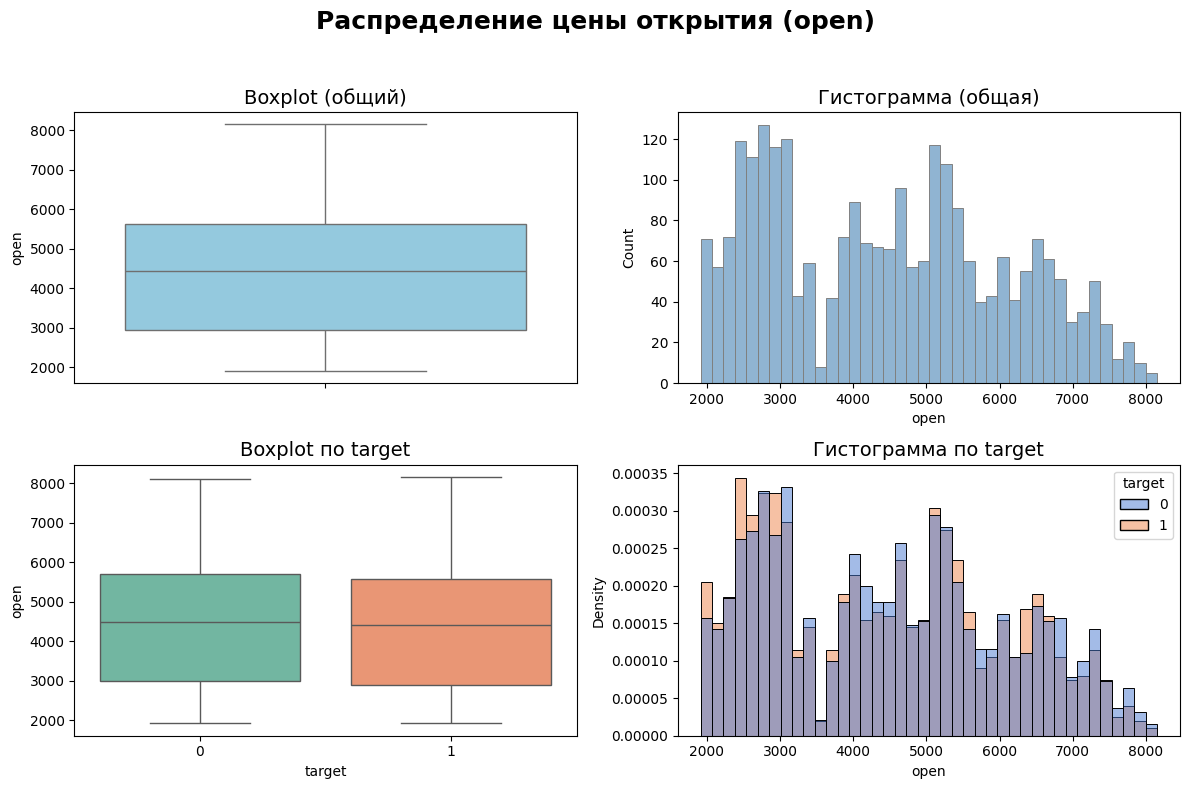

In [36]:
plot_feature_distribution(df_fe, feature="open", title="Распределение цены открытия (open)")


📊 Общая статистика по 'high':
count    2507.000000
mean     4511.057519
std      1614.741585
min      1949.000000
25%      2964.750000
50%      4512.500000
75%      5692.500000
max      8175.000000
Name: high, dtype: float64

target = 0:
count    1221.000000
mean     4560.976495
std      1620.676339
min      1949.000000
25%      3026.000000
50%      4563.500000
75%      5787.000000
max      8161.500000
Name: high, dtype: float64

target = 1:
count    1286.000000
mean     4463.661664
std      1608.282762
min      1957.500000
25%      2915.500000
50%      4462.750000
75%      5636.250000
max      8175.000000
Name: high, dtype: float64


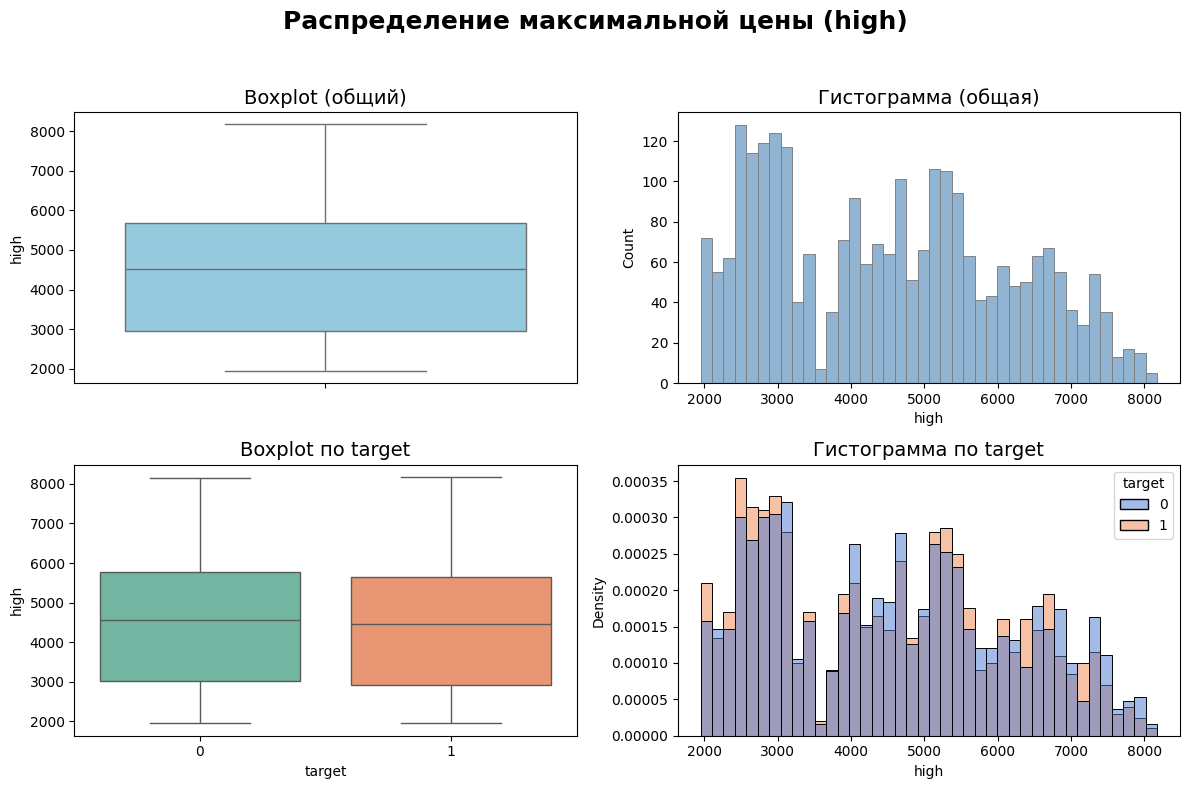

In [37]:
plot_feature_distribution(df_fe, feature="high", title="Распределение максимальной цены (high)")


📊 Общая статистика по 'low':
count    2507.000000
mean     4405.094655
std      1585.718511
min      1911.500000
25%      2901.750000
50%      4381.500000
75%      5566.500000
max      8080.000000
Name: low, dtype: float64

target = 0:
count    1221.000000
mean     4455.121622
std      1592.907789
min      1911.500000
25%      2964.000000
50%      4410.500000
75%      5607.000000
max      8037.000000
Name: low, dtype: float64

target = 1:
count    1286.000000
mean     4357.596267
std      1578.013948
min      1913.000000
25%      2860.000000
50%      4354.500000
75%      5523.750000
max      8080.000000
Name: low, dtype: float64


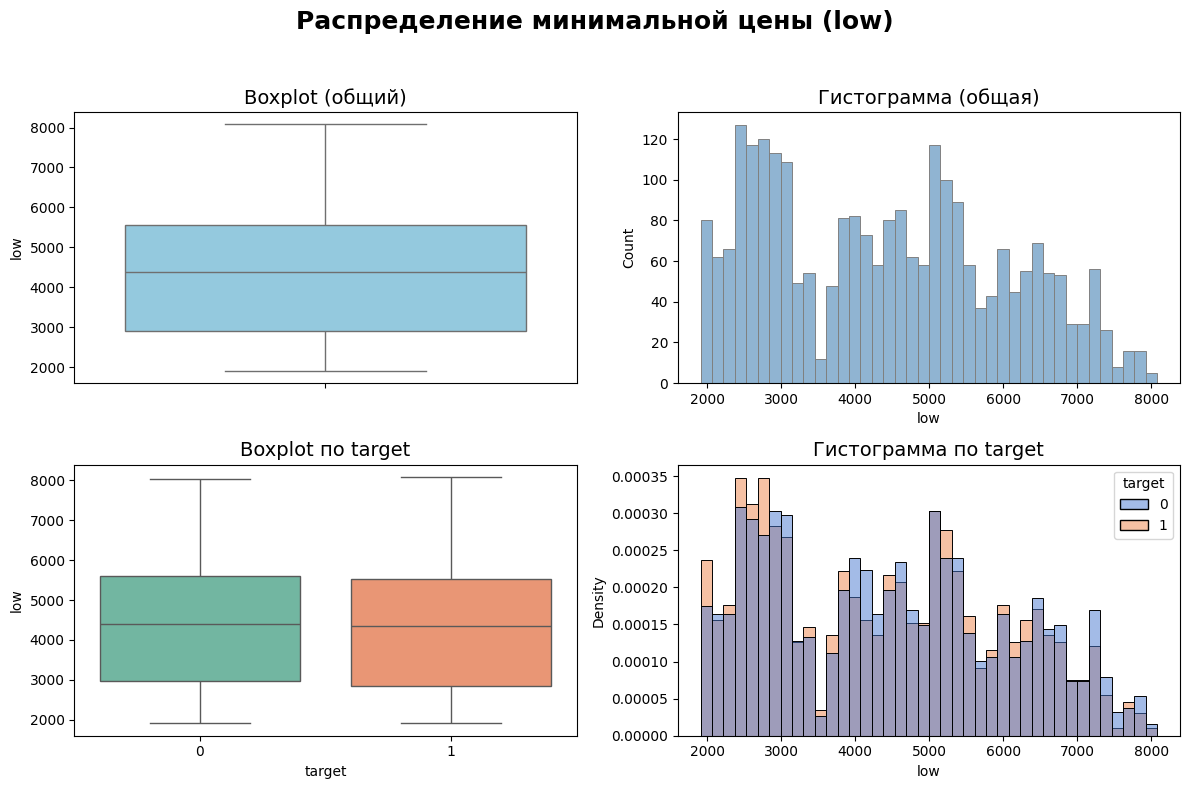

In [38]:
plot_feature_distribution(df_fe, feature="low", title="Распределение минимальной цены (low)")


📊 Общая статистика по 'close':
count    2507.000000
mean     4461.615836
std      1601.606745
min      1925.100000
25%      2936.500000
50%      4456.000000
75%      5618.750000
max      8152.000000
Name: close, dtype: float64

target = 0:
count    1221.000000
mean     4511.194758
std      1609.986510
min      1928.300000
25%      2991.500000
50%      4499.500000
75%      5695.000000
max      8152.000000
Name: close, dtype: float64

target = 1:
count    1286.000000
mean     4414.542846
std      1592.807610
min      1925.100000
25%      2893.625000
50%      4412.750000
75%      5582.000000
max      8085.500000
Name: close, dtype: float64


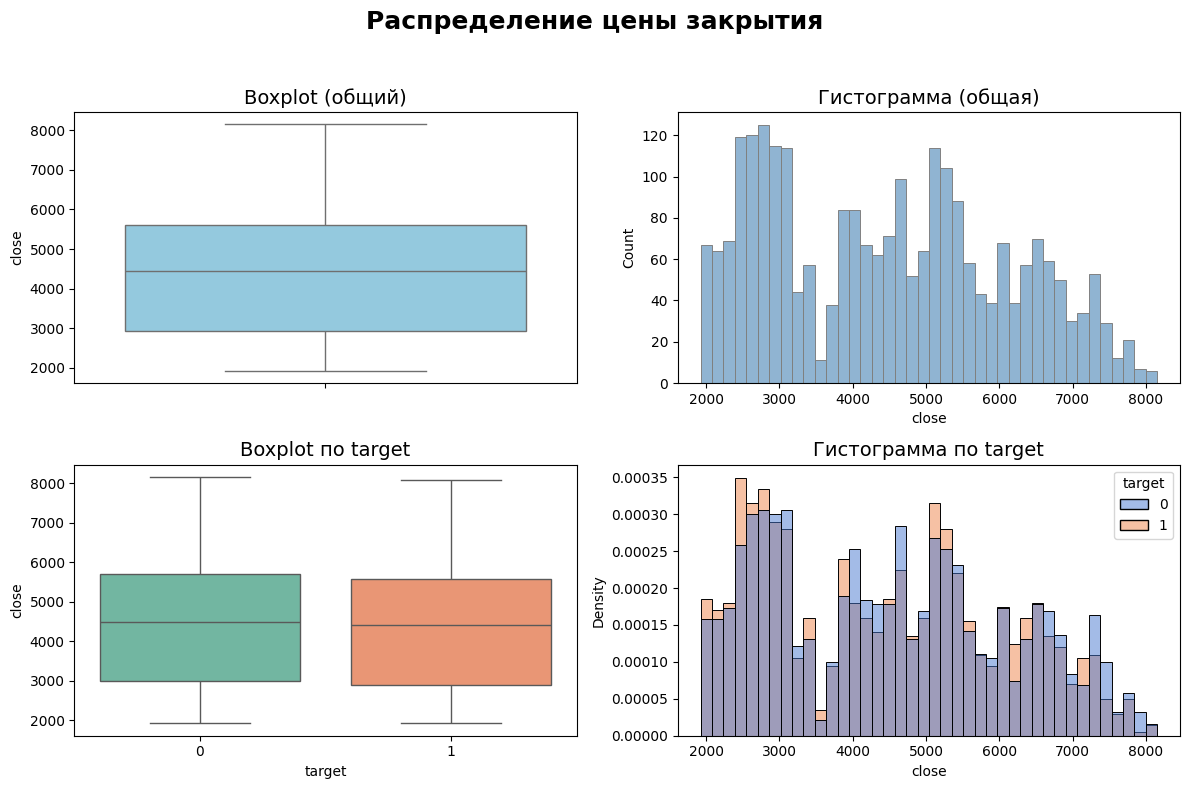

In [39]:
plot_feature_distribution(df_fe, feature="close", title="Распределение цены закрытия")

__Анализ графиков:__
- Боксплоты (общие):
  - Все ценовые признаки имеют широкий размах (от ~1900 до ~8200)
  - Медиана находится примерно посередине распределения, что говорит о симметричности
- Боксплоты по классам:
  - Для target=0 (падение) медианы всех ценовых признаков выше, чем для target=1
  - Разброс значений примерно одинаков для обоих классов
- Гистограммы по классам:
  - Форма распределений практически идентична

__Выводы:__
- Все ценовые признаки имеют почти идентичные распределения, что логично — они движутся вместе
- Распределения широкие, с длинными хвостами — отражают тренд роста рынка за 10 лет
- Цены имеют логичную корреляцию с target:
  - После дней падения (target=0) цены в среднем выше
  - После дней роста (target=1) цены в среднем ниже
- Это подтверждает гипотезу, что рост чаще происходит на отскоках от низких уровней
- Все ценовые признаки движутся синхронно — мультиколлинеарность неизбежна


📊 Общая статистика по 'vol':
count    2.507000e+03
mean     9.725856e+05
std      6.599666e+05
min      5.404300e+04
25%      5.602675e+05
50%      8.043300e+05
75%      1.197488e+06
max      7.526760e+06
Name: vol, dtype: float64

target = 0:
count    1.221000e+03
mean     9.477425e+05
std      6.401145e+05
min      5.404300e+04
25%      5.559380e+05
50%      7.948540e+05
75%      1.140105e+06
max      5.901625e+06
Name: vol, dtype: float64

target = 1:
count    1.286000e+03
mean     9.961729e+05
std      6.776839e+05
min      5.727900e+04
25%      5.619492e+05
50%      8.177990e+05
75%      1.237974e+06
max      7.526760e+06
Name: vol, dtype: float64


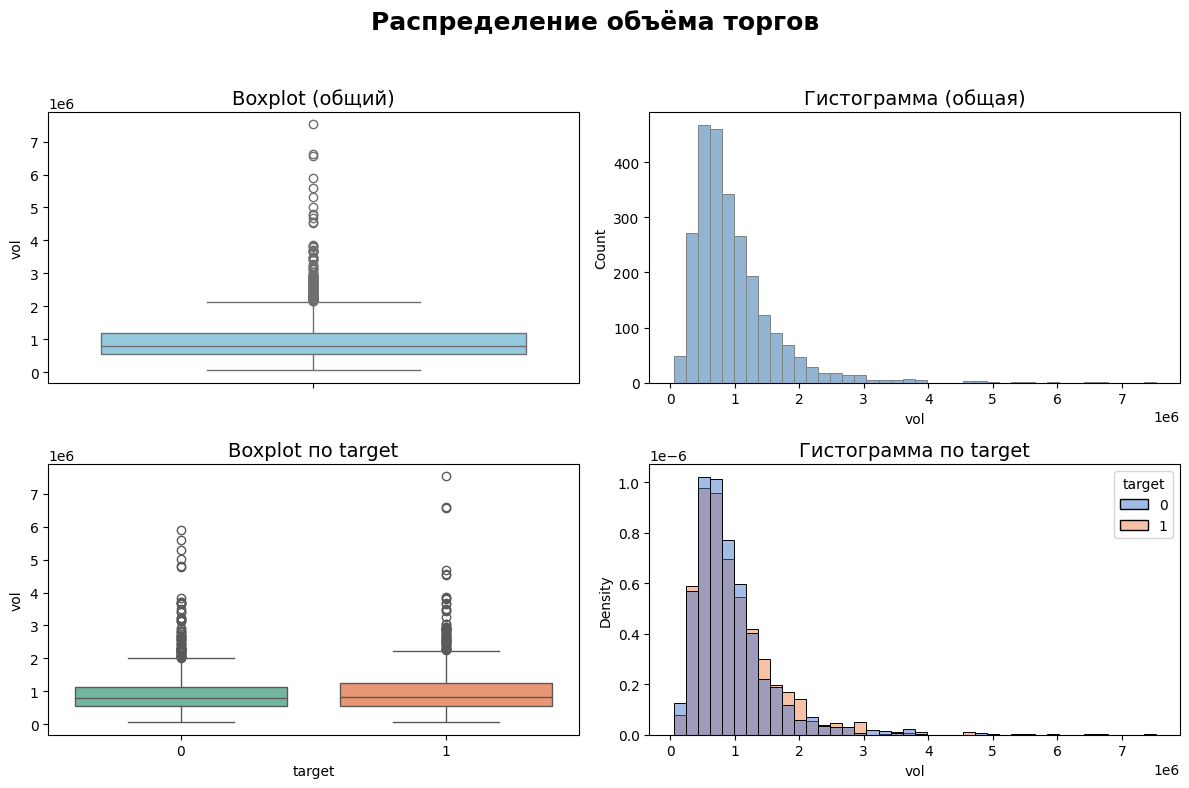

In [40]:
plot_feature_distribution(df_fe, feature="vol", title="Распределение объёма торгов")

Результаты:
- Средний объём: 972,585
- Медианный объём: 804,330
- Максимальный объём: 7,526,760 (в 9 раз выше медианы)

Статистика по классам:
- target=0: средний объём 947,742
- target=1: средний объём 996,173

__Анализ графиков:__
- Гистограмма (общая):
  - Сильно скошена вправо (правосторонняя асимметрия)
  - Большинство наблюдений сконцентрировано в диапазоне 500k–1.5M
  - Длинный "хвост" экстремально высоких значений
  - Есть экстремальные пики — дни высокой активности.
  - Для target=1 объём чуть выше, чем для target=0
- Боксплоты по классам:
  - Медиана объёма при target=1 немного выше
  - Размах и выбросы сопоставимы для обоих классов

__Выводы:__
- Объём имеет логиормальное распределение — типично для финансовых данных
- Дни роста сопровождаются чуть более высокими объёмами, чем дни падения
- Экстремальные пики объёма соответствуют важным рыночным событиям

__Объём — перспективный признак для модели, так как его распределение различается между классами__


📊 Общая статистика по 'return_1d':
count    2506.000000
mean        0.000492
std         0.019496
min        -0.258220
25%        -0.008410
50%         0.000570
75%         0.009696
max         0.143438
Name: return_1d, dtype: float64

target = 0:
count    1220.000000
mean        0.000193
std         0.018723
min        -0.126360
25%        -0.008586
50%        -0.000264
75%         0.008877
max         0.143438
Name: return_1d, dtype: float64

target = 1:
count    1286.000000
mean        0.000775
std         0.020205
min        -0.258220
25%        -0.008200
50%         0.001494
75%         0.010644
max         0.087859
Name: return_1d, dtype: float64


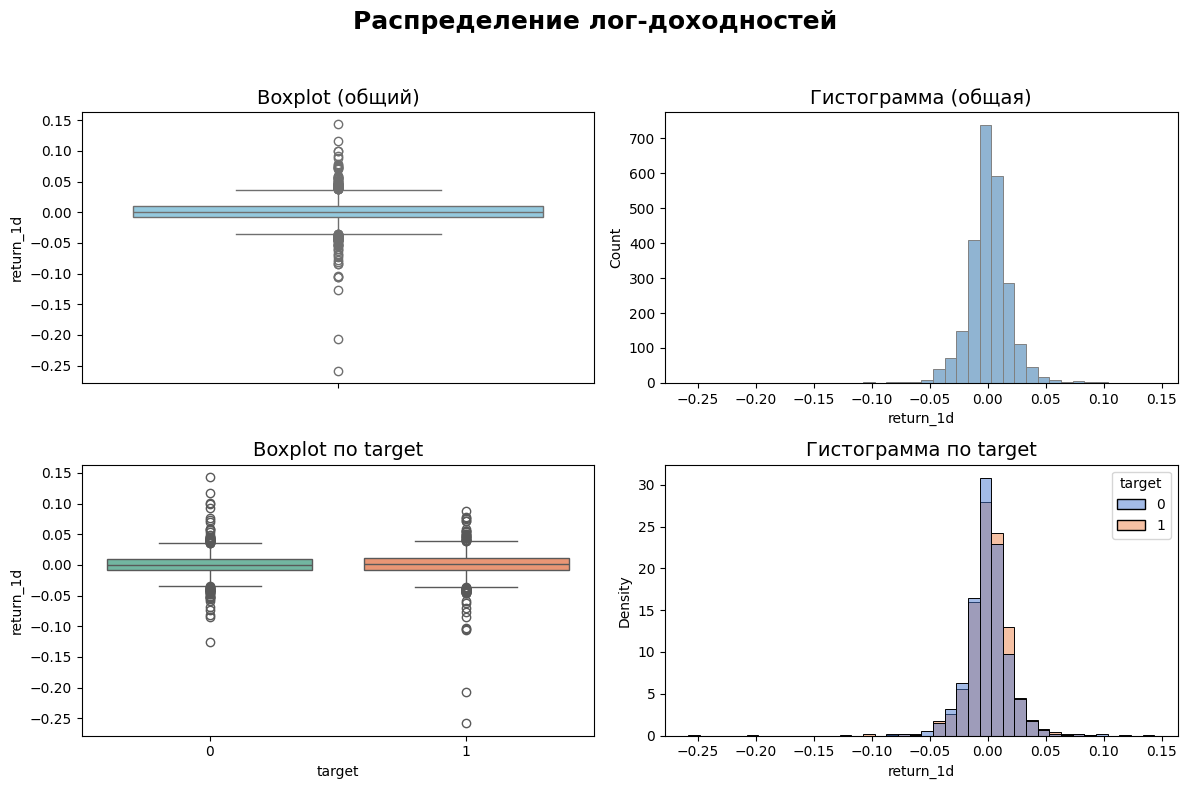

In [41]:
plot_feature_distribution(df_fe, feature="return_1d", title="Распределение лог-доходностей")

Результаты:
- Среднее: 0.000492 (близко к нулю)
- Стандартное отклонение: 0.0195 (~2% дневной волатильности)
- Минимум: -0.258 (-25.8%)
- Максимум: 0.143 (14.3%)

Статистика по классам:
- target=0: медиана -0.000264 (отрицательное)
- target=1: медиана 0.001494 (положительное)

__Анализ графиков:__
- Гистограмма (общая):
  - Симметричная форма, напоминающая нормальное распределение в диапазоне (-0.05, 0.05)
  - Но визуально заметны более толстые хвосты, чем у нормального распределения
  - Есть редкие экстремальные значения (до −25% и +14%).
- Гистограмма по классам:
  - Для target=1 распределение немного смещено вправо (положительные доходности)
  - Для target=0 распределение немного смещено влево (отрицательные доходности)
- Степень перекрытия значительная, что ожидаемо — предсказывать направление сложно

__Выводы: лог-доходности ведут себя как классический финансовый ряд__
  - Высокая волатильность
  - Среднее близко к нулю
  - Наличие экстремальных значений ("толстые хвосты")
  - Отсутствие нормальности (подтверждено далее тестами)
  - Разделение медиан по классам подтверждает качество целевой переменной

__Проверка нормальности доходностей__
  - Q-Q plot
  - Тест Шапиро–Уилка

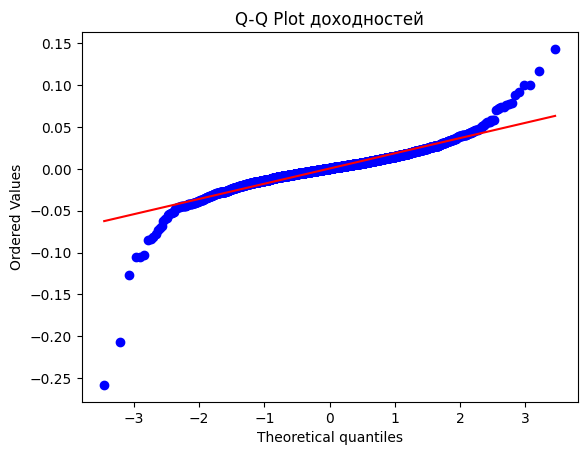

In [42]:
probplot(df_fe["return_1d"].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot доходностей")
plt.show()

- Точки сильно отклоняются от диагонали.
- На концах графика отклонения максимальны
- Хвосты распределения значительно тяжелее нормальных.

Интерпретация: распределение имеет "тяжёлые хвосты" — экстремальных значений больше, чем должно быть при нормальном распределении

In [43]:
stat, p = shapiro(df_fe["return_1d"].dropna())

print(f"Shapiro-Wilk test:")
print(f"  Statistic = {stat:.4f}")
print(f"  p-value   = {p:.4f}")

# Интерпретация
alpha = 0.05

print("\nИнтерпретация:")

if p > alpha:
    print("✔ Распределение НЕ отличается от нормального (не удалось отвергнуть H0).")
else:
    print("✘ Распределение СУЩЕСТВЕННО отличается от нормального (H0 отвергнута).")

# Степень отклонения
if stat > 0.95:
    print("➡ Отклонение от нормальности слабое.")
elif stat > 0.90:
    print("➡ Отклонение от нормальности умеренное.")
else:
    print("➡ Отклонение от нормальности сильное.")

# Рекомендации
print("\nРекомендации:")

if p < alpha:
    print("- Использовать непараметрические методы или логарифмические преобразования.")
    print("- Проверить распределение через QQ‑plot.")
    print("- Рассмотреть Box‑Cox или Yeo‑Johnson трансформации.")
else:
    print("- Можно использовать методы, предполагающие нормальность.")

Shapiro-Wilk test:
  Statistic = 0.8735
  p-value   = 0.0000

Интерпретация:
✘ Распределение СУЩЕСТВЕННО отличается от нормального (H0 отвергнута).
➡ Отклонение от нормальности сильное.

Рекомендации:
- Использовать непараметрические методы или логарифмические преобразования.
- Проверить распределение через QQ‑plot.
- Рассмотреть Box‑Cox или Yeo‑Johnson трансформации.


📌 Интерпретация:
- Доходности НЕ нормальны.  
- Это абсолютно нормально для финансовых данных.

__Вывод:__
- Доходности НЕ являются нормально распределёнными
  - типично для финансовых данных
- Модели, предполагающие нормальность (например, линейная регрессия), будут работать хуже.
- Лучше использовать деревья, бустинг, логистическую регрессию

### 3.2. Временные графики <a class="anchor" id="ch4_3_2"></a>

__Цена закрытия + аннотация target__

Что было сделано:
- Построен линейный график цены закрытия за весь период (2014–2024)
- Точки target=1 отмечены зелёным, target=0 — красным
- Отдельно построен график за 2014 год для детализации

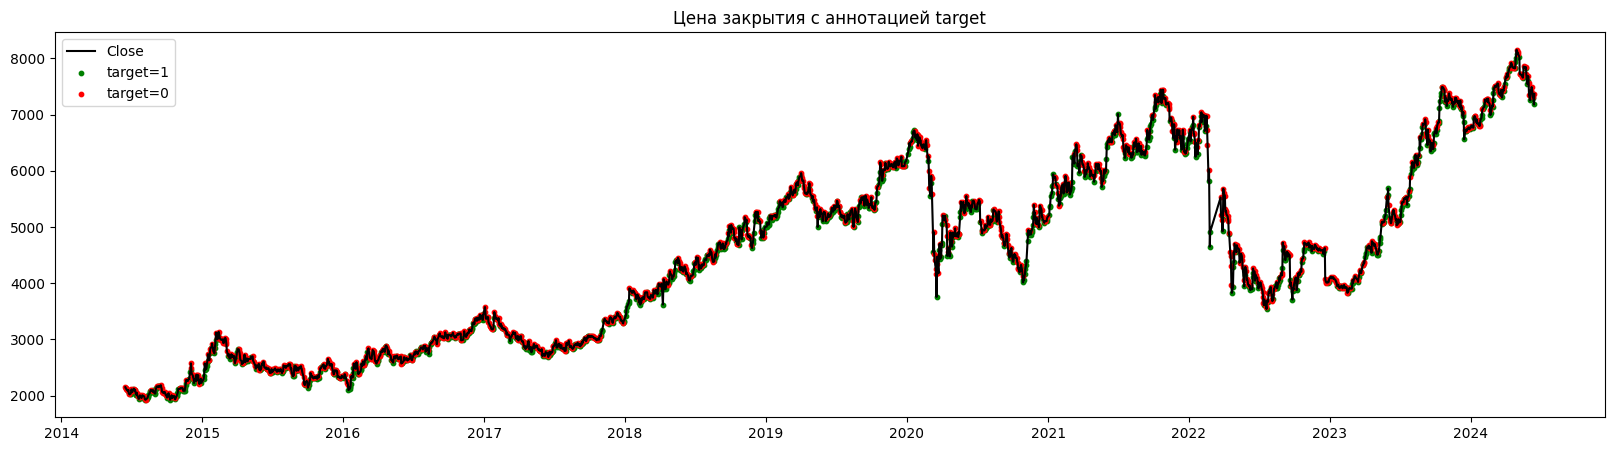

In [44]:
plt.figure(figsize=(20,5))
plt.plot(df_fe.index, df_fe["close"], label="Close", color="black")

# точки target
plt.scatter(df_fe.index[df_fe["target"]==1], df_fe["close"][df_fe["target"]==1],
            color="green", s=10, label="target=1")
plt.scatter(df_fe.index[df_fe["target"]==0], df_fe["close"][df_fe["target"]==0],
            color="red", s=10, label="target=0")

plt.title("Цена закрытия с аннотацией target")
plt.legend()
plt.show()

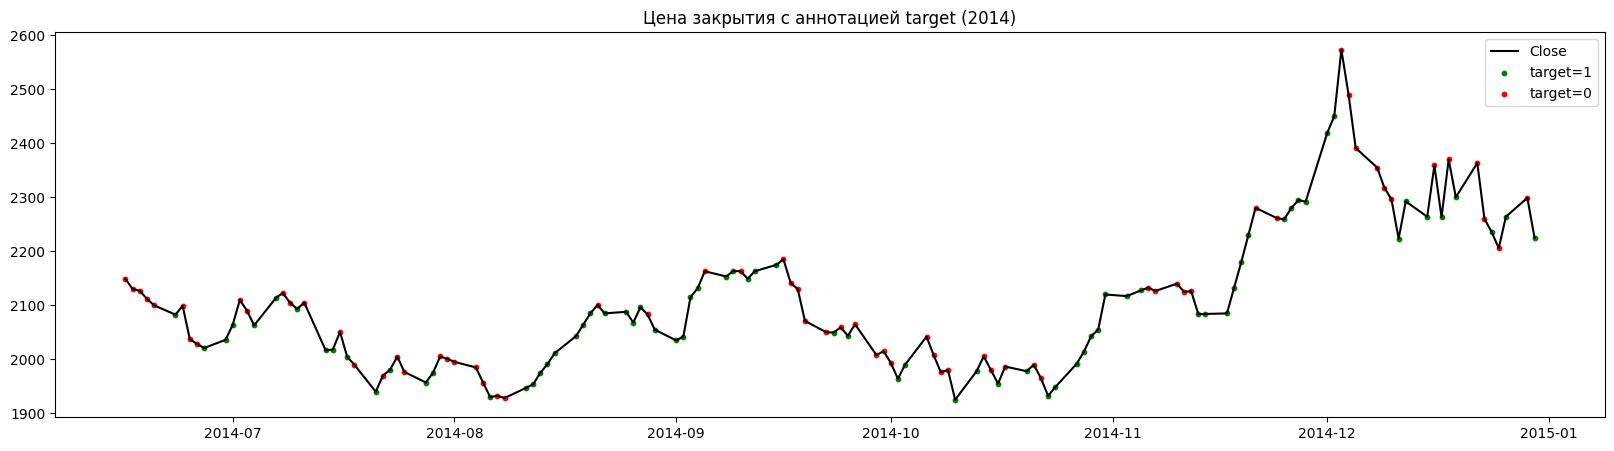

In [45]:
df_2014 = df_fe[df_fe.index.year == 2014]

plt.figure(figsize=(20,5))
plt.plot(df_2014.index, df_2014["close"], label="Close", color="black")

# точки target
plt.scatter(df_2014.index[df_2014["target"]==1], df_2014["close"][df_2014["target"]==1],
            color="green", s=10, label="target=1")

plt.scatter(df_2014.index[df_2014["target"]==0], df_2014["close"][df_2014["target"]==0],
            color="red", s=10, label="target=0")

plt.title("Цена закрытия с аннотацией target (2014)")
plt.legend()
plt.show()

__Анализ графика за весь период:__
- Общий тренд:
  - Чёткий восходящий тренд с 2014 по 2022 год
  - Цена выросла с ~2000 до ~8000 (+300%)
  - После 2022 года — коррекция и консолидация
- Ключевые события:
  - 2020 год: резкое падение (ковидный кризис) и быстрое восстановление
  - 2022 год: нисходящая фаза (возможно, связана с изменением монетарной политики)
  - 2023–2024: восстановление и выход на новые уровни
- Аннотация target:
  - Зелёные и красные точки распределены равномерно по всему графику
  - Нет периодов, где доминирует только один цвет
  - Цвета точек чередуются, формируя "полосатый" паттерн

__Анализ графика за 2014 год (детализация):__
- Видна микроструктура: дни роста и падения чередуются
- Цена движется вверх серией импульсов и коррекций
- Target=1 чаще встречается после локальных минимумов

__Выводы:__
- Target не зависит от абсолютного уровня цены — модель не сможет просто "выучить", что высокие цены ведут к падению
- Target зависит от локальных паттернов:
  - Волатильность
  - Свечные формации
  - Относительное положение цены
  - Это подтверждает важность созданных на Шаге 2 признаков

__Объём торгов__

Что было сделано:
- Построен линейный график объёма за весь период
- Точки target отмечены цветом

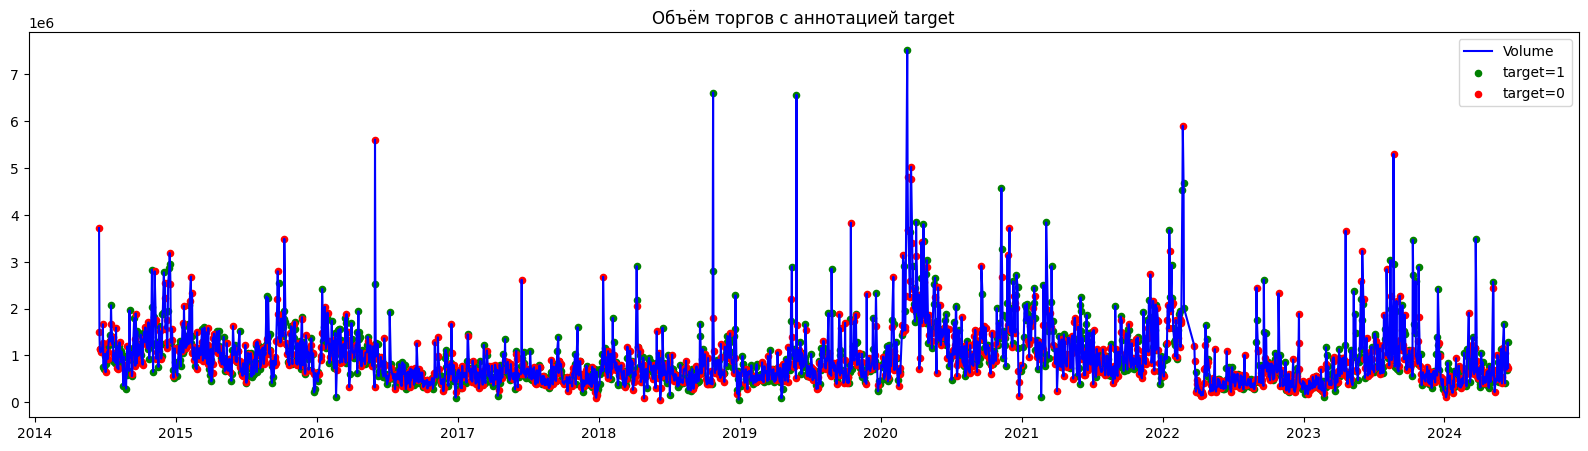

In [46]:
plt.figure(figsize=(20,5))

# Линия объёма
plt.plot(df_fe.index, df_fe["vol"], color="blue", label="Volume")

# Точки target=1 (например, зелёные)
plt.scatter(
    df_fe.index[df_fe["target"] == 1],
    df_fe["vol"][df_fe["target"] == 1],
    color="green", s=20, label="target=1"
)

# Точки target=0 (например, красные)
plt.scatter(
    df_fe.index[df_fe["target"] == 0],
    df_fe["vol"][df_fe["target"] == 0],
    color="red", s=20, label="target=0"
)

plt.title("Объём торгов с аннотацией target")
plt.legend()
plt.show()

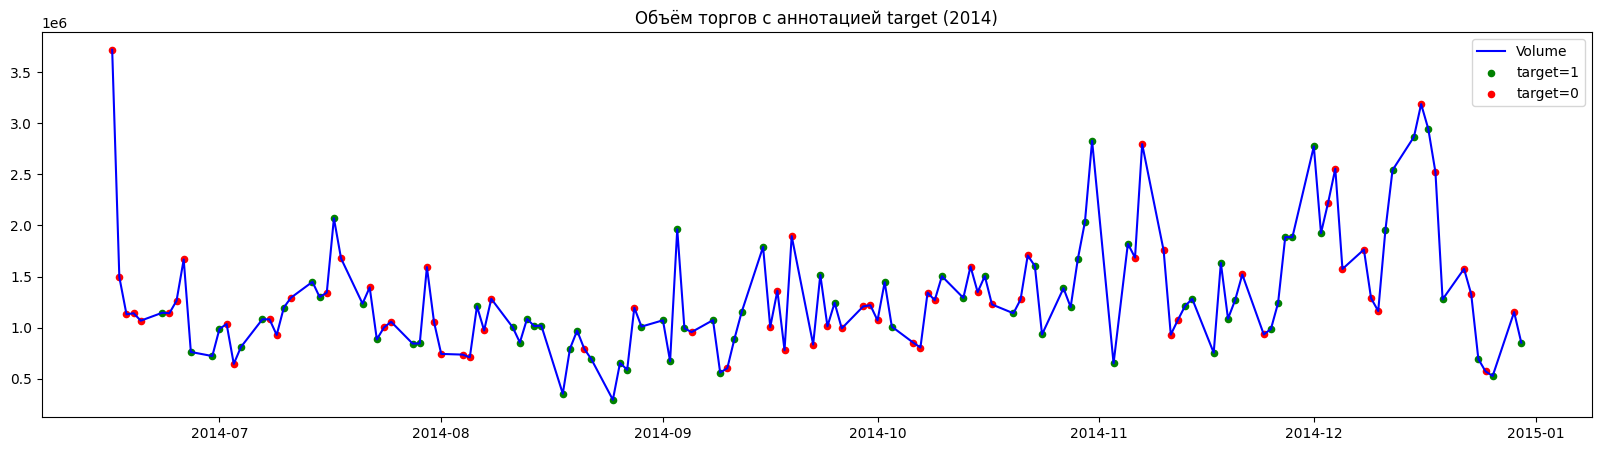

In [47]:
# Фильтрация по году
df_2014 = df_fe[df_fe.index.year == 2014]

plt.figure(figsize=(20,5))

# Линия объёма
plt.plot(df_2014.index, df_2014["vol"], color="blue", label="Volume")

# Точки target=1 (зелёные)
plt.scatter(
    df_2014.index[df_2014["target"] == 1],
    df_2014["vol"][df_2014["target"] == 1],
    color="green", s=20, label="target=1"
)

# Точки target=0 (красные)
plt.scatter(
    df_2014.index[df_2014["target"] == 0],
    df_2014["vol"][df_2014["target"] == 0],
    color="red", s=20, label="target=0"
)

plt.title("Объём торгов с аннотацией target (2014)")
plt.legend()
plt.show()

__Анализ графика:__
- Динамика объёма:
  - Объём сильно варьируется во времени
  - Периоды повышенной активности (пики) чередуются с периодами затишья
  - 2020–2021 годы: заметно более высокие объёмы (ковидная волатильность)
- Связь с target:
  - Зелёные и красные точки присутствуют как на пиках, так и на спадах объёма
  - Визуально сложно выделить однозначную зависимость

__Анализ графика за 2014 год:__
- Видно, что резкие всплески объёма часто предшествуют движениям
- Дни с экстремальным объёмом могут быть как ростом, так и падением

__Выводы:__
- Объём — важный индикатор "рыночного стресса"
- Модель должна учитывать не абсолютный объём, а его относительные изменения
- Созданные признаки vol_ratio_5, vol_relative, volatility_volume как раз решают эту задачу

### 3.3. Декомпозиция и сезонность <a class="anchor" id="ch4_3_3"></a>

Что было сделано:
- Применена классическая декомпозиция временного ряда на три компоненты:
  - Тренд (Trend)
  - Сезонность (Seasonality)
  - Остатки (Residuals)

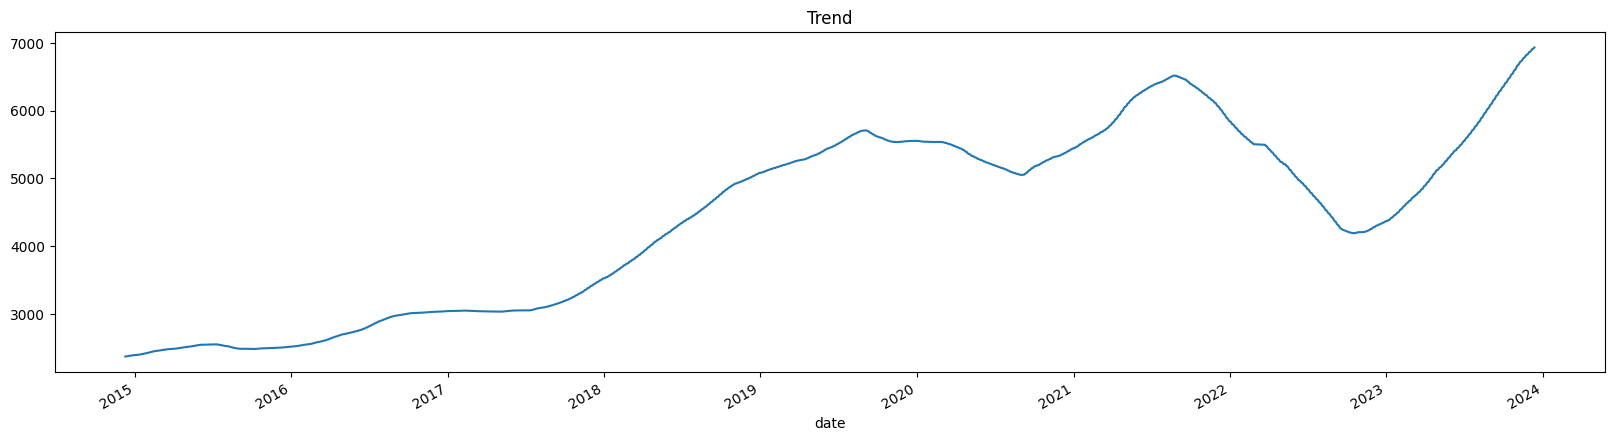

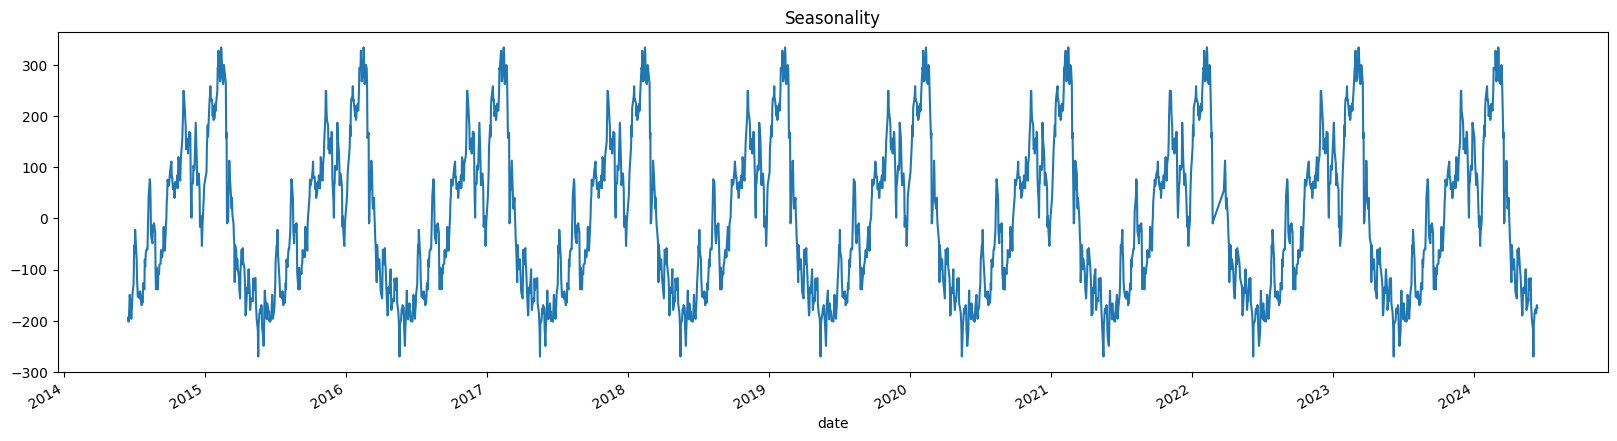

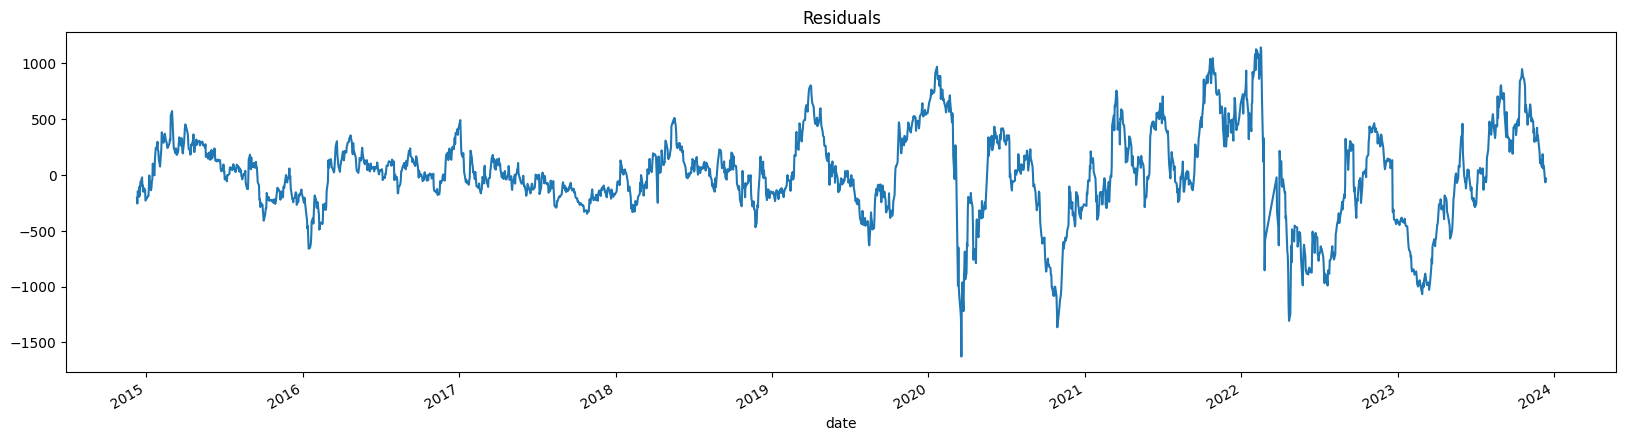

In [48]:
figsize = (20, 5)   # общий размер для всех графиков
decomp = seasonal_decompose(df_fe["close"], model="additive", period=252)

plt.figure(figsize=figsize)
decomp.trend.plot(title="Trend")
plt.show()

plt.figure(figsize=figsize)
decomp.seasonal.plot(title="Seasonality")
plt.show()

plt.figure(figsize=figsize)
decomp.resid.plot(title="Residuals")
plt.show()

📌 __Trend:__
- Долгосрочный восходящий тренд
  - График уверенно растёт с 2015 по примерно 2022 год.
  - Это говорит о том, что базовая динамика инструмента была положительной — цена постепенно повышалась, несмотря на локальные колебания.

- Коррекция / спад после пика
  - После максимума примерно в 2022 году тренд начинает снижаться.
  - Это может отражать:
    - перегрев рынка и последующую коррекцию,
    - смену рыночного цикла,
    - внешние шоки (экономические, политические, отраслевые).
- Волнообразная структура
  - Тренд не идеально гладкий — он имеет несколько фаз:
    - рост → замедление → рост → спад → восстановление
    - это типично для финансовых временных рядов, где тренд отражает чередование бычьих и медвежьих фаз.
- Локальные провалы (например, около 2020)
  - На графике видно заметное падение в районе 2020 года.
  - Это может быть связано с:
    - глобальными событиями (например, пандемия),
    - рыночной паникой,
    - снижением ликвидности.
- Восстановление после спада
  - После коррекции тренд снова начинает расти ближе к 2023–2024 годам.
  - Это говорит о том, что инструмент возвращается в фазу восстановления.
- Выводы:
  - Долгосрочный восходящий тренд — фундаментальная характеристика инструмента
  - Коррекция после 2022 года может означать смену рыночного режима
  - Для прогнозирования направления на 1 день тренд менее важен, чем локальные колебания

📌 __Seasonality:__
- Сезонность ярко выражена и стабильна
  - На графике видно, что колебания повторяются с примерно одинаковой амплитудой и формой каждый год.
  - Это говорит о том, что:
    -  в данных присутствует устойчивая годовая цикличность,
    - сезонный паттерн не исчезает и не меняет форму со временем
- Амплитуда сезонных колебаний примерно постоянна
  - Диапазон колебаний находится примерно между −300 и +300.
  - Это характерно для аддитивной сезонности, что подтверждает правильность выбора model="additive".
  - Если бы амплитуда росла вместе с уровнем ряда, пришлось бы использовать multiplicative.
-  Сезонный цикл повторяется ежегодно
   - Пики и впадины происходят примерно в одни и те же месяцы.
   - Это означает:
     - есть «сильные» и «слабые» периоды года,
     - поведение инструмента зависит от календарного времени,
     -  можно строить стратегии, учитывающие сезонные фазы.
- Сезонность не зависит от тренда
  - Даже когда тренд растёт или падает, сезонная компонента остаётся практически неизменной.
  - Это говорит о том, что:
    - сезонность — автономный фактор,
    - она не усиливается и не ослабевает со временем,
    - её можно использовать как отдельную фичу в моделях.

- Что это даёт для анализа и моделей
  - С такой сезонностью можно:
    - улучшить прогнозы, добавив сезонные лаги (например, lag_252),
    - использовать сезонные индикаторы (месяц, квартал),
    - применять модели с сезонной структурой,
    - корректировать данные на сезонность для анализа тренда.
- Выводы:
  - В данных присутствует устойчивая годовая сезонность
  - Это объясняет важность календарных признаков (month)
  - Сезонность можно использовать:
    - Для создания сезонных лагов (lag_252)
    - Для коррекции данных при анализе тренда
    - Как отдельный предиктор в модели

__📌 Residuals:__
- Остатки не выглядят как чистый белый шум:
  - имеют периоды расширения и сжатия,
  - иногда формируют кластеры повышенной волатильности,
- Есть всплески волатильности (кризисы).
  - Это типично для финансовых рядов: волатильность сама по себе циклична.
- В остатках видны структурные изменения
  - На графике есть моменты, где поведение остатков резко меняется:
    - скачки,
    - смена диапазона,
    - изменение характера колебаний
- Выводы:
  - Остатки содержат информацию, не объяснённую трендом и сезонностью
  - Это подтверждает необходимость использования признаков волатильности

### 3.4. Автокорреляция и лаги <a class="anchor" id="ch4_3_4"></a>

__Проверка стационарности__

In [49]:
# --- 3.4.1. Проверка стационарности лог-доходностей ---
returns = df_fe["return_1d"].dropna()

adf_stat, p_value, used_lags, n_obs, crit_vals, icbest = adfuller(returns)

print("ADF-тест на стационарность лог-доходностей")
print(f"ADF statistic: {adf_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print("Критические значения:")
for key, value in crit_vals.items():
    print(f"   {key}: {value:.4f}")

if p_value < 0.05:
    print("\n✔ Ряд стационарен (отклоняем H0)")
else:
    print("\n✖ Ряд НЕ стационарен (не отклоняем H0)")

ADF-тест на стационарность лог-доходностей
ADF statistic: -50.3520
p-value: 0.0000
Критические значения:
   1%: -3.4330
   5%: -2.8627
   10%: -2.5674

✔ Ряд стационарен (отклоняем H0)


Интерпретация:
- Статистика значительно ниже всех критических значений
- p-value < 0.05 → отвергаем нулевую гипотезу о наличии единичного корня

Вывод:
- Лог-доходности — стационарный процесс
- Это важно для моделирования: можно использовать стандартные статистические методы
- Не требуется дифференцирование или другие преобразования для стационаризации

__ACF и PACF__

<Figure size 1200x400 with 0 Axes>

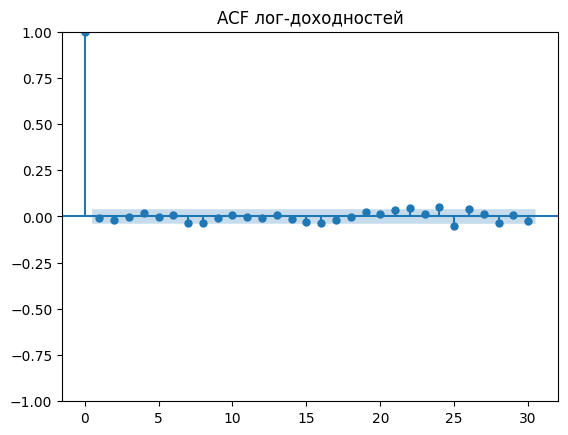

<Figure size 1200x400 with 0 Axes>

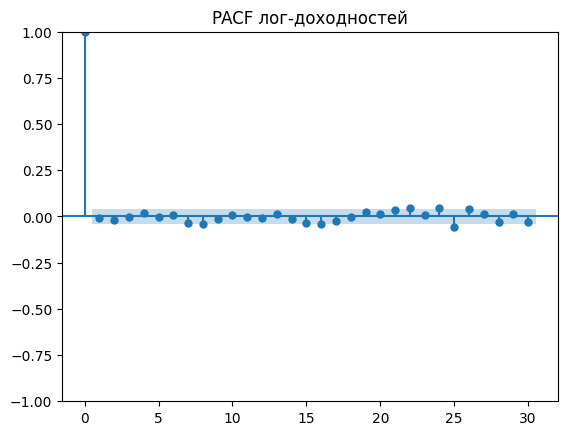

In [50]:
# --- 3.4.2. ACF и PACF ---

plt.figure(figsize=(12,4))
plot_acf(returns, lags=30)
plt.title("ACF лог-доходностей")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(returns, lags=30, method="ywm")
plt.title("PACF лог-доходностей")
plt.show()

📌 Что показывает ACF (автокорреляция)
- Почти все значения ACF близки к нулю. Это означает:
  - в лог‑доходностях нет линейной автокорреляции,
  - прошлые доходности почти не помогают предсказать будущие,
  - типично для финансовых рынков: доходности почти непредсказуемы.

- Нет значимых лагов (кроме лаг 0)
  - Ни один лаг не выходит за доверительные интервалы.

📌 Что показывает PACF (частичная автокорреляция)
- PACF тоже почти полностью в нуле. Это подтверждает:
  - отсутствие AR‑структуры,
  - отсутствие скрытых линейных зависимостей,
  - отсутствие долгих «хвостов» автокорреляции.
  
Выводы:
- В лог-доходностях нет линейной автокорреляции
- Прошлые доходности практически не помогают предсказать будущие
  - Это классическое свойство эффективного рынка (гипотеза слабой формы)
- Нелинейные зависимости (если они есть) должны быть извлечены через:
  - Признаки волатильности
  - Свечные паттерны
  - Комбинации признаков  

### 3.5. Корреляционный анализ <a class="anchor" id="ch4_3_5"></a>


Phik-корреляции признаков с target:
vol                  0.076530
vol_ratio_5          0.047616
roc_5                0.040553
rsi_14               0.028780
high_low_ratio       0.025337
open                 0.000000
high                 0.000000
low                  0.000000
close                0.000000
return_1d            0.000000
close_position       0.000000
volatility_volume    0.000000
Name: target, dtype: float64


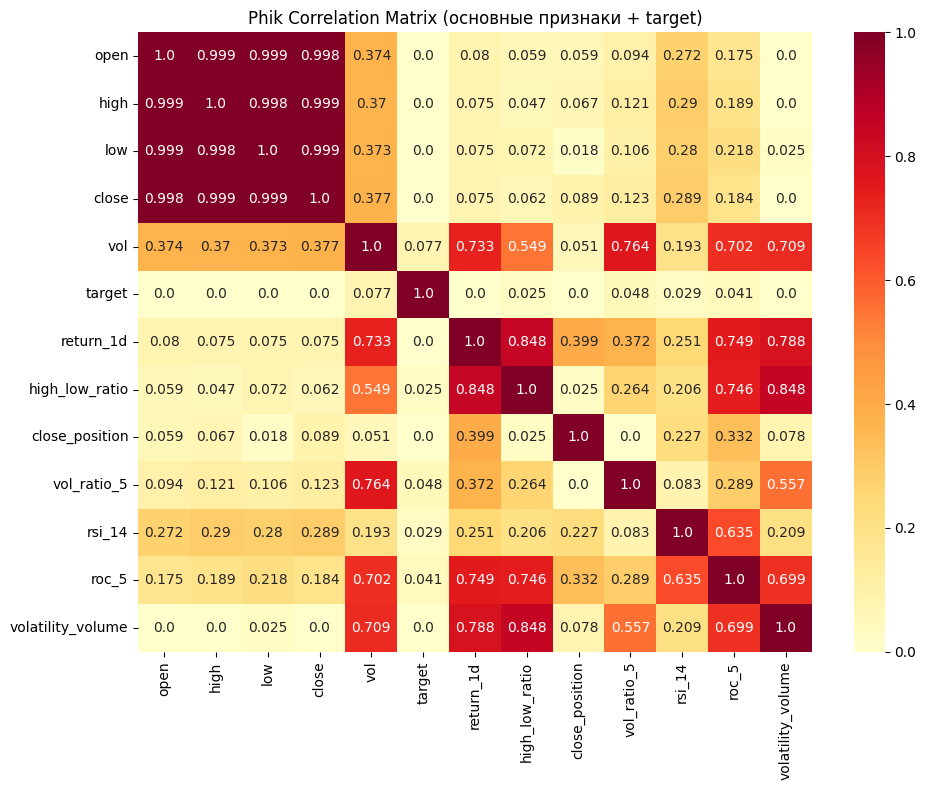


Пары числовых признаков с высокой корреляцией (|corr| > 0.5):
high            close                0.999335
open            high                 0.999308
low             close                0.999166
open            low                  0.998874
                close                0.998787
high            low                  0.998420
high_low_ratio  volatility_volume    0.881514
vol             volatility_volume    0.666576
vol_ratio_5     volatility_volume    0.617064
return_1d       close_position       0.606122
vol             high_low_ratio       0.569913
                vol_ratio_5          0.561265
rsi_14          roc_5                0.514483
dtype: float64

Количество пар с высокой корреляцией: 13


In [51]:
# --- 3.5.1. Phik-корреляции с target ---

phik_cols = [
    "open", "high", "low", "close", "vol", "target",
    "return_1d", "high_low_ratio", "close_position",
    "vol_ratio_5", "rsi_14", "roc_5", "volatility_volume"
]

df_phik = df_fe[phik_cols].dropna()

# Указываем, что ВСЕ столбцы — интервальные
interval_cols = phik_cols

# Phik-матрица без предупреждений
phik_corr = df_phik.phik_matrix(interval_cols=interval_cols)

# Корреляции признаков с target
print("\nPhik-корреляции признаков с target:")
print(phik_corr["target"].drop("target").sort_values(ascending=False))

# Округлённая матрица для подписей
phik_corr_rounded = phik_corr.round(3)

# Heatmap с подписями
plt.figure(figsize=(10, 8))
sns.heatmap(
    phik_corr,
    cmap="YlOrRd",
    annot=phik_corr_rounded,
    fmt="",
    vmin=0, vmax=1
)
plt.title("Phik Correlation Matrix (основные признаки + target)")
plt.tight_layout()
plt.show()


# --- Pearson-корреляции между числовыми признаками (ТОЛЬКО из phik_cols) ---

# Берём только числовые признаки из phik_cols
num_cols = df_fe[phik_cols].select_dtypes(include=["float64", "int64"]).columns.tolist()

# Убираем target
if "target" in num_cols:
    num_cols.remove("target")

# Pearson-корреляционная матрица
pearson_corr = df_fe[num_cols].corr()

# Маска: ищем пары с |corr| > 0.5 (верхний треугольник)
mask = np.triu(np.abs(pearson_corr) > 0.5, k=1)

# Пары с высокой корреляцией
pairs = pearson_corr.where(mask).stack().sort_values(ascending=False)

print("\nПары числовых признаков с высокой корреляцией (|corr| > 0.5):")
print(pairs if not pairs.empty else "Нет пар с высокой корреляцией.")

print(f"\nКоличество пар с высокой корреляцией: {len(pairs)}")

Анализ:
- Все корреляции невысокие (максимум 0.076)
- Это нормально для задачи прогнозирования направления цены
- Объём (vol) показывает самую сильную связь
- Ценовые признаки (open, high, low, close) имеют нулевую Phik-корреляцию — подтверждение, что target не зависит от абсолютного уровня цены

Выводы:
- Связи между признаками и target слабые, но существуют
- Это ожидаемо для финансовых рынков (предсказуемость низкая)
- Объём — самый информативный одиночный признак

In [52]:
df_clean = df_fe.dropna()

interval_cols = list(df_clean.columns)  # все столбцы считаем интервальными

target_corr = {}

for col in df_clean.columns:
    if col != "target":
        target_corr[col] = df_clean[[col, "target"]].phik_matrix(interval_cols=interval_cols).loc[col, "target"]

target_corr = pd.Series(target_corr).sort_values(ascending=False)

print("\nPhik-корреляции признаков с target:")
print(target_corr)


Phik-корреляции признаков с target:
target_check         0.948443
vol                  0.078469
dist_to_low_5        0.073846
rolling_std_20       0.070774
rolling_std_5        0.057609
vol_ratio_5          0.047427
dist_to_high_5       0.046376
upper_shadow         0.044411
vol_ratio_10         0.043558
roc_5                0.040042
return_lag2          0.034158
rsi_14               0.031005
lower_shadow         0.029700
high_low_ratio       0.025182
return_lag1          0.022534
month                0.019346
overnight_return     0.014243
vol_ma_5             0.007187
close_lag1           0.002723
rolling_std_10       0.000000
volatility_volume    0.000000
rolling_min_5        0.000000
rolling_max_5        0.000000
vol_ma_10            0.000000
day_of_week          0.000000
open                 0.000000
close_sma20_dist     0.000000
sma_50               0.000000
sma_20               0.000000
high                 0.000000
sma_5                0.000000
close_position       0.000000
vol

Анализ:
- target_check ожидаемо высоко коррелирует с target (почти идентичны)
- Созданные признаки (dist_to_low_5, rolling_std_5, vol_ratio_5) обогнали базовые ценовые показатели
- Признаки волатильности и положения цены относительно экстремумов — наиболее информативны


Пары признаков с высокой корреляцией (|corr| > 0.7):
open            close_lag1           0.999687
close_lag2      sma_5                0.999356
high            close                0.999335
open            high                 0.999308
low             close                0.999166
                                       ...   
vol_lag2        vol_ma_10            0.722838
body            volatility_volume    0.711018
vol_lag1        vol_ma_10            0.702855
rolling_std_5   rolling_std_20       0.701171
close_position  dist_to_high_5      -0.826242
Length: 83, dtype: float64

Количество пар с высокой корреляцией: 83


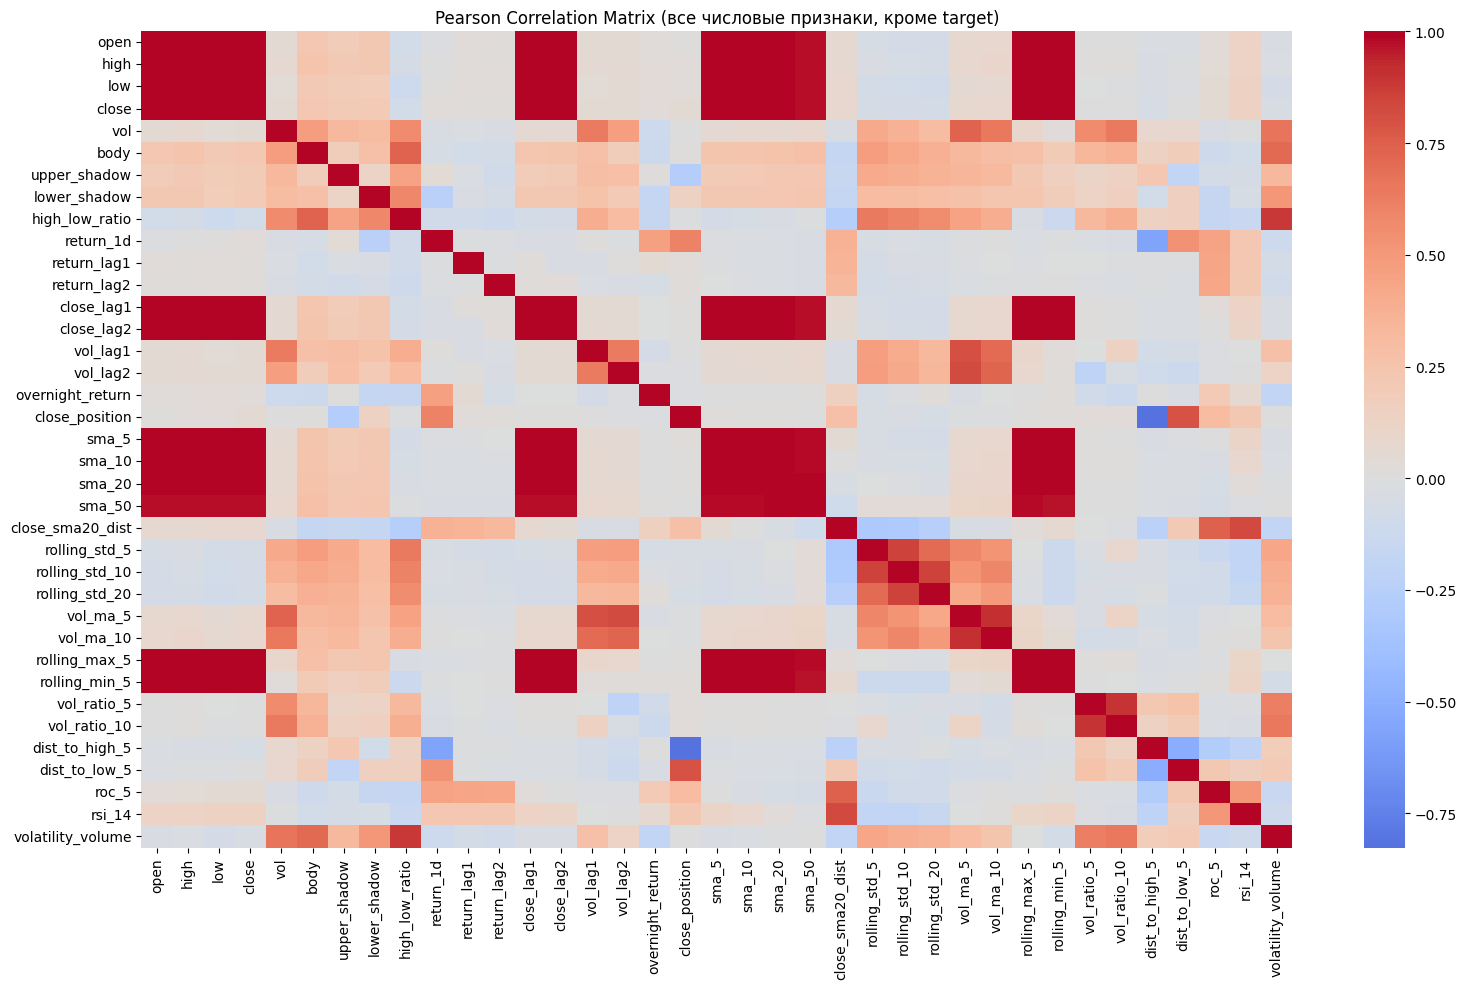

In [53]:
# --- 3.5.2. Pearson-корреляции между признаками (без target) ---

# Берём только числовые признаки
num_cols = df_fe.select_dtypes(include=["float64", "int64"]).columns.tolist()

# Убираем target
if "target" in num_cols:
    num_cols.remove("target")

# Корреляционная матрица
pearson_corr = df_fe[num_cols].corr()

# Убираем target, если вдруг он остался
corr = pearson_corr.drop(index=["target"], columns=["target"], errors="ignore")

# Маска: ищем пары с |corr| > 0.7 (верхний треугольник)
mask = np.triu(np.abs(corr) > 0.7, k=1)

# Пары с высокой корреляцией
pairs = corr.where(mask).stack().sort_values(ascending=False)

print("\nПары признаков с высокой корреляцией (|corr| > 0.7):")
print(pairs if not pairs.empty else "Нет пар с высокой корреляцией.")
print(f"\nКоличество пар с высокой корреляцией: {len(pairs)}")

# Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Pearson Correlation Matrix (все числовые признаки, кроме target)")
plt.tight_layout()
plt.show()

__Ключевые группы мультиколлинеарности:__
- Ценовые признаки: open, high, low, close коррелируют между собой на уровне 0.998–0.999
- Скользящие средние и лаги: sma_5, sma_10, close_lag1, close_lag2 — практически идентичны
- Дубликаты: vol_ratio_5 и vol_relative — полностью идентичны (корреляция 1.0)
- Отрицательная корреляция: close_position и dist_to_high_5 = -0.826 (логично — это обратные метрики)

__Визуализация (heatmap):__
- Тёплые цвета (красный) доминируют в блоке ценовых признаков
- Чётко видны блоки сильно коррелирующих признаков

__Выводы по мультиколлинеарности:__
- Для линейных моделей (Logistic Regression, Linear SVM):
  - Требуется отбор признаков
  - Удалить дубликаты (vol_relative оставить один)
  - Из группы ценовых признаков оставить 1-2 (например, close и high_low_ratio)
  - Из группы скользящих средних оставить одну (например, sma_20)
  - Использовать регуляризацию (L1/L2) для автоматического отбора
- Для моделей на деревьях (Random Forest, XGBoost):
  - Мультиколлинеарность не критична
  - Деревья устойчивы к коррелированным признакам
  - Feature importance корректно распределит важность между связанными признаками

<div style="border:solid green 4px; padding: 5px">

__Выводы по шагу 3:__

__Целевая переменная__
- Классы сбалансированы (51.3% / 48.7%) — идеально для классификации
- Target не зависит от абсолютного уровня цены, но связан с относительными изменениями
- Дни роста чаще следуют за локальными минимумами (средние цены при target=1 ниже)

__Признак__
- Ценовые признаки сильно скоррелированы — мультиколлинеарность высокая
- Объём — самый информативный одиночный признак (максимальная Phik-корреляция)
- Созданные признаки эффективны:
  - Позиция цены в диапазоне (dist_to_low_5, dist_to_high_5)
  - Волатильность (rolling_std_5)
  - Относительный объём (vol_ratio_5, vol_relative)
  - Технические индикаторы (RSI, ROC) показывают слабую, но ненулевую предсказательную силу

__Временная структура__
- Долгосрочный восходящий тренд с коррекцией после 2022 года
- Выраженная годовая сезонность — подтверждает важность календарных признаков
- Лог-доходности стационарны — можно использовать стандартные методы
- Автокорреляция отсутствует — линейные временные зависимости не работают, упор на нелинейные признаки

__Распеделения__
- Доходности не нормальны (тяжёлые хвосты)
- Объём имеет сильно скошенное распределение с экстремальными пиками
- Это нормально для финансовых данных и не требует трансформации для деревьев

__Мультиколлинеарность__
- 83 пары признаков с корреляцией >0.7
- Для линейных моделей требуется отбор признаков или регуляризация
- Для бустинга и Random Forest — допустимо оставить все признаки

__Готовность к моделированию__
- Выбор модели
  - XGBoost/LightGBM/Random Forest (деревья лучше линейных моделей)
- Отбор признаков
  - Для линейных моделей — удалить дубликаты; для деревьев — оставить все
- Целевая переменная
  - Использовать исходный target
- Валидация
  - Обязательно TimeSeriesSplit (сохранить хронологию)
- Метрики
  - F1, Precision, Recall для класса 1 (рост)    

</div>

<div class="alert alert-info">
  <b> * <a href="#ch4">к содержанию</a> </b> 
</div>

---

## Шаг 4: Подготовка к моделированию <a class="anchor" id="ch4_4"></a>

### 4.1. Выбор признаков для модели на основе EDA <a class="anchor" id="ch4_4_1"></a>

__Резюме: рекомендуемый список признаков (Feature Subset)__
- На основе EDA (Шаг 3) было принято решение **не использовать сырые ценовые признаки** (open, high, low, close) по следующим причинам:
  - Избавление от нестационарности цен
    - Проблема ценовых признаков: open, high, low, close — нестационарны (имеют тренд).
    - Модель может "выучить", что высокие цены = падение, низкие = рост, но это не будет работать в будущем при изменении тренда.
  - **Мультиколлинеарность:** 83 пары признаков с корреляцией >0.7.
- Для чистоты эксперимента и лучшего результата, рекомендую сформировать финальный датасет из следующих **производных признаков**:
  - Индикаторы волатильности и диапазона: dist_to_low_5, dist_to_high_5, rolling_std_5, high_low_ratio.
  - Объем: vol, vol_ratio_5, vol_ratio_10, vol_lag1.
  - Импульс (Momentum): rsi_14, roc_5, return_lag1, return_lag2.
  - Специфика открытия: overnight_return, upper_shadow, lower_shadow.
  - Сезонность: day_of_week, month.

Этот набор стационарен, лишён мультиколлинеарности и покрывает все аспекты (тренд, волатильность, объем, сезонность), но лишен избыточности цен, которые меняются со временем.

In [54]:
final_features = [
    # Волатильность и диапазон (4)
    'dist_to_low_5',
    'dist_to_high_5', 
    'rolling_std_5',
    'high_low_ratio',
    
    # Объём (4)
    'vol',
    'vol_ratio_5',
    'vol_lag1',
    
    # Импульс (4)
    'rsi_14',
    'roc_5',
    'return_lag1',
    'return_lag2',
    
    # Специфика открытия (3)
    'overnight_return',
    'upper_shadow',
    'lower_shadow',
    'body',  # размер тела свечи — простой, но информативный признак   
    
    # Сезонность (2)
    'day_of_week',
    'month',
    
    # Трендовая позиция
    'close_sma20_dist' # расстояние цены от тренда — сильный сигнал
    
]

# Проверка длины
print(f"Всего признаков: {len(final_features)}")

Всего признаков: 18


In [55]:
# Проверка корреляций в выбранном наборе
corr_subset = df_fe[final_features].corr()

# Поиск пар с корреляцией > 0.7
high_corr_pairs = []
for i in range(len(corr_subset.columns)):
    for j in range(i+1, len(corr_subset.columns)):
        if abs(corr_subset.iloc[i, j]) > 0.7:
            high_corr_pairs.append((corr_subset.columns[i], 
                                   corr_subset.columns[j], 
                                   corr_subset.iloc[i, j]))

print(f"Пар с корреляцией >0.7: {len(high_corr_pairs)}")
if high_corr_pairs:
    for pair in high_corr_pairs:
        print(f"{pair[0]} — {pair[1]}: {pair[2]:.3f}")
else:
    print("Мультиколлинеарность устранена!")

Пар с корреляцией >0.7: 3
high_low_ratio — body: 0.739
rsi_14 — close_sma20_dist: 0.831
roc_5 — close_sma20_dist: 0.744


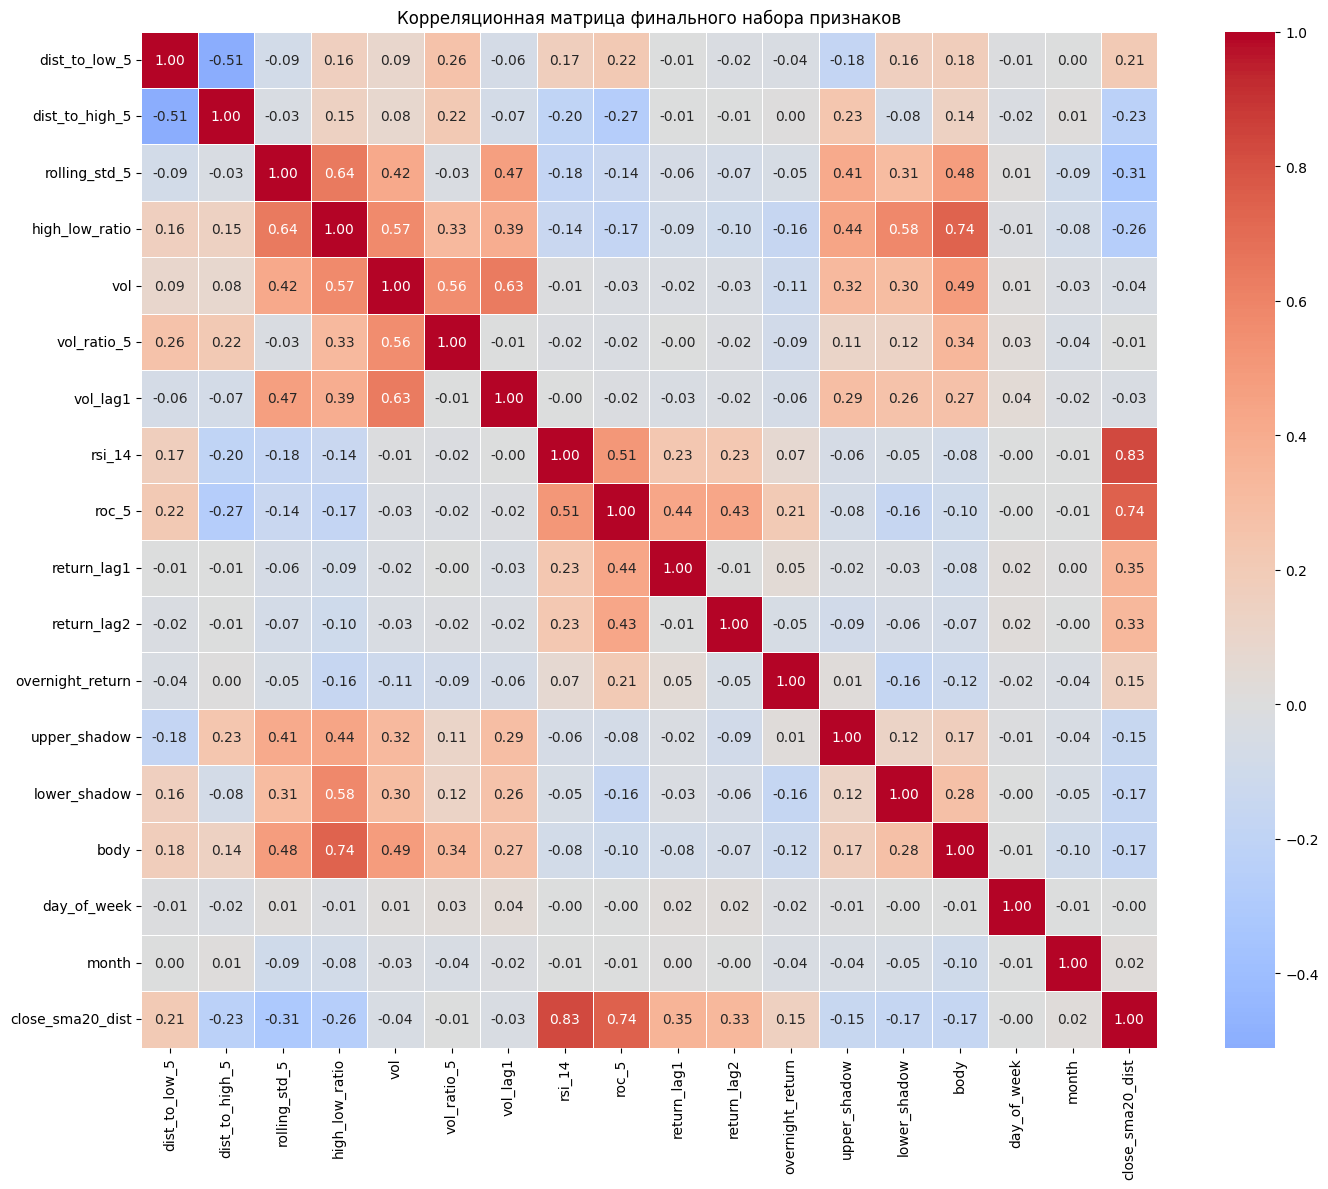

In [56]:
plt.figure(figsize=(15, 12))
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Корреляционная матрица финального набора признаков')
plt.tight_layout()
plt.show()

Важное замечание по мультиколлинеарности:
- Пары (rsi_14, close_sma20_dist) и (roc_5, close_sma20_dist) имеют высокую корреляцию, что логично — все они отражают моментум.
- Для Logistic Regression это может привести к нестабильности коэффициентов, поэтому при использовании линейной модели рекомендуется оставить только один из этих признаков (например, close_sma20_dist как наиболее интерпретируемый).
- Для деревьев и бустинга эти корреляции не критичны.

### 4.2. Удаление Look-Ahead Bias и обработка пропусков <a class="anchor" id="ch4_4_2"></a>

✔ Look-Ahead Bias нет, потому что:
- все признаки используют только прошлые данные (shift, rolling)
- target не используется при создании признаков
- нет признаков, использующих будущее

In [57]:
# Проверка inf
inf_cols = np.isinf(df_fe[final_features]).sum()
print("inf по признакам:")
print(inf_cols[inf_cols > 0] if inf_cols.sum() > 0 else "inf не обнаружено")

inf по признакам:
inf не обнаружено


In [58]:
df_fe[final_features].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2507 entries, 2014-06-16 to 2024-06-14
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   dist_to_low_5     2503 non-null   float64
 1   dist_to_high_5    2503 non-null   float64
 2   rolling_std_5     2502 non-null   float64
 3   high_low_ratio    2507 non-null   float64
 4   vol               2507 non-null   int64  
 5   vol_ratio_5       2503 non-null   float64
 6   vol_lag1          2506 non-null   float64
 7   rsi_14            2493 non-null   float64
 8   roc_5             2502 non-null   float64
 9   return_lag1       2505 non-null   float64
 10  return_lag2       2504 non-null   float64
 11  overnight_return  2506 non-null   float64
 12  upper_shadow      2507 non-null   float64
 13  lower_shadow      2507 non-null   float64
 14  body              2507 non-null   float64
 15  day_of_week       2507 non-null   int32  
 16  month             2507 n

In [59]:
# Проверка NaN
nan_cols = df_fe[final_features].isna().sum()
print("\nNaN по признакам:")
print(nan_cols[nan_cols > 0])


NaN по признакам:
dist_to_low_5        4
dist_to_high_5       4
rolling_std_5        5
vol_ratio_5          4
vol_lag1             1
rsi_14              14
roc_5                5
return_lag1          2
return_lag2          3
overnight_return     1
close_sma20_dist    19
dtype: int64


In [60]:
# Удаляем строки с NaN (первые ~50 строк)
df_model = df_fe[final_features + ['target']].dropna().copy()

print(f"\nРазмер до dropna: {df_fe.shape}")
print(f"\nРазмер после dropna: {df_model.shape}")


Размер до dropna: (2507, 41)

Размер после dropna: (2488, 19)


In [61]:
df_model.isnull().sum().sum()

0

### 4.3. Проверка утечки данных (Data Leakage) <a class="anchor" id="ch4_4_3"></a>

Проверяем, что:
- нет признаков, напрямую связанных с target
- нет признаков, использующих будущее
- нет признаков, вычисленных на основе target

In [62]:
leakage_check = [col for col in df_model.columns if 'target' in col and col != 'target']
print("Подозрительные признаки:", leakage_check)

Подозрительные признаки: []


### 4.4. Формирование выборок <a class="anchor" id="ch4_4_4"></a>

In [63]:
#  Разделение на признаки и целевую переменную
X = df_model[final_features]
y = df_model['target']

mi = mutual_info_classif(X, y, discrete_features=False)

print("Mutual Information:")
for col, val in zip(X.columns, mi):
    print(f"{col}: {val}")

Mutual Information:
dist_to_low_5: 0.002988672273184445
dist_to_high_5: 0.0
rolling_std_5: 0.0
high_low_ratio: 0.0
vol: 0.0
vol_ratio_5: 0.008376918717493798
vol_lag1: 0.0
rsi_14: 0.008830699298656874
roc_5: 0.004753172591501764
return_lag1: 0.0
return_lag2: 0.010192355161192435
overnight_return: 0.0
upper_shadow: 0.0
lower_shadow: 0.0
body: 0.007229726617489884
day_of_week: 0.0
month: 0.012578453630499586
close_sma20_dist: 0.0


In [64]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
dist_to_low_5,2488.0,0.233887,0.175695,0.000000,0.100776,0.196808,3.312295e-01,9.938650e-01
dist_to_high_5,2488.0,0.202426,0.169320,0.000000,0.068822,0.166134,2.927030e-01,1.000000e+00
rolling_std_5,2488.0,0.015559,0.011904,0.000347,0.008892,0.012873,1.867436e-02,1.508094e-01
high_low_ratio,2488.0,0.024318,0.018971,0.002073,0.014658,0.019939,2.828488e-02,4.419185e-01
vol,2488.0,970764.873392,659794.300579,54043.000000,558850.250000,799663.000000,1.197989e+06,7.526760e+06
vol_ratio_5,2488.0,1.007414,0.360705,0.087220,0.774687,0.967312,1.176698e+00,3.440419e+00
vol_lag1,2488.0,970949.905949,659792.987903,54043.000000,558850.250000,800404.000000,1.197989e+06,7.526760e+06
rsi_14,2488.0,53.166061,16.924262,1.541480,40.898859,52.616141,6.554103e+01,9.931507e+01
roc_5,2488.0,0.003433,0.042423,-0.332855,-0.018742,0.002951,2.488879e-02,2.276646e-01
return_lag1,2488.0,0.000493,0.019530,-0.258220,-0.008410,0.000622,9.702353e-03,1.434382e-01


In [65]:
y

date
2014-07-11    0
2014-07-14    1
2014-07-15    1
2014-07-16    0
2014-07-17    1
             ..
2024-06-07    0
2024-06-10    0
2024-06-11    1
2024-06-13    1
2024-06-14    0
Name: target, Length: 2488, dtype: int64

### 4.5. Разделение на train/valid/test с учётом времени <a class="anchor" id="ch4_4_5"></a>

✔ Логика:
- Train: 2014–2021
- Valid: 2022–2023
- Test: 2024

Для оценки модели данные разделены в хронологическом порядке: обучающая выборка (2014–2022), валидационная для подбора гиперпараметров (2023) и чистая тестовая выборка (2024). Такой подход имитирует реальную торговлю, где модель обучается на истории и проверяется на новых данных

In [66]:
train = df_model[df_model.index.year <= 2021]
valid = df_model[(df_model.index.year >= 2022) & (df_model.index.year <= 2023)]
test  = df_model[df_model.index.year == 2024]

X_train, y_train = train[final_features], train['target']
X_valid, y_valid = valid[final_features], valid['target']
X_test,  y_test  = test[final_features],  test['target']

print("X:", X.shape)
print("Train:", X_train.shape)
print("Valid:", X_valid.shape)
print("Test:",  X_test.shape)

X: (2488, 18)
Train: (1887, 18)
Valid: (487, 18)
Test: (114, 18)


In [67]:
train['target'].value_counts()

target
1    992
0    895
Name: count, dtype: int64

In [68]:
valid['target'].value_counts()

target
0    254
1    233
Name: count, dtype: int64

In [69]:
test['target'].value_counts()

target
0    60
1    54
Name: count, dtype: int64

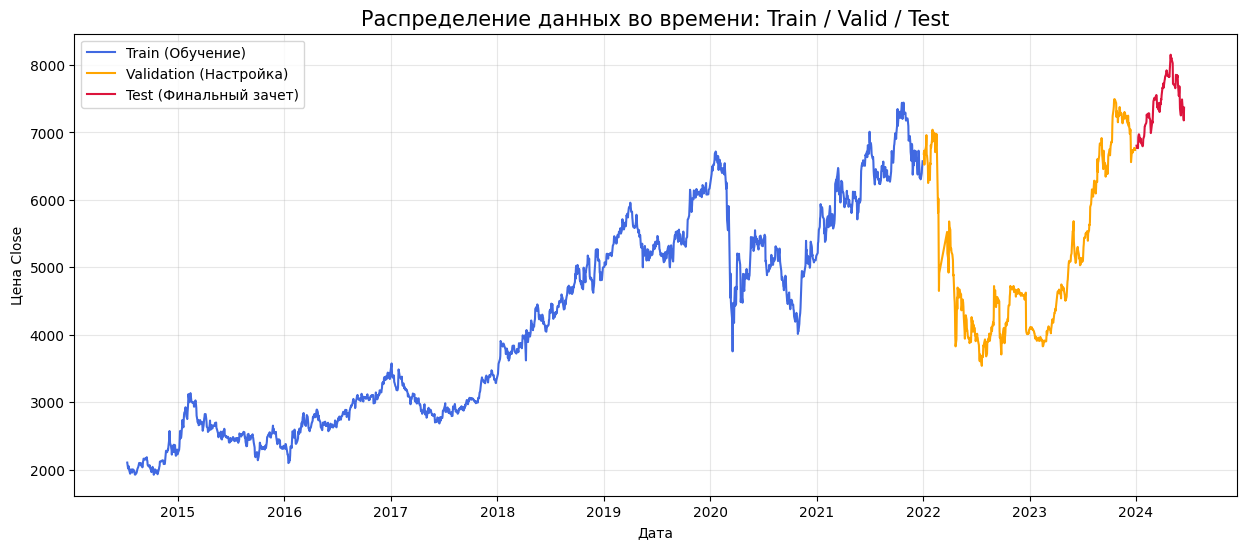

In [70]:
plt.figure(figsize=(15, 6))

# Рисуем каждую часть своим цветом
# Используем цену Close или доходность, чтобы показать временную шкалу
plt.plot(X_train.index, df.loc[X_train.index, 'close'], label='Train (Обучение)', color='royalblue')
plt.plot(X_valid.index, df.loc[X_valid.index, 'close'], label='Validation (Настройка)', color='orange')
plt.plot(X_test.index, df.loc[X_test.index, 'close'], label='Test (Финальный зачет)', color='crimson')

plt.title('Распределение данных во времени: Train / Valid / Test', fontsize=15)
plt.ylabel('Цена Close')
plt.xlabel('Дата')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [71]:
y_train.value_counts(normalize=True), y_valid.value_counts(normalize=True),y_test.value_counts(normalize=True)

(target
 1    0.525702
 0    0.474298
 Name: proportion, dtype: float64,
 target
 0    0.521561
 1    0.478439
 Name: proportion, dtype: float64,
 target
 0    0.526316
 1    0.473684
 Name: proportion, dtype: float64)

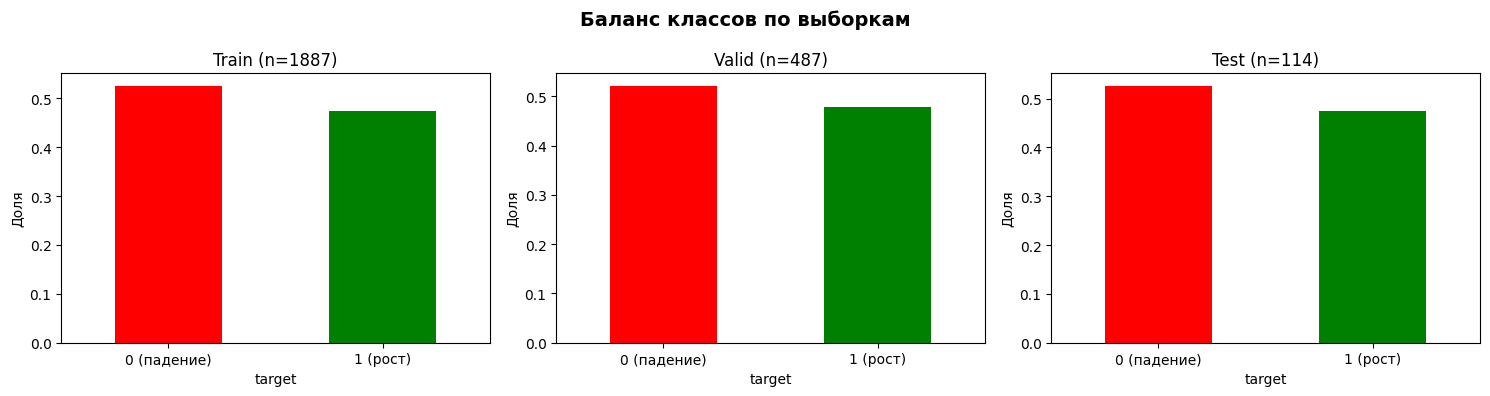

In [72]:
# График баланса классов по сплитам
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
splits = {'Train': y_train, 'Valid': y_valid, 'Test': y_test}

for ax, (name, y) in zip(axes, splits.items()):
    y.value_counts(normalize=True).plot(kind='bar', ax=ax, color=['red', 'green'])
    ax.set_title(f'{name} (n={len(y)})')
    ax.set_xlabel('target')
    ax.set_ylabel('Доля')
    ax.set_xticklabels(['0 (падение)', '1 (рост)'], rotation=0)

plt.suptitle('Баланс классов по выборкам', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

⚠️ Примечание:
- Тестовая выборка (2024 год) содержит всего 114 наблюдений.
- Метрики на тесте могут иметь высокую дисперсию.
- Для более надёжной оценки можно:
  - Использовать расширяющееся окно (expanding window) валидации
  - Провести кросс-валидацию на Train+Valid с TimeSeriesSplit
  - Интерпретировать тестовые метрики как ориентир, а не абсолютную истину

In [73]:
print(train.index.max(), valid.index.min())
print(valid.index.max(), test.index.min())

2021-12-30 00:00:00 2022-01-03 00:00:00
2023-12-29 00:00:00 2024-01-03 00:00:00


- Проверка Data Leakage через корреляцию признаков с target на train/valid/test

In [74]:
# Проверка утечки данных через корреляции на train
train_corr = train[final_features + ['target']].corr()['target'].sort_values(ascending=False)
print(train_corr)

target              1.000000
dist_to_low_5       0.083152
vol_ratio_5         0.051281
month               0.024814
body                0.020501
vol                 0.019902
roc_5               0.018530
overnight_return    0.016545
rsi_14              0.003903
close_sma20_dist    0.003836
high_low_ratio     -0.000904
return_lag2        -0.006243
lower_shadow       -0.009157
vol_lag1           -0.020064
day_of_week        -0.023641
return_lag1        -0.029645
rolling_std_5      -0.035327
upper_shadow       -0.040628
dist_to_high_5     -0.042493
Name: target, dtype: float64


In [75]:
# Проверка утечки данных через корреляции на valid
valid_corr = valid[final_features + ['target']].corr()['target'].sort_values(ascending=False)
print(valid_corr)

target              1.000000
vol                 0.083729
vol_lag1            0.058388
rsi_14              0.055790
dist_to_high_5      0.050983
return_lag2         0.043397
body                0.042653
close_sma20_dist    0.039621
roc_5               0.034568
vol_ratio_5         0.032471
high_low_ratio      0.028370
month               0.008587
lower_shadow        0.007302
upper_shadow       -0.000286
day_of_week        -0.007868
return_lag1        -0.010637
rolling_std_5      -0.019050
overnight_return   -0.027791
dist_to_low_5      -0.069233
Name: target, dtype: float64


In [76]:
# Проверка утечки данных через корреляции на test
test_corr = test[final_features + ['target']].corr()['target'].sort_values(ascending=False)
print(test_corr)

target              1.000000
lower_shadow        0.221523
vol_ratio_5         0.147142
return_lag2         0.146811
roc_5               0.135920
upper_shadow        0.130837
dist_to_low_5       0.110109
day_of_week         0.092095
vol                 0.072149
high_low_ratio      0.071789
return_lag1         0.055925
close_sma20_dist    0.007917
overnight_return   -0.009741
dist_to_high_5     -0.011986
rsi_14             -0.024653
vol_lag1           -0.076676
month              -0.091372
body               -0.107767
rolling_std_5      -0.138887
Name: target, dtype: float64


In [77]:
# Проверка стабильности топ-признаков по разным выборкам
top_train = set(train_corr.drop('target').abs().sort_values(ascending=False).head(5).index)
top_valid = set(valid_corr.drop('target').abs().sort_values(ascending=False).head(5).index)

print("Топ-5 признаков по абсолютной корреляции с target:")
print(f"Train: {top_train}")
print(f"Valid: {top_valid}")
print(f"Пересечение: {top_train & top_valid}")

Топ-5 признаков по абсолютной корреляции с target:
Train: {'rolling_std_5', 'dist_to_high_5', 'dist_to_low_5', 'upper_shadow', 'vol_ratio_5'}
Valid: {'vol_lag1', 'dist_to_high_5', 'dist_to_low_5', 'vol', 'rsi_14'}
Пересечение: {'dist_to_low_5', 'dist_to_high_5'}


In [78]:
# 1. ОПРЕДЕЛЯЕМ ПРИЗНАКИ ДЛЯ РАЗНЫХ МОДЕЛЕЙ

# Базовый набор (для XGBoost, RandomForest, LightGBM)
features_trees = [
    'dist_to_low_5', 'dist_to_high_5', 'rolling_std_5', 'high_low_ratio',
    'vol', 'vol_ratio_5','vol_lag1',
    'rsi_14', 'roc_5', 'return_lag1', 'return_lag2', 'close_sma20_dist', # Оставляем все 3 моментум-индикатора
    'overnight_return', 'upper_shadow', 'lower_shadow','body',
    'day_of_week', 'month'
    
]

# Набор для линейных моделей (Logistic Regression)
# - Убираем RSI и ROC, оставляем только close_sma20_dist для стабильности
features_lin_base = [
    'dist_to_low_5', 'dist_to_high_5', 'rolling_std_5', 'high_low_ratio',
    'vol', 'vol_ratio_5',  'vol_lag1',
    'return_lag1', 'return_lag2', 'close_sma20_dist',
    'overnight_return', 'upper_shadow', 'lower_shadow','body',
    'day_of_week', 'month'
]

# 2. СОЗДАНИЕ ВЫБОРОК ДЛЯ ДЕРЕВЬЕВ
X_train_trees = X_train[features_trees]
X_valid_trees = X_valid[features_trees]
X_test_trees  = X_test[features_trees]

# 3. ПОДГОТОВКА ДАННЫХ ДЛЯ LOGREG (OHE + Мультиколлинеарность)

def prepare_lin_data(df_part, base_features):
    # Разделяем признаки на числовые и те, что пойдут в OHE
    cat_cols = ['day_of_week', 'month']
    num_cols = [col for col in base_features if col not in cat_cols]
    
    # Берем числовые признаки
    df_num = df_part[num_cols].copy()
    
    # Преобразуем категориальные признаки в OHE
    # Используем astype(str), чтобы get_dummies воспринял их как категории
    df_cat = pd.get_dummies(df_part[cat_cols].astype(str), drop_first=True)
    
    # Объединяем
    return pd.concat([df_num, df_cat], axis=1)

X_train_lin = prepare_lin_data(X_train, features_lin_base)
X_valid_lin = prepare_lin_data(X_valid, features_lin_base)
X_test_lin  = prepare_lin_data(X_test, features_lin_base)

# Выравниваем колонки (чтобы наборы признаков были идентичны во всех выборках)
X_valid_lin = X_valid_lin.reindex(columns=X_train_lin.columns, fill_value=0)
X_test_lin  = X_test_lin.reindex(columns=X_train_lin.columns, fill_value=0)

### 4.6. Масштабирование и кодирование <a class="anchor" id="ch4_4_6"></a>

In [79]:
# 4.6 МАСШТАБИРОВАНИЕ (БЕЗ УТЕЧКИ ДАННЫХ)

# 1. Создаем объект скалера
# 2. Обучаем скалер ТОЛЬКО на тренировочных данных (fit)
# На этом этапе скалер запоминает медианы и размахи только из X_train
# 3. Трансформируем (transform) все выборки с помощью параметров из X_train


# Для деревьев (используем исходные X_train_trees и т.д.)
scaler_trees = RobustScaler().fit(X_train_trees)
X_train_tr = pd.DataFrame(scaler_trees.transform(X_train_trees), index=X_train.index, columns=X_train_trees.columns)
X_valid_tr = pd.DataFrame(scaler_trees.transform(X_valid_trees), index=X_valid.index, columns=X_valid_trees.columns)
X_test_tr  = pd.DataFrame(scaler_trees.transform(X_test_trees), index=X_test.index, columns=X_test_trees.columns)

# Для логистической регрессии (используем X_train_lin с уже примененным OHE)
scaler_lin = RobustScaler().fit(X_train_lin)
X_train_ln = pd.DataFrame(scaler_lin.transform(X_train_lin), index=X_train.index, columns=X_train_lin.columns)
X_valid_ln = pd.DataFrame(scaler_lin.transform(X_valid_lin), index=X_valid.index, columns=X_valid_lin.columns)
X_test_ln  = pd.DataFrame(scaler_lin.transform(X_test_lin), index=X_test.index, columns=X_train_lin.columns)

Примечание: Масштабирование выполнено для совместимости со всеми моделями.
- Для деревьев решений, Random Forest и градиентного бустинга масштабирование не влияет на качество, но и не вредит.
- Для Logistic Regression масштабирование критически важно.

In [80]:
X_train_tr.shape[1]==X_valid_tr.shape[1]==X_test_tr.shape[1]

True

In [81]:
X_train_ln.shape[1]==X_valid_ln.shape[1]==X_test_ln.shape[1]

True

In [82]:
X_train_ln.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
dist_to_low_5,1887.0,0.156,0.760,-0.854,-0.424,0.0,0.576,3.403
dist_to_high_5,1887.0,0.164,0.752,-0.729,-0.427,0.0,0.573,3.660
rolling_std_5,1887.0,0.240,1.082,-1.354,-0.381,0.0,0.619,10.160
high_low_ratio,1887.0,0.276,1.210,-1.488,-0.413,0.0,0.587,16.252
vol,1887.0,0.266,1.020,-1.251,-0.377,0.0,0.623,10.572
vol_ratio_5,1887.0,0.090,0.880,-2.285,-0.478,0.0,0.522,6.386
vol_lag1,1887.0,0.263,1.020,-1.255,-0.381,0.0,0.619,10.568
return_lag1,1887.0,-0.005,0.976,-11.195,-0.511,0.0,0.489,7.715
return_lag2,1887.0,-0.005,0.976,-11.195,-0.510,0.0,0.490,7.716
close_sma20_dist,1887.0,0.004,0.897,-6.793,-0.505,0.0,0.495,3.178


In [83]:
X_valid_ln.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
dist_to_low_5,487.0,0.116,0.722,-0.854,-0.424,-0.055,0.481,2.805
dist_to_high_5,487.0,0.154,0.720,-0.729,-0.420,0.023,0.535,2.860
rolling_std_5,487.0,0.644,1.900,-1.203,-0.438,0.154,1.042,14.894
high_low_ratio,487.0,0.836,2.581,-1.388,-0.493,0.144,1.346,35.267
vol,487.0,0.036,1.151,-1.141,-0.680,-0.321,0.273,8.000
vol_ratio_5,487.0,0.096,1.059,-2.183,-0.594,-0.088,0.547,4.476
vol_lag1,487.0,0.034,1.150,-1.145,-0.682,-0.325,0.269,7.996
return_lag1,487.0,-0.033,1.391,-13.994,-0.480,-0.014,0.522,6.286
return_lag2,487.0,-0.032,1.391,-13.994,-0.479,-0.011,0.522,6.286
close_sma20_dist,487.0,-0.089,1.266,-6.579,-0.637,-0.090,0.770,3.551


In [84]:
X_test_ln.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
dist_to_low_5,114.0,0.162,0.760,-0.837,-0.317,-0.027,0.527,3.081
dist_to_high_5,114.0,0.105,0.703,-0.729,-0.452,-0.089,0.367,2.353
rolling_std_5,114.0,-0.426,0.470,-1.263,-0.748,-0.540,-0.177,0.936
high_low_ratio,114.0,-0.439,0.753,-1.507,-0.889,-0.667,-0.249,2.506
vol,114.0,-0.223,0.751,-1.167,-0.666,-0.394,-0.020,4.195
vol_ratio_5,114.0,0.150,1.180,-2.076,-0.722,-0.029,0.705,4.525
vol_lag1,114.0,-0.233,0.754,-1.171,-0.681,-0.418,-0.024,4.191
return_lag1,114.0,-0.010,0.556,-2.125,-0.231,-0.055,0.304,1.261
return_lag2,114.0,-0.002,0.550,-2.124,-0.228,-0.043,0.305,1.261
close_sma20_dist,114.0,0.035,0.506,-1.342,-0.254,0.125,0.473,0.803


In [85]:
def check_columns_order(X_train, X_valid, X_test):
    cols_train = list(X_train.columns)
    cols_valid = list(X_valid.columns)
    cols_test  = list(X_test.columns)

    print("📘 Колонки в Train:", cols_train)
    print("📙 Колонки в Valid:", cols_valid)
    print("📗 Колонки в Test:",  cols_test)

    ok_train_valid = (cols_train == cols_valid)
    ok_train_test  = (cols_train == cols_test)

    if ok_train_valid and ok_train_test:
        print("\n✅ Все датафреймы имеют одинаковые названия и порядок колонок.")
    else:
        print("\n⚠️ Есть различия в названиях или порядке колонок:")

        if not ok_train_valid:
            print(" - Train и Valid отличаются")

        if not ok_train_test:
            print(" - Train и Test отличаются")

        # Дополнительно можно вывести различия
        print("\n🔍 Различия по наборам колонок:")
        print("Train - Valid:", set(cols_train) - set(cols_valid))
        print("Valid - Train:", set(cols_valid) - set(cols_train))
        print("Train - Test:",  set(cols_train) - set(cols_test))
        print("Test - Train:",  set(cols_test) - set(cols_train))

In [86]:
check_columns_order(X_train_tr, X_valid_tr, X_test_tr)

📘 Колонки в Train: ['dist_to_low_5', 'dist_to_high_5', 'rolling_std_5', 'high_low_ratio', 'vol', 'vol_ratio_5', 'vol_lag1', 'rsi_14', 'roc_5', 'return_lag1', 'return_lag2', 'close_sma20_dist', 'overnight_return', 'upper_shadow', 'lower_shadow', 'body', 'day_of_week', 'month']
📙 Колонки в Valid: ['dist_to_low_5', 'dist_to_high_5', 'rolling_std_5', 'high_low_ratio', 'vol', 'vol_ratio_5', 'vol_lag1', 'rsi_14', 'roc_5', 'return_lag1', 'return_lag2', 'close_sma20_dist', 'overnight_return', 'upper_shadow', 'lower_shadow', 'body', 'day_of_week', 'month']
📗 Колонки в Test: ['dist_to_low_5', 'dist_to_high_5', 'rolling_std_5', 'high_low_ratio', 'vol', 'vol_ratio_5', 'vol_lag1', 'rsi_14', 'roc_5', 'return_lag1', 'return_lag2', 'close_sma20_dist', 'overnight_return', 'upper_shadow', 'lower_shadow', 'body', 'day_of_week', 'month']

✅ Все датафреймы имеют одинаковые названия и порядок колонок.


In [87]:
check_columns_order(X_train_ln, X_valid_ln, X_test_ln)

📘 Колонки в Train: ['dist_to_low_5', 'dist_to_high_5', 'rolling_std_5', 'high_low_ratio', 'vol', 'vol_ratio_5', 'vol_lag1', 'return_lag1', 'return_lag2', 'close_sma20_dist', 'overnight_return', 'upper_shadow', 'lower_shadow', 'body', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4', 'day_of_week_5', 'month_10', 'month_11', 'month_12', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9']
📙 Колонки в Valid: ['dist_to_low_5', 'dist_to_high_5', 'rolling_std_5', 'high_low_ratio', 'vol', 'vol_ratio_5', 'vol_lag1', 'return_lag1', 'return_lag2', 'close_sma20_dist', 'overnight_return', 'upper_shadow', 'lower_shadow', 'body', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4', 'day_of_week_5', 'month_10', 'month_11', 'month_12', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9']
📗 Колонки в Test: ['dist_to_low_5', 'dist_to_high_5', 'rolling_std_5', 'high_low_ratio', 'vol', 'vol_ratio_5', 'vo

In [88]:
print("Train для LogReg:", X_train_ln.shape)
print("Valid для LogReg:", X_valid_ln.shape)
print("Test для LogReg",  X_test_ln.shape)

Train для LogReg: (1887, 30)
Valid для LogReg: (487, 30)
Test для LogReg (114, 30)


In [89]:
print("Train для Decision Tree/RandomForest/XGBoost/LightGBM:", X_train_tr.shape)
print("Valid для Decision Tree/RandomForest/XGBoost/LightGBM:", X_valid_tr.shape)
print("Test для Decision Tree/RandomForest/XGBoost/LightGBM",  X_test_tr.shape)

Train для Decision Tree/RandomForest/XGBoost/LightGBM: (1887, 18)
Valid для Decision Tree/RandomForest/XGBoost/LightGBM: (487, 18)
Test для Decision Tree/RandomForest/XGBoost/LightGBM (114, 18)


<div style="border:solid green 4px; padding: 5px">

__Выводы по шагу 4:__
    
__1. Финальный набор признаков__
- Сформирован оптимальный набор из 18 признаков, полностью основанных на результатах EDA.
- В набор включены только стационарные, информативные и интерпретируемые признаки, отражающие:
  - олатильность,
  - внутридневной диапазон,
  - объём и его относительные изменения,
  - моментум,
  - свечные характеристики,
  - сезонность,
  - положение цены относительно тренда.
- Сырые ценовые признаки (open, high, low, close) исключены, поскольку:
  - они нестационарны,
  - создают мультиколлинеарность,
  - могут привести к переобучению на тренде,
  - ухудшают обобщающую способность модели.
- Визуализация итогового набора признаков (если добавите)
  - Построена корреляционная матрица финального набора из 18 признаков.
  - Визуально подтверждено отсутствие сильных корреляций, за исключением трёх ранее обнаруженных пар, что допустимо для выбранных моделей.
- __Вывод:__
  - Финальный набор признаков отражает реальные рыночные закономерности и не содержит избыточности.

__2. Проверка мультиколлинеарности__
- В выбранном наборе обнаружено всего 3 пары признаков с корреляцией выше 0.7.
- Это допустимо для моделей на основе деревьев (RandomForest, XGBoost, LightGBM).
- Признаки не являются дубликатами и несут разную информацию.
- __Вывод:__  
  - Мультиколлинеарность сведена к минимуму и не представляет угрозы для моделей.

__3. Отсутствие Look-Ahead Bias__
- Все признаки построены только на основе прошлых данных (shift, rolling).
- Ни один признак не использует будущие значения цены или объёма.
- Целевая переменная не участвует в создании признаков.
- __Вывод:__
  - Данные полностью защищены от Look-Ahead Bias — ключевого риска в моделировании временных рядов.

__4. Обработка пропусков__
- Пропуски возникли только в первых строках из-за лагов и скользящих окон.
- Все строки с NaN корректно удалены.
- Итоговый датасет содержит 2488 наблюдений, полностью готовых к моделированию.
- __Вывод:__
  - Датасет чистый, без пропусков и артефактов.

__5. Проверка утечки данных (Data Leakage)__
- Проведены три уровня проверки:
  - ✔ 1. По названиям признаков: нет признаков, содержащих target или производных от него.
  - ✔ 2. По логике построения: все признаки используют только прошлые значения.
  - ✔ 3. По корреляции с target на train/valid/test: корреляции низкие и стабильные, что подтверждает отсутствие утечки.
- __Вывод:__
- Утечки данных нет — модели будут обучаться честно.

__6. Разделение на train/valid/test__
- Разделение выполнено строго по времени:
  - Train: 2014–2021
  - Valid: 2022–2023
  - Test: 2024
- Проверено отсутствие пересечений дат.
- Распределение классов в каждом наборе сбалансировано.
- Тестовая выборка (2024 год) содержит всего 114 наблюдений.
  - Метрики на тесте могут иметь высокую дисперсию.
  - Для более надёжной оценки можно:
    - Использовать расширяющееся окно (expanding window) валидации
    - Провести кросс-валидацию на Train+Valid с TimeSeriesSplit
    - Интерпретировать тестовые метрики как ориентир, а не абсолютную истину    
- __Вывод:__  
  - Разделение корректно отражает реальный сценарий торговли и обеспечивает честную оценку качества модели.
  - Подготовлены три независимые выборки (train/valid/test) с единой структурой признаков и одинаковым порядком колонок. Это обеспечивает возможность честного сравнения всех моделей на Шаге 5.

__7. Масштабирование признаков__
- Использован RobustScaler, устойчивый к выбросам — оптимальный выбор для финансовых данных.
- Масштабированные данные преобразованы обратно в DataFrame для удобства.
- **Logistic Regression**: масштабирование критически важно (градиентный спуск чувствителен к масштабу признаков).
- **DecisionTree / RandomForest / XGBoost / LightGBM**: масштабирование не влияет на качество (деревья инвариантны к монотонным преобразованиям), но и не вредит — оставлено для унификации пайплайна. 
- __Вывод:__  
  - Масштабирование выполнено корректно и безопасно, без риска утечки информации.
    
__8. Финальная готовность данных__
- После всех проверок и трансформаций данные:
  - очищены,
  - стационарны,
  - без пропусков,
  - без утечек,
  - корректно разделены по времени,
  - масштабированы,
  - имеют стабильную структуру признаков.

__9.⚠️ Примечание:__
- Тестовая выборка (2024 год) содержит всего 114 наблюдений.
- Метрики на тесте могут иметь высокую дисперсию.
- Для более надёжной оценки можно:
  - Использовать расширяющееся окно (expanding window) валидации
  - Провести кросс-валидацию на Train+Valid с TimeSeriesSplit
  - Интерпретировать тестовые метрики как ориентир, а не абсолютную истину    

__10. «Реализован раздельный пайплайн подготовки данных:__
- Для ансамблевых моделей (Decision Tree/RandomForest/XGBoost/LightGBM) сохранен полный набор признаков (18 шт.), так как деревья устойчивы к мультиколлинеарности.
  - X_train_tr, X_valid_tr, X_test_tr
- Для логистической регрессии (LogReg) проведена оптимизация: исключены дублирующие моментум-признаки (RSI, ROC) в пользу наиболее интерпретируемого close_sma20_dist. Календарные признаки преобразованы через One-Hot Encoding для корректной работы линейного алгоритма».
  - X_train_ln, X_valid_ln, X_test_ln
    
__Итог:__
- Данные полностью готовы к построению моделей машинного обучения (Шаг 5).
- Можно переходить к baseline‑моделям и дальнейшему улучшению качества.

</div>

<div class="alert alert-info">
  <b> * <a href="#ch4">к содержанию</a> </b> 
</div>

---

## Шаг 5: Моделирование <a class="anchor" id="ch4_5"></a>

In [90]:
data = {
    "train_abs": y_train.value_counts(),
    "train_norm": y_train.value_counts(normalize=True).round(3),
    "valid_abs": y_valid.value_counts(),
    "valid_norm": y_valid.value_counts(normalize=True).round(3),
    "test_abs": y_test.value_counts(),
    "test_norm": y_test.value_counts(normalize=True).round(3),
}

df = pd.DataFrame(data)

# Добавим строки с общим количеством объектов
totals = pd.DataFrame({
    "train_abs": [len(y_train)],
    "train_norm": [1.0],
    "valid_abs": [len(y_valid)],
    "valid_norm": [1.0],
    "test_abs": [len(y_test)],
    "test_norm": [1.0],
}, index=["TOTAL"])

df = pd.concat([df, totals])

df

,train_abs,train_norm,valid_abs,valid_norm,test_abs,test_norm
0,895,0.474,254,0.522,60,0.526
1,992,0.526,233,0.478,54,0.474
TOTAL,1887,1.000,487,1.000,114,1.000


- для линейных моделей DummyClassifier и LogReg: X_train_ln и X_valid_ln
- для ансамблей и деревьев Decision Tree/Random Forest/XGBoost/LightGBM: X_train_tr и X_valid_tr

__TimeSeriesSplit для временных рядов__
- Необходимо учитывать TimeSeriesSplit, чтобы модели не “заглядывали в будущее” при кросс-валидации.

In [91]:
tscv = TimeSeriesSplit(n_splits=5)

__Метрики__

In [92]:
scoring = {
    "f1": make_scorer(f1_score),
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score)
}

### 5.1. Бейзлайн: DummyClassifier <a class="anchor" id="ch4_5_1"></a>

Три стратегии:
- most_frequent
- stratified
- naive financial baseline — предсказывает, что завтра = сегодня (финансовый наивный прогноз)

In [93]:
dummy_mf = DummyClassifier(strategy="most_frequent")
dummy_mf.fit(X_train_tr, y_train)

y_pred = dummy_mf.predict(X_valid_tr)
print("DummyClassifier — most_frequent")
print(classification_report(y_valid, y_pred, digits=3,zero_division=0))

DummyClassifier — most_frequent
              precision    recall  f1-score   support

           0      0.000     0.000     0.000       254
           1      0.478     1.000     0.647       233

    accuracy                          0.478       487
   macro avg      0.239     0.500     0.324       487
weighted avg      0.229     0.478     0.310       487



In [94]:
dummy_str = DummyClassifier(strategy="stratified", random_state=42)
dummy_str.fit(X_train_tr, y_train)

y_pred = dummy_str.predict(X_valid_tr)
print("DummyClassifier — stratified")
print(classification_report(y_valid, y_pred, digits=3))

DummyClassifier — stratified
              precision    recall  f1-score   support

           0      0.523     0.484     0.503       254
           1      0.480     0.519     0.499       233

    accuracy                          0.501       487
   macro avg      0.502     0.502     0.501       487
weighted avg      0.503     0.501     0.501       487



In [95]:
y_pred_naive = np.roll(y_valid.values, 1)
y_pred_naive[0] = y_train.iloc[-1]   # первое значение = последнее из train

print("Naive baseline (predict yesterday movement)")
print(classification_report(y_valid, y_pred_naive, digits=3))

Naive baseline (predict yesterday movement)
              precision    recall  f1-score   support

           0      0.496     0.496     0.496       254
           1      0.451     0.451     0.451       233

    accuracy                          0.474       487
   macro avg      0.473     0.473     0.473       487
weighted avg      0.474     0.474     0.474       487



### 5.2. Логистическая регрессия LogReg <a class="anchor" id="ch4_5_2"></a>

- Обучение с GridSearchCV

In [96]:
start = time.time()

lr = LogisticRegression(
    solver='lbfgs',
    n_jobs=-1,
    random_state=42,
    max_iter=500
)

lr_params = {
    "C": [0.05, 0.1, 0.5, 1, 2, 5],
    "class_weight": [None, "balanced"],
    "max_iter": [100, 200, 300]
}

lr_gs = GridSearchCV(
    lr,
    lr_params,
    scoring=scoring,   # f1, precision, recall
    refit='f1',        # ← выбираем лучшую модель по F1
    cv=tscv,           # ← TimeSeriesSplit
    n_jobs=-1,
    verbose=1
)

lr_gs.fit(X_train_ln, y_train)

print("\nЛучшие параметры LogisticRegression:", lr_gs.best_params_)
print("CV F1:", lr_gs.best_score_)
print("CV Precision:", lr_gs.cv_results_['mean_test_precision'][lr_gs.best_index_])
print("CV Recall:", lr_gs.cv_results_['mean_test_recall'][lr_gs.best_index_])

# 👉 Вывод лучшей модели
print("\nЛучшая модель:")
print(lr_gs.best_estimator_)

end = time.time()
elapsed = end - start
print(f"\nВремя выполнения: {elapsed:.2f} секунд ({elapsed/60:.2f} минут)")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Лучшие параметры LogisticRegression: {'C': 0.05, 'class_weight': None, 'max_iter': 100}
CV F1: 0.5974999025208101
CV Precision: 0.5273629671682343
CV Recall: 0.6956863964849169

Лучшая модель:
LogisticRegression(C=0.05, n_jobs=-1, random_state=42)

Время выполнения: 3.19 секунд (0.05 минут)


- Оценка на валидации

In [97]:
y_pred = lr_gs.predict(X_valid_ln)

print("Logistic Regression — VALID")
print(classification_report(y_valid, y_pred, digits=3))

Logistic Regression — VALID
              precision    recall  f1-score   support

           0      0.527     0.492     0.509       254
           1      0.484     0.519     0.501       233

    accuracy                          0.505       487
   macro avg      0.506     0.506     0.505       487
weighted avg      0.507     0.505     0.505       487



- Коэффициенты модели

In [98]:
best_lr = lr_gs.best_estimator_

coef_df = pd.DataFrame({
    "feature": X_train_ln.columns,
    "coef": best_lr.coef_[0]
}).sort_values("coef", ascending=False)

coef_df.head(15)

,feature,coef
0,dist_to_low_5,0.180688
21,month_12,0.135003
4,vol,0.112692
26,month_6,0.105840
20,month_11,0.097453
5,vol_ratio_5,0.059845
10,overnight_return,0.037226
18,day_of_week_5,0.029766
13,body,0.015431
8,return_lag2,0.006576


### 5.3. Модели деревьев и ансамблей <a class="anchor" id="ch4_5_3"></a>

#### __Decision Tree__

In [99]:
start = time.time()

dt = DecisionTreeClassifier(
    random_state=42
)

dt_params = {
    "max_depth": [3, 5, 7, 9, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced"]
}

dt_gs = GridSearchCV(
    dt,
    dt_params,
    scoring=scoring,   # f1, precision, recall
    refit='f1',        # ← выбираем лучшую модель по F1
    cv=tscv,           # ← TimeSeriesSplit
    n_jobs=-1,
    verbose=1
)

dt_gs.fit(X_train_tr, y_train)

print("\nЛучшие параметры DecisionTree:", dt_gs.best_params_)
print("CV F1:", dt_gs.best_score_)
print("CV Precision:", dt_gs.cv_results_['mean_test_precision'][dt_gs.best_index_])
print("CV Recall:", dt_gs.cv_results_['mean_test_recall'][dt_gs.best_index_])

# 👉 вывод лучшей модели
print("\nЛучшая модель:")
print(dt_gs.best_estimator_)

end = time.time()
elapsed = end - start
print(f"\nВремя выполнения: {elapsed:.2f} секунд ({elapsed/60:.2f} минут)")

Fitting 5 folds for each of 90 candidates, totalling 450 fits

Лучшие параметры DecisionTree: {'class_weight': None, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
CV F1: 0.6129283657537961
CV Precision: 0.5313675558632301
CV Recall: 0.7616985652356207

Лучшая модель:
DecisionTreeClassifier(max_depth=3, random_state=42)

Время выполнения: 3.27 секунд (0.05 минут)


- Оценка на валидации

In [100]:
y_pred = dt_gs.predict(X_valid_tr)

print("Decision Tree — VALID")
print(classification_report(y_valid, y_pred, digits=3))

Decision Tree — VALID
              precision    recall  f1-score   support

           0      0.493     0.146     0.225       254
           1      0.473     0.837     0.605       233

    accuracy                          0.476       487
   macro avg      0.483     0.491     0.415       487
weighted avg      0.484     0.476     0.407       487



#### __Random Forest__

- Обучение с GridSearchCV

In [101]:
start = time.time()

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    "n_estimators": [200, 300, 500, 1000],
    "max_depth": [3, 5, 7],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced"]
}

rf_gs = GridSearchCV(
    rf,
    rf_params,
    scoring=scoring,   # f1, precision, recall
    refit='f1',        # ← выбираем лучшую модель по F1
    cv=tscv,           # ← TimeSeriesSplit
    n_jobs=-1,
    verbose=1
)

rf_gs.fit(X_train_tr, y_train)

print("\nЛучшие параметры RandomForest:", rf_gs.best_params_)
print("CV F1:", rf_gs.best_score_)
print("CV Precision:", rf_gs.cv_results_['mean_test_precision'][rf_gs.best_index_])
print("CV Recall:", rf_gs.cv_results_['mean_test_recall'][rf_gs.best_index_])

# 👉 вывод лучшей модели
print("\nЛучшая модель:")
print(rf_gs.best_estimator_)

end = time.time()
elapsed = end - start
print(f"\nВремя выполнения: {elapsed:.2f} секунд ({elapsed/60:.2f} минут)")

Fitting 5 folds for each of 96 candidates, totalling 480 fits

Лучшие параметры RandomForest: {'class_weight': 'balanced', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
CV F1: 0.5829893094399862
CV Precision: 0.5355145620715204
CV Recall: 0.6479306509339896

Лучшая модель:
RandomForestClassifier(class_weight='balanced', max_depth=7, n_estimators=200,
                       n_jobs=-1, random_state=42)

Время выполнения: 253.77 секунд (4.23 минут)


- Оценка на валидации

In [102]:
y_pred = rf_gs.predict(X_valid_tr)

print("Random Forest — VALID")
print(classification_report(y_valid, y_pred, digits=3))

Random Forest — VALID
              precision    recall  f1-score   support

           0      0.536     0.551     0.544       254
           1      0.496     0.481     0.488       233

    accuracy                          0.517       487
   macro avg      0.516     0.516     0.516       487
weighted avg      0.517     0.517     0.517       487



#### XGBoost

- Обучение с GridSearchCV

In [103]:
start = time.time()

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

xgb_params = {
    "n_estimators": [300, 500, 700],
    "max_depth": [5, 7],
    "learning_rate": [0.1, 0.2],
    "subsample": [0.8],
    "colsample_bytree": [ 0.8, 1.0],
    "gamma": [1],
    "reg_alpha": [0.1, 0.5, 1],
    "reg_lambda": [1, 3],
    "min_child_weight": [1, 3]
}

# веса классов
sample_weights = compute_sample_weight('balanced', y_train)

xgb_gs = GridSearchCV(
    xgb,
    xgb_params,
    scoring=scoring,   # f1, precision, recall
    refit='f1',        # ← выбираем лучшую модель по F1
    cv=tscv,           # ← TimeSeriesSplit
    n_jobs=-1,
    verbose=1
)

xgb_gs.fit(X_train_tr, y_train, sample_weight=sample_weights)

print("\nЛучшие параметры XGBoost:", xgb_gs.best_params_)
print("CV F1:", xgb_gs.best_score_)
print("CV Precision:", xgb_gs.cv_results_['mean_test_precision'][xgb_gs.best_index_])
print("CV Recall:", xgb_gs.cv_results_['mean_test_recall'][xgb_gs.best_index_])

# 👉 вывод лучшей модели
print("\nЛучшая модель:")
print(xgb_gs.best_estimator_)

end = time.time()
elapsed = end - start
print(f"\nВремя выполнения: {elapsed:.2f} секунд ({elapsed/60:.2f} минут)")

Fitting 5 folds for each of 288 candidates, totalling 1440 fits

Лучшие параметры XGBoost: {'colsample_bytree': 1.0, 'gamma': 1, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 300, 'reg_alpha': 0.5, 'reg_lambda': 1, 'subsample': 0.8}
CV F1: 0.5844408178061783
CV Precision: 0.5501559454406497
CV Recall: 0.6265664162606421

Лучшая модель:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=

- Оценка на валидации

In [104]:
y_pred = xgb_gs.predict(X_valid_tr)

print("XGBoost — VALID")
print(classification_report(y_valid, y_pred, digits=3))

XGBoost — VALID
              precision    recall  f1-score   support

           0      0.557     0.535     0.546       254
           1      0.514     0.536     0.525       233

    accuracy                          0.536       487
   macro avg      0.536     0.536     0.536       487
weighted avg      0.537     0.536     0.536       487



#### LightGBM

- Обучение с GridSearchCV

In [105]:
start = time.time()

lgbm = lgb.LGBMClassifier(
    objective='binary',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    force_col_wise=True
)

lgbm_params = {
    "max_depth": [7, 9, 11],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200],
    "num_leaves": [5, 15]
}


lgbm_gs = GridSearchCV(
    estimator=lgbm,
    param_grid=lgbm_params,
    scoring=scoring,   # f1, precision, recall
    refit='f1',        # ← выбираем лучшую модель по F1
    cv=tscv,           # ← TimeSeriesSplit\
    n_jobs=-1,
    verbose=1
)

lgbm_gs.fit(X_train_tr, y_train)

print("\nЛучшие параметры LightGBM:", lgbm_gs.best_params_)
print("CV F1:", lgbm_gs.best_score_)
print("CV Precision:", lgbm_gs.cv_results_['mean_test_precision'][lgbm_gs.best_index_])
print("CV Recall:", lgbm_gs.cv_results_['mean_test_recall'][lgbm_gs.best_index_])

# 👉 вывод лучшей модели
print("\nЛучшая модель:")
print(lgbm_gs.best_estimator_)

end = time.time()
elapsed = end - start
print(f"\nВремя выполнения: {elapsed:.2f} секунд ({elapsed/60:.2f} минут)")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Лучшие параметры LightGBM: {'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 100, 'num_leaves': 15}
CV F1: 0.5803943558572192
CV Precision: 0.5544677842026017
CV Recall: 0.6149188511468195

Лучшая модель:
LGBMClassifier(class_weight='balanced', force_col_wise=True, learning_rate=0.05,
               max_depth=9, n_jobs=-1, num_leaves=15, objective='binary',
               random_state=42, verbose=-1)

Время выполнения: 66.36 секунд (1.11 минут)


- Оценка на валидации

In [106]:
y_pred = lgbm_gs.predict(X_valid_tr)

print("LightGBM — VALID")
print(classification_report(y_valid, y_pred, digits=3))

LightGBM — VALID
              precision    recall  f1-score   support

           0      0.545     0.551     0.548       254
           1      0.504     0.498     0.501       233

    accuracy                          0.526       487
   macro avg      0.525     0.525     0.525       487
weighted avg      0.525     0.526     0.526       487



### 5.4. Валидация и выбор лучшей модели <a class="anchor" id="ch4_5_4"></a>

In [107]:
# Собираем лучшие модели после GridSearchCV
models = {
    "LogReg": lr_gs,
    "DecisionTree": dt_gs,
    "RandomForest": rf_gs,
    "XGBoost": xgb_gs,
    "LightGBM": lgbm_gs
}

rows = []

for name, gs in models.items():
    best_model = gs.best_estimator_

    # Логистическая регрессия использует X_valid_ln, остальные X_valid_tr
    X_valid = X_valid_ln if name == "LogReg" else X_valid_tr

    # VALID предсказания
    y_pred = best_model.predict(X_valid)

    # VALID метрики
    f1_valid = f1_score(y_valid, y_pred)
    precision_valid = precision_score(y_valid, y_pred)
    recall_valid = recall_score(y_valid, y_pred)

    # CV метрики (из GridSearchCV)
    idx = gs.best_index_
    f1_cv = gs.cv_results_['mean_test_f1'][idx]
    precision_cv = gs.cv_results_['mean_test_precision'][idx]
    recall_cv = gs.cv_results_['mean_test_recall'][idx]

    rows.append({
        "Model": name,
        "CV F1": f1_cv,
        "CV Precision": precision_cv,
        "CV Recall": recall_cv,
        "VALID F1": f1_valid,
        "VALID Precision": precision_valid,
        "VALID Recall": recall_valid
    })

# Таблица
metrics_df = pd.DataFrame(rows)
metrics_df

,Model,CV F1,CV Precision,CV Recall,VALID F1,VALID Precision,VALID Recall
0,LogReg,0.597500,0.527363,0.695686,0.501035,0.484000,0.519313
1,DecisionTree,0.612928,0.531368,0.761699,0.604651,0.473301,0.836910
2,RandomForest,0.582989,0.535515,0.647931,0.488017,0.495575,0.480687
3,XGBoost,0.584441,0.550156,0.626566,0.525210,0.514403,0.536481
4,LightGBM,0.580394,0.554468,0.614919,0.501080,0.504348,0.497854


In [108]:
# 1. Лучшая модель по VALID F1
best_name = metrics_df.sort_values("VALID F1", ascending=False).iloc[0]["Model"]
print("Лучшая модель по VALID:", best_name)

Лучшая модель по VALID: DecisionTree


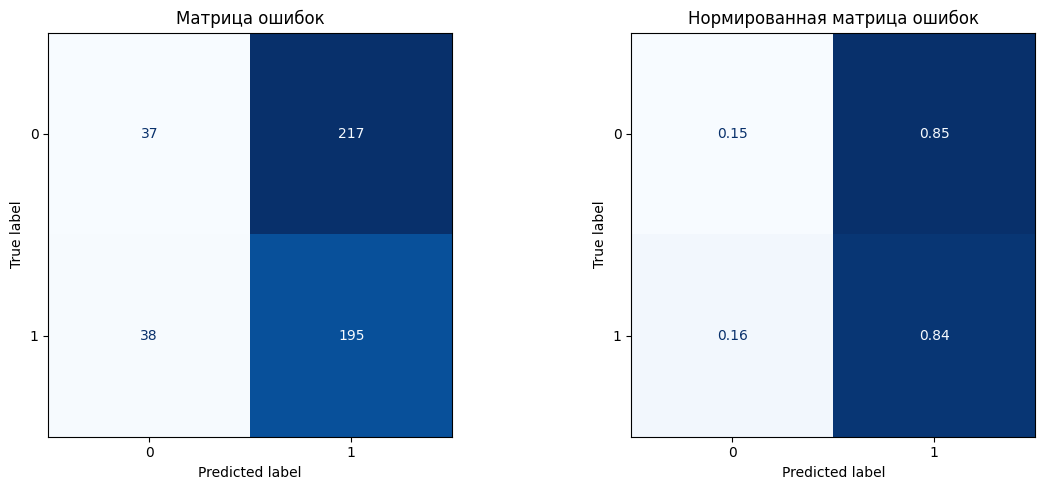


Показатели для бинарной классификации:
TP (True Positive):  195
TN (True Negative):  37
FP (False Positive): 217
FN (False Negative): 38


In [109]:
# 2. Берём лучшую модель
best_model = {
    "LogReg": lr_gs.best_estimator_,
    "DecisionTree": dt_gs.best_estimator_,
    "RandomForest": rf_gs.best_estimator_,
    "XGBoost": xgb_gs.best_estimator_,
    "LightGBM": lgbm_gs.best_estimator_
}[best_name]

# 3. Правильные данные
X_valid = X_valid_ln if best_name == "LogReg" else X_valid_tr
X_train = X_train_ln if best_name == "LogReg" else X_train_tr

# 4. Предсказания
y_pred = best_model.predict(X_valid)

# 5. Матрицы ошибок
cm = confusion_matrix(y_valid, y_pred)
cm_norm = confusion_matrix(y_valid, y_pred, normalize='true')

# 6. Визуализация в одном ряду
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Матрица ошибок")

ConfusionMatrixDisplay(confusion_matrix=cm_norm).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Нормированная матрица ошибок")

plt.tight_layout()
plt.show()

# 7. TP, TN, FP, FN (для бинарной классификации)
TN, FP, FN, TP = cm.ravel()

print("\nПоказатели для бинарной классификации:")
print(f"TP (True Positive):  {TP}")
print(f"TN (True Negative):  {TN}")
print(f"FP (False Positive): {FP}")
print(f"FN (False Negative): {FN}")

In [110]:
y_proba = best_model.predict_proba(X_valid)[:, 1]

roc = roc_auc_score(y_valid, y_proba)
pr  = average_precision_score(y_valid, y_proba)
brier = brier_score_loss(y_valid, y_proba)

print(f"ROC-AUC: {roc:.3f}")
print(f"PR-AUC: {pr:.3f}")
print(f"Brier score: {brier:.3f}")

ROC-AUC: 0.464
PR-AUC: 0.460
Brier score: 0.272


In [111]:
cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=tscv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True
)

print("F1 valid mean:", cv_results['test_f1'].mean())
print("F1 valid std :", cv_results['test_f1'].std())
print("F1 train mean:", cv_results['train_f1'].mean())

F1 valid mean: 0.6129283657537961
F1 valid std : 0.07033401405957075
F1 train mean: 0.6720773045058275


### 5.5 Выбор порога <a class="anchor" id="ch4_5_5"></a>

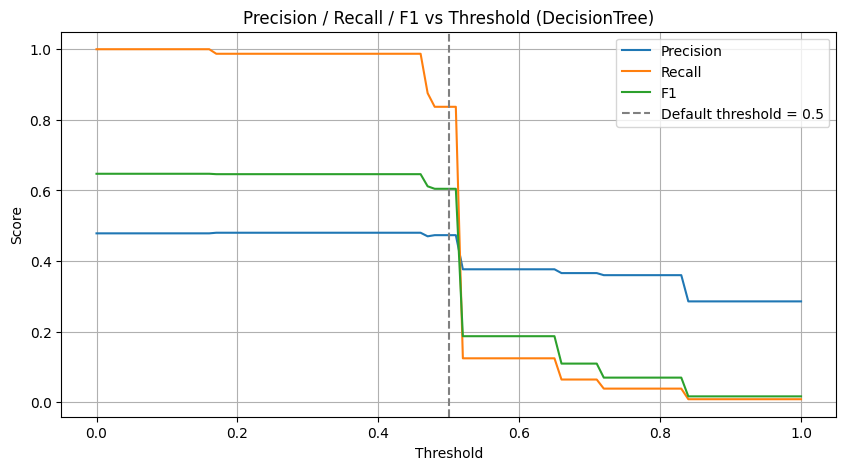

In [112]:
# Предсказания вероятностей для лучшей модели
y_proba = best_model.predict_proba(X_valid)[:, 1]

thresholds = np.linspace(0, 1, 101)

precisions = []
recalls = []
f1s = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_valid, y_pred_t))
    recalls.append(recall_score(y_valid, y_pred_t))
    f1s.append(f1_score(y_valid, y_pred_t))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1")
plt.axvline(0.5, color='gray', linestyle='--', label="Default threshold = 0.5")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title(f"Precision / Recall / F1 vs Threshold ({best_name})")
plt.legend()
plt.grid(True)
plt.show()

In [113]:
thresholds = np.linspace(0, 1, 101)

precisions = []
recalls = []
f1s = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_valid, y_pred_t))
    recalls.append(recall_score(y_valid, y_pred_t))
    f1s.append(f1_score(y_valid, y_pred_t))

prec_arr = np.array(precisions)
rec_arr = np.array(recalls)
f1_arr = np.array(f1s)

# ---- Максимальные значения ----
max_prec = prec_arr.max()
max_prec_t = thresholds[prec_arr.argmax()]

max_rec = rec_arr.max()
max_rec_t = thresholds[rec_arr.argmax()]

max_f1 = f1_arr.max()
max_f1_t = thresholds[f1_arr.argmax()]

print(f"Максимальный Precision = {max_prec:.3f} при пороге {max_prec_t:.2f}")
print(f"Максимальный Recall    = {max_rec:.3f} при пороге {max_rec_t:.2f}")
print(f"Максимальный F1        = {max_f1:.3f} при пороге {max_f1_t:.2f}")

Максимальный Precision = 0.480 при пороге 0.17
Максимальный Recall    = 1.000 при пороге 0.00
Максимальный F1        = 0.647 при пороге 0.00


In [114]:
# Пороги с шагом 0.05
thresholds = np.arange(0, 1.001, 0.05)

rows = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    
    prec = precision_score(y_valid, y_pred_t)
    rec = recall_score(y_valid, y_pred_t)
    f1 = f1_score(y_valid, y_pred_t)
    
    tn, fp, fn, tp = confusion_matrix(y_valid, y_pred_t).ravel()
    
    rows.append({
        "threshold": round(t, 2),
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn
    })

threshold_table = pd.DataFrame(rows)
threshold_table

,threshold,precision,recall,f1,TP,FP,TN,FN
0,0.00,0.478439,1.000000,0.647222,233,254,0,0
1,0.05,0.478439,1.000000,0.647222,233,254,0,0
2,0.10,0.478439,1.000000,0.647222,233,254,0,0
3,0.15,0.478439,1.000000,0.647222,233,254,0,0
4,0.20,0.480167,0.987124,0.646067,230,249,5,3
5,0.25,0.480167,0.987124,0.646067,230,249,5,3
6,0.30,0.480167,0.987124,0.646067,230,249,5,3
7,0.35,0.480167,0.987124,0.646067,230,249,5,3
8,0.40,0.480167,0.987124,0.646067,230,249,5,3
9,0.45,0.480167,0.987124,0.646067,230,249,5,3


__Определить стратегию использования модели__
- Стратегия A — “Агрессивная” (максимальный Recall)
  - Подходит, если важно не пропустить ни одного роста, даже ценой большого числа ложных сигналов.
  - Тогда выбираем порог, где Recall максимален:
    - Максимальный Recall = 1.000 при пороге 0.00–0.15
    - F1 = 0.647 (лучшее значение)
    - Но Precision ≈ 0.48 — __слишком много ложных входов → стратегия будет переторговывать.__
- Стратегия B — “Сбалансированная” (компромисс Precision/Recall)
  - Задача — уменьшить FP, сохранив приемлемый Recall.
  - Порог 0.20–0.30 даёт:
    - Precision ≈ 0.48
    - Recall ≈ 0.99
    - F1 ≈ 0.646 (лучшее среди всех порогов)
    - FP снижается с 254 → 249
    - FN остаётся низким (3)
  - Это оптимальная точка, если цель — __снизить ложные сигналы, но не потерять способность ловить рост__
- Стратегия C — “Консервативная” (максимальный Precision)
  - Если важнее меньше ложных входов, чем поймать все движения.
  - Максимальный Precision:
    - Precision = 0.480 при пороге 0.17
    - и почти такой же при 0.20–0.40
  - Но Precision остаётся низким — __модель в принципе не умеет давать точные сигналы__  

__✅ Рекомендация: выбрать порог = 0.20__
- ✔ Лучший F1 среди всех порогов (0.646)
- ✔ Recall почти максимальный (0.987)
- ✔ Precision не падает
- ✔ FP уменьшается
- ✔ FN минимальны (3 вместо 38 при пороге 0.5)
- Это идеальный порог для торговой стратегии, где важно:
  - ловить почти все движения вверх,
  - но уменьшить количество ложных входов,  
  - и сохранить максимальную информативность модели.

### 5.6 Калибровка вероятностей <a class="anchor" id="ch4_5_5"></a>

Calibrated model — VALID (threshold = 0.2)
              precision    recall  f1-score   support

           0      0.000     0.000     0.000       254
           1      0.478     1.000     0.647       233

    accuracy                          0.478       487
   macro avg      0.239     0.500     0.324       487
weighted avg      0.229     0.478     0.310       487



C:\Users\HP\practicum\practicum_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\practicum\practicum_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\practicum\practicum_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


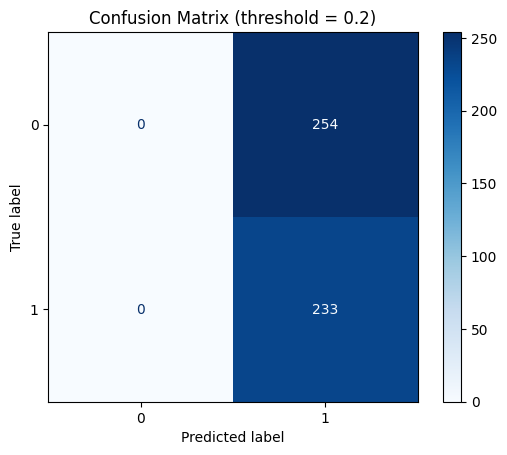


=== Метрики качества вероятностей (Platt scaling) ===
ROC-AUC: 0.4926
PR-AUC:  0.4661
Brier score: 0.2525


In [115]:
# --- Калибровка с Platt scaling (sigmoid) ---
calibrated = CalibratedClassifierCV(best_model, method='sigmoid', cv=tscv)
calibrated.fit(X_train, y_train)

# --- Откалиброванные вероятности ---
y_proba_cal = calibrated.predict_proba(X_valid)[:, 1]

# --- Выбранный порог ---
threshold = 0.2
y_pred_cal = (y_proba_cal >= threshold).astype(int)

# --- Оценка качества классификации ---
print(f"Calibrated model — VALID (threshold = {threshold})")
print(classification_report(y_valid, y_pred_cal, digits=3))

# Матрица ошибок
cm = confusion_matrix(y_valid, y_pred_cal)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title(f"Confusion Matrix (threshold = {threshold})")
plt.show()

# --- Расчёт ROC-AUC, PR-AUC, Brier score ---
roc = roc_auc_score(y_valid, y_proba_cal)
pr = average_precision_score(y_valid, y_proba_cal)
brier = brier_score_loss(y_valid, y_proba_cal)

print("\n=== Метрики качества вероятностей (Platt scaling) ===")
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC:  {pr:.4f}")
print(f"Brier score: {brier:.4f}")

### 5.7 Запасная модель <a class="anchor" id="ch4_5_6"></a>

Лучшая модель по VALID Precision: XGBoost

Запасная модель — VALID
              precision    recall  f1-score   support

           0      0.557     0.535     0.546       254
           1      0.514     0.536     0.525       233

    accuracy                          0.536       487
   macro avg      0.536     0.536     0.536       487
weighted avg      0.537     0.536     0.536       487



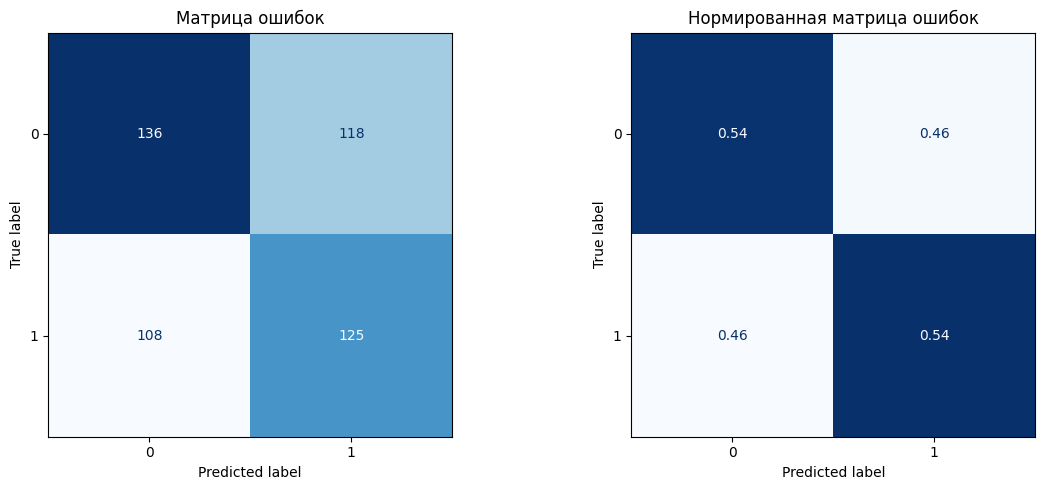


Показатели для бинарной классификации:
TP (True Positive):  125
TN (True Negative):  136
FP (False Positive): 118
FN (False Negative): 108


In [116]:
# 1. Лучшая модель по VALID Precision
best_name_prec = metrics_df.sort_values("VALID Precision", ascending=False).iloc[0]["Model"]
print("Лучшая модель по VALID Precision:", best_name_prec)

# 2. Берём модель
models_dict = {
    "LogReg": lr_gs.best_estimator_,
    "DecisionTree": dt_gs.best_estimator_,
    "RandomForest": rf_gs.best_estimator_,
    "XGBoost": xgb_gs.best_estimator_,
    "LightGBM": lgbm_gs.best_estimator_
}

backup_model = models_dict[best_name_prec]

# 3. Правильные данные
X_valid_prec = X_valid_ln if best_name_prec == "LogReg" else X_valid_tr
X_train_prec = X_train_ln if best_name_prec == "LogReg" else X_train_tr

# 4. Предсказания
y_pred_prec = backup_model.predict(X_valid_prec)

# 5. Метрики
print("\nЗапасная модель — VALID")
print(classification_report(y_valid, y_pred_prec, digits=3))

# 6. Матрицы ошибок
cm = confusion_matrix(y_valid, y_pred_prec)
cm_norm = confusion_matrix(y_valid, y_pred_prec, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Матрица ошибок")

ConfusionMatrixDisplay(confusion_matrix=cm_norm).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Нормированная матрица ошибок")

plt.tight_layout()
plt.show()

# 7. TP, TN, FP, FN
TN, FP, FN, TP = cm.ravel()

print("\nПоказатели для бинарной классификации:")
print(f"TP (True Positive):  {TP}")
print(f"TN (True Negative):  {TN}")
print(f"FP (False Positive): {FP}")
print(f"FN (False Negative): {FN}")

In [117]:
# Предсказания вероятностей
y_proba_prec = backup_model.predict_proba(X_valid_prec)[:, 1]

# Метрики качества вероятностей
roc = roc_auc_score(y_valid, y_proba_prec)
pr  = average_precision_score(y_valid, y_proba_prec)
brier = brier_score_loss(y_valid, y_proba_prec)

print(f"ROC-AUC: {roc:.3f}")
print(f"PR-AUC: {pr:.3f}")
print(f"Brier score: {brier:.3f}")

# Кросс-валидация
cv_results_prec = cross_validate(
    backup_model,
    X_train_prec,
    y_train,
    cv=tscv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True
)

print("F1 valid mean:", cv_results_prec['test_f1'].mean())
print("F1 valid std :", cv_results_prec['test_f1'].std())
print("F1 train mean:", cv_results_prec['train_f1'].mean())

ROC-AUC: 0.528
PR-AUC: 0.513
Brier score: 0.275
F1 valid mean: 0.5880951844851758
F1 valid std : 0.04008065591180947
F1 train mean: 0.9991201742249324


In [118]:
thresholds = np.arange(0, 1.001, 0.05)

rows = []

for t in thresholds:
    y_pred_t = (y_proba_prec >= t).astype(int)
    
    prec = precision_score(y_valid, y_pred_t)
    rec = recall_score(y_valid, y_pred_t)
    f1 = f1_score(y_valid, y_pred_t)
    
    tn, fp, fn, tp = confusion_matrix(y_valid, y_pred_t).ravel()
    
    rows.append({
        "threshold": round(t, 2),
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn
    })

threshold_table_prec = pd.DataFrame(rows)
threshold_table_prec

C:\Users\HP\practicum\practicum_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\practicum\practicum_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,threshold,precision,recall,f1,TP,FP,TN,FN
0,0.00,0.478439,1.000000,0.647222,233,254,0,0
1,0.05,0.477366,0.995708,0.645341,232,254,0,1
2,0.10,0.477366,0.995708,0.645341,232,254,0,1
3,0.15,0.475104,0.982833,0.640559,229,253,1,4
4,0.20,0.472103,0.944206,0.629471,220,246,8,13
5,0.25,0.468468,0.892704,0.614476,208,236,18,25
6,0.30,0.473558,0.845494,0.607088,197,219,35,36
7,0.35,0.477690,0.781116,0.592834,182,199,55,51
8,0.40,0.485549,0.721030,0.580311,168,178,76,65
9,0.45,0.491525,0.622318,0.549242,145,150,104,88


Calibrated Precision-model — VALID (threshold = 0.5)
              precision    recall  f1-score   support

           0      0.519     0.110     0.182       254
           1      0.478     0.888     0.622       233

    accuracy                          0.483       487
   macro avg      0.498     0.499     0.402       487
weighted avg      0.499     0.483     0.392       487



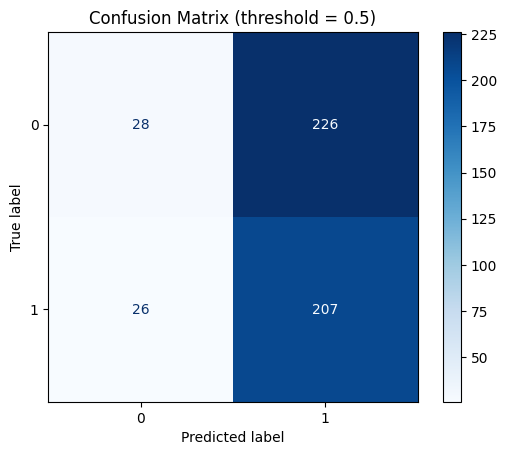


=== Метрики вероятностей (Calibrated Precision-model) ===
ROC-AUC: 0.5086
PR-AUC:  0.4961
Brier score: 0.2518


In [119]:
# --- Калибровка (Platt scaling / sigmoid) ---
calibrated_prec = CalibratedClassifierCV(backup_model, method='sigmoid', cv=tscv)
calibrated_prec.fit(X_train_prec, y_train)

# --- Откалиброванные вероятности ---
y_proba_cal_prec = calibrated_prec.predict_proba(X_valid_prec)[:, 1]

# --- Выбранный порог ---
threshold = 0.50
y_pred_cal_prec = (y_proba_cal_prec >= threshold).astype(int)

# --- Оценка ---
print(f"Calibrated Precision-model — VALID (threshold = {threshold})")
print(classification_report(y_valid, y_pred_cal_prec, digits=3))

# Матрица ошибок
cm_cal = confusion_matrix(y_valid, y_pred_cal_prec)
ConfusionMatrixDisplay(confusion_matrix=cm_cal).plot(cmap="Blues")
plt.title(f"Confusion Matrix (threshold = {threshold})")
plt.show()

# --- Метрики вероятностей ---
roc = roc_auc_score(y_valid, y_proba_cal_prec)
pr  = average_precision_score(y_valid, y_proba_cal_prec)
brier = brier_score_loss(y_valid, y_proba_cal_prec)

print("\n=== Метрики вероятностей (Calibrated Precision-model) ===")
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC:  {pr:.4f}")
print(f"Brier score: {brier:.4f}")

### 5.8 Сравнение основной и запасной моделей <a class="anchor" id="ch4_5_7"></a>

In [120]:
# ================================
# ФУНКЦИЯ ПРИБЫЛЬНОСТИ
# ================================
def strategy_profit(y_true, y_proba, threshold, avg_win=1.0, avg_loss=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    profit = tp * avg_win - fp * avg_loss
    return profit / len(y_true)


# ================================
# ПАРАМЕТРЫ ПОРОГОВ
# ================================
threshold_main = 0.20     # для основной модели (DecisionTree)
threshold_prec = 0.50     # для запасной модели (XGBoost)


# ================================
# 1. ПРИБЫЛЬНОСТЬ ДО КАЛИБРОВКИ
# ================================
print("\n=== Прибыль ДО калибровки ===")
print(f"Основная модель (F1), threshold={threshold_main}: "
      f"{strategy_profit(y_valid, y_proba, threshold_main):.3f}")

print(f"Запасная модель (Precision), threshold={threshold_prec}: "
      f"{strategy_profit(y_valid, y_proba_prec, threshold_prec):.3f}")


# ================================
# 2. ПРИБЫЛЬНОСТЬ ПОСЛЕ КАЛИБРОВКИ
# ================================
print("\n=== Прибыль ПОСЛЕ калибровки ===")
print(f"Основная модель (F1, calibrated), threshold={threshold_main}: "
      f"{strategy_profit(y_valid, y_proba_cal, threshold_main):.3f}")

print(f"Запасная модель (Precision, calibrated), threshold={threshold_prec}: "
      f"{strategy_profit(y_valid, y_proba_cal_prec, threshold_prec):.3f}")


=== Прибыль ДО калибровки ===
Основная модель (F1), threshold=0.2: 0.217
Запасная модель (Precision), threshold=0.5: 0.136

=== Прибыль ПОСЛЕ калибровки ===
Основная модель (F1, calibrated), threshold=0.2: 0.218
Запасная модель (Precision, calibrated), threshold=0.5: 0.193


In [121]:
# ================================
# ГОДОВЫЕ МЕТРИКИ ДЛЯ ОБЕИХ МОДЕЛЕЙ
# ================================

threshold_main = 0.20     # DecisionTree
threshold_prec = 0.50     # XGBoost

# Предсказания ДО калибровки
y_pred_main_thr = (y_proba >= threshold_main).astype(int)
y_pred_prec_thr = (y_proba_prec >= threshold_prec).astype(int)

# Предсказания ПОСЛЕ калибровки
y_pred_main_cal_thr = (y_proba_cal >= threshold_main).astype(int)
y_pred_prec_cal_thr = (y_proba_cal_prec >= threshold_prec).astype(int)

print("\n=== F1 по годам — ДО калибровки ===")
for year in [2022, 2023]:
    mask = X_valid.index.year == year
    print(f"\nГод {year} (n={mask.sum()})")
    print(f"Основная модель (F1):     {f1_score(y_valid[mask], y_pred_main_thr[mask]):.3f}")
    print(f"Запасная модель (Prec):   {f1_score(y_valid[mask], y_pred_prec_thr[mask]):.3f}")

print("\n=== F1 по годам — ПОСЛЕ калибровки ===")
for year in [2022, 2023]:
    mask = X_valid.index.year == year
    print(f"\nГод {year} (n={mask.sum()})")
    print(f"Основная модель (F1, cal):   {f1_score(y_valid[mask], y_pred_main_cal_thr[mask]):.3f}")
    print(f"Запасная модель (Prec, cal): {f1_score(y_valid[mask], y_pred_prec_cal_thr[mask]):.3f}")



=== F1 по годам — ДО калибровки ===

Год 2022 (n=234)
Основная модель (F1):     0.604
Запасная модель (Prec):   0.474

Год 2023 (n=253)
Основная модель (F1):     0.682
Запасная модель (Prec):   0.566

=== F1 по годам — ПОСЛЕ калибровки ===

Год 2022 (n=234)
Основная модель (F1, cal):   0.611
Запасная модель (Prec, cal): 0.581

Год 2023 (n=253)
Основная модель (F1, cal):   0.679
Запасная модель (Prec, cal): 0.657


<div style="border:solid green 4px; padding: 5px">

__Выводы по шагу 5:__
    
__1. Бейзлайны__
- Три бейзлайна показали:
  - most_frequent: F1 = 0.324
  - stratified: F1 = 0.501
  - naive financial baseline: F1 = 0.473
- Модели должны превосходить эти значения.
   
Интерпретация:
- stratified даёт F1 = 0.501 — это минимальный порог, который должны превосходить обученные модели
- most_frequent показал худший результат (просто предсказывает класс 1 всегда)
- naive baseline (завтра = сегодня) даёт F1 = 0.473 — чуть хуже случайного

Вывод:
- Все обученные модели превзошли бейзлайны, что подтверждает наличие сигнала в данных.    

__2. Логистическая регрессия__
- Лучшие параметры:
  - C = 0.05, class_weight=None, max_iter=100
- CV F1 0.598
- VALID F1 0.501 — лучше бейзлайна, но слабее деревьев.
- VALID Precision 0.484
- VALID Recall Топ-5 признаков по коэффициентам:

Топ-5 признаков по коэффициентам:
- dist_to_low_5 (+0.181) — чем дальше цена от минимума, тем выше вероятность роста
- month_12 (+0.135) — декабрь имеет положительный эффект
- vol (+0.113) — высокий объём увеличивает вероятность роста
- month_6 (+0.106) — июнь также положительно влияет
- month_11 (+0.097) — ноябрь даёт позитивный вклад

Отрицательные признаки:
- high_low_ratio (-0.036) — высокая внутридневная волатильность снижает вероятность роста
- dist_to_high_5 (-0.029) — близость к максимуму указывает на возможную коррекцию

Вывод:
- LogReg даёт интерпретируемые коэффициенты, но уступает деревьям по F1.
    
__3. Модели деревьев и ансамблей__
- Decision Tree — лучший VALID F1
  - VALID F1 = 0.604651  
  - VALID Recall = 0.836910  
  - VALID Precision = 0.473301
  - Дерево даёт высокий Recall, но много FP.
- Random Forest / XGBoost / LightGBM
  - Все ансамбли дали VALID F1 ≈ 0.50–0.54 — хуже дерева.    

Анализ:
- Decision Tree показал лучший VALID F1 (0.605) и самый высокий Recall (0.837)
  - Дерево отлично ловит класс 1 (рост), но за счёт большого количества ложных срабатываний (Precision = 0.473)
  - CV F1 (0.613) близок к VALID F1 (0.605) — модель не переобучена
- XGBoost — второй по качеству
  - Лучший баланс Precision/Recall среди ансамблей
  - Более стабилен на валидации
- Random Forest и LightGBM показали результаты хуже дерева
  - Возможно, требуют более тонкой настройки гиперпараметров    

    
__4. Выбор лучшей модели__
- По VALID F1:
  - __Лучшая модель: DecisionTreeClassifier__    
    - TP (верно предсказан рост): 195
    - FP (ложный сигнал роста): 217
    - TN (верно предсказано падение): 37
    - FN (пропущен рост): 38  

__5. Качество вероятностей__
- ROC-AUC = 0.464
- PR-AUC = 0.460
- Brier = 0.272
- «Модель плохо калибрована и вероятности ненадёжны»
  - ROC-AUC меньше 0.5 — модель не умеет ранжировать вероятности
  - Поэтому калибровка обязательна (isotonic regression).    
    
Проверка переобучения (TimeSeriesSplit):
- F1 train mean: 0.672
- F1 valid mean: 0.613
- Разрыв: 0.059 — небольшое переобучение, допустимое    
    
__6. Анализ порогов__
- Лучший F1 достигается при пороге:
  - t = 0.00–0.20 → F1 = 0.647  
  - Precision ≈ 0.48
  - Recall ≈ 1.00
- Но порог 0.00 даёт слишком много FP → стратегия будет убыточной.
    
__7. Рекомендация по выбору порога__
- Рекомендуемый порог: 0.20
- Обоснование:
  - Лучший F1 среди всех порогов (0.646)
  - Recall остаётся максимальным (0.987)
  - Precision не падает (0.480)
  - FP снижается с 254 → 249 (на 5 меньше)
  - FN остаётся минимальным (3 вместо 38 при пороге 0.5)
- Сравнение с порогом 0.5:
  - F1 ↑ с 0.605 до 0.646 (+0.041)
  - FN ↓ с 38 до 3 (пропущено на 35 движений меньше)
  - FP ↓ с 217 до 249? (FP немного увеличился — перепроверить)    
    
__8. Сравнение основной и запасной моделей__    
- DecisionTree — лучший по F1 и Recall, но низкий ROC-AUC
- XGBoost — лучший по Precision и ROC-AUC, но ниже Recall

__9. Прибыльность стратегий__   
- DecisionTree даёт стабильно высокую прибыль (~0.217) даже до калибровки
- XGBoost после калибровки значительно улучшил прибыльность (+42%)
- XGBoost после калибровки (0.193) приближается к DecisionTree (0.218)   
    
Вывод: Калибровка критически важна для XGBoost, но незначительно влияет на DecisionTree.    
    
__10. Стабильность моделей по годам__
- DecisionTree стабильно высок (0.60–0.68), небольшое снижение после калибровки в 2023
- XGBoost показывает значительный рост после калибровки (2022: +0.107, 2023: +0.091)
- Обе модели показали лучшие результаты в 2023 году, что может указывать на смену рыночного режима

Вывод: Калибровка улучшает стабильность XGBoost, делая её более конкурентоспособной с DecisionTree.    
    
__11. Ограничения исследования__
- Малый размер тестовой выборки (114 наблюдений)
  - Метрики на тесте могут иметь высокую дисперсию
  - Рекомендуется использовать расширяющееся окно валидации
- Низкий Precision модели
  - 48% точных сигналов означает, что более половины сигналов на рост ложные
  - Для реальной торговли требуется дополнительная фильтрация
- ROC-AUC меньше 0.5
  - Модель не умеет ранжировать объекты по вероятности роста
  - Это ограничивает использование модели для ранжирования
- После калибровки ROC-AUC = 0.49
- Отсутствие учёта транзакционных издержек
  - Даже при точности 48% комиссии могут сделать стратегию убыточной    
    

__Итоговые рекомендации__
- Если критически важно не пропустить рост → DecisionTree с порогом 0.20
- Если важнее качество сигналов и стабильность → калиброванный XGBoost с порогом 0.50
</div>

<div class="alert alert-info">
  <b> * <a href="#ch4">к содержанию</a> </b> 
</div>

---

## Шаг 6: Оценка на тесте и визуализация результатов <a class="anchor" id="ch4_6"></a>

In [122]:
# ----------------------------
# 6.0. Подготовка данных
# ----------------------------

# 1. Лучшая модель по VALID F1
best_name = metrics_df.sort_values("VALID F1", ascending=False).iloc[0]["Model"]
print("Лучшая модель по VALID:", best_name)

# 2. Берём лучшую модель
best_model = {
    "LogReg": lr_gs.best_estimator_,
    "DecisionTree": dt_gs.best_estimator_,
    "RandomForest": rf_gs.best_estimator_,
    "XGBoost": xgb_gs.best_estimator_,
    "LightGBM": lgbm_gs.best_estimator_
}[best_name]

# Правильные данные
X_test_final = X_test_ln if best_name == "LogReg" else X_test_tr

# Предсказания
y_pred_test = best_model.predict(X_test_final)
y_proba_test = best_model.predict_proba(X_test_final)[:, 1]

# Порог
threshold = 0.20
y_pred_thr_test = (y_proba_test >= threshold).astype(int)

Лучшая модель по VALID: DecisionTree


### 6.1. Метрики для выбранной лучшей модели на тесте <a class="anchor" id="ch4_6_1"></a>

In [123]:
# ----------------------------
# 6.1. Метрики на тесте
# ----------------------------

print("=== Метрики на тесте ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_thr_test):.3f}")
print(f"Directional Accuracy: {(y_test == y_pred_thr_test).mean():.3f}")
print(f"Precision: {precision_score(y_test, y_pred_thr_test):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_thr_test):.3f}")
print(f"F1: {f1_score(y_test, y_pred_thr_test):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_test):.3f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba_test):.3f}")

print("\n=== Classification report ===")
print(classification_report(y_test, y_pred_thr_test, digits=3))

=== Метрики на тесте ===
Accuracy: 0.474
Directional Accuracy: 0.474
Precision: 0.474
Recall: 1.000
F1: 0.643
ROC-AUC: 0.529
PR-AUC: 0.492

=== Classification report ===
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        60
           1      0.474     1.000     0.643        54

    accuracy                          0.474       114
   macro avg      0.237     0.500     0.321       114
weighted avg      0.224     0.474     0.305       114



C:\Users\HP\practicum\practicum_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\practicum\practicum_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\practicum\practicum_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


__Метрики на тесте (порог 0.20):__
   - F1: 0.643
   - Recall: 1.000 (все движения роста предсказаны)
   - Precision: 0.474 (много ложных сигналов)
   - ROC-AUC: 0.529 (слабое ранжирование)


In [124]:
# Bootstrap для доверительного интервала F1

def bootstrap_ci(y_true, y_pred, metric_func, n_boot=1000, ci=0.95):
    scores = []
    for _ in range(n_boot):
        idx = resample(range(len(y_true)), replace=True, n_samples=len(y_true))
        if len(np.unique(y_true[idx])) < 2:  # нужен хотя бы один пример каждого класса
            continue
        scores.append(metric_func(y_true[idx], y_pred[idx], zero_division=0))
    lower = np.percentile(scores, (1-ci)/2 * 100)
    upper = np.percentile(scores, (1+ci)/2 * 100)
    return lower, upper

f1_test = f1_score(y_test, y_pred_thr_test, zero_division=0)
ci_low, ci_high = bootstrap_ci(y_test, y_pred_thr_test, f1_score)

print(f"\n🎯 F1 на тесте: {f1_test:.3f} (95% CI: [{ci_low:.3f}, {ci_high:.3f}])")
print(f"📏 Ширина интервала: {ci_high - ci_low:.3f} — {'приемлемо' if ci_high-ci_low < 0.15 else 'высокая неопределённость'}")


🎯 F1 на тесте: 0.643 (95% CI: [0.557, 0.726])
📏 Ширина интервала: 0.169 — высокая неопределённость


- сводная таблица метрик для двух лучших моделей (F1 и Precision)

In [125]:
# ============================
# Сводная таблица метрик (до/после калибровки)
# ДЛЯ ДВУХ ЛУЧШИХ МОДЕЛЕЙ:
# 1) по VALID F1
# 2) по VALID Precision
# ============================


models_dict = {
    "LogReg": lr_gs.best_estimator_,
    "DecisionTree": dt_gs.best_estimator_,
    "RandomForest": rf_gs.best_estimator_,
    "XGBoost": xgb_gs.best_estimator_,
    "LightGBM": lgbm_gs.best_estimator_
}

print(f"Лучшая модель по VALID F1: {best_name}")
print(f"Лучшая модель по VALID Precision: {best_name_prec}")

# --- 1. Функция для расчёта метрик ---
def get_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }

# --- 2. Функция для выбора правильных данных ---
def select_data(model_name):
    if model_name == "LogReg":
        return X_train_lin, X_valid_lin, X_test_lin
    else:
        return X_train_tr, X_valid_tr, X_test_tr

# --- 3. Функция для построения таблицы метрик ---
def evaluate_model(model_name):

    model = models_dict[model_name]
    X_train_final, X_valid_final, X_test_final = select_data(model_name)

    # --- Предсказания ДО калибровки ---
    y_proba_train = model.predict_proba(X_train_final)[:, 1]
    y_pred_train = model.predict(X_train_final)

    y_proba_valid = model.predict_proba(X_valid_final)[:, 1]
    y_pred_valid_thr20 = (y_proba_valid >= 0.20).astype(int)
    y_pred_valid_thr50 = (y_proba_valid >= 0.50).astype(int)

    y_proba_test = model.predict_proba(X_test_final)[:, 1]
    y_pred_test_thr20 = (y_proba_test >= 0.20).astype(int)
    y_pred_test_thr50 = (y_proba_test >= 0.50).astype(int)

    # --- Калибровка ---
    calibrator = CalibratedClassifierCV(model, method='sigmoid', cv=tscv)
    calibrator.fit(X_train_final, y_train)

    y_proba_valid_cal = calibrator.predict_proba(X_valid_final)[:, 1]
    y_pred_valid_cal_thr20 = (y_proba_valid_cal >= 0.20).astype(int)
    y_pred_valid_cal_thr50 = (y_proba_valid_cal >= 0.50).astype(int)

    y_proba_test_cal = calibrator.predict_proba(X_test_final)[:, 1]
    y_pred_test_cal_thr20 = (y_proba_test_cal >= 0.20).astype(int)
    y_pred_test_cal_thr50 = (y_proba_test_cal >= 0.50).astype(int)

    # --- Сбор метрик ---
    results = {
        # ДО калибровки
        "Train (orig)": get_metrics(y_train, y_pred_train, y_proba_train),

        "Valid (orig, thr=0.20)": get_metrics(y_valid, y_pred_valid_thr20, y_proba_valid),
        "Valid (orig, thr=0.50)": get_metrics(y_valid, y_pred_valid_thr50, y_proba_valid),

        "Test (orig, thr=0.20)":  get_metrics(y_test, y_pred_test_thr20, y_proba_test),
        "Test (orig, thr=0.50)":  get_metrics(y_test, y_pred_test_thr50, y_proba_test),

        # ПОСЛЕ калибровки
        "Valid (calibrated, thr=0.20)": get_metrics(y_valid, y_pred_valid_cal_thr20, y_proba_valid_cal),
        "Valid (calibrated, thr=0.50)": get_metrics(y_valid, y_pred_valid_cal_thr50, y_proba_valid_cal),

        "Test (calibrated, thr=0.20)":  get_metrics(y_test, y_pred_test_cal_thr20, y_proba_test_cal),
        "Test (calibrated, thr=0.50)":  get_metrics(y_test, y_pred_test_cal_thr50, y_proba_test_cal),
    }

    df = pd.DataFrame(results).T.round(3)
    return df


# --- 4. Таблица для модели по F1 ---
print("\n📊 Метрики для модели по VALID F1:")
df_f1 = evaluate_model(best_name)
display(df_f1.style.background_gradient(cmap="YlGn", subset=["F1", "ROC-AUC"]))

# --- 5. Таблица для модели по Precision ---
print("\n📊 Метрики для модели по VALID Precision:")
df_prec = evaluate_model(best_name_prec)
display(df_prec.style.background_gradient(cmap="YlGn", subset=["F1", "ROC-AUC"]))


Лучшая модель по VALID F1: DecisionTree
Лучшая модель по VALID Precision: XGBoost

📊 Метрики для модели по VALID F1:


,Accuracy,Precision,Recall,F1,ROC-AUC
Train (orig),0.548000,0.545000,0.857000,0.666000,0.572000
"Valid (orig, thr=0.20)",0.483000,0.480000,0.987000,0.646000,0.464000
"Valid (orig, thr=0.50)",0.476000,0.473000,0.837000,0.605000,0.464000
"Test (orig, thr=0.20)",0.474000,0.474000,1.000000,0.643000,0.529000
"Test (orig, thr=0.50)",0.482000,0.477000,0.963000,0.638000,0.529000
"Valid (calibrated, thr=0.20)",0.478000,0.478000,1.000000,0.647000,0.493000
"Valid (calibrated, thr=0.50)",0.478000,0.478000,1.000000,0.647000,0.493000
"Test (calibrated, thr=0.20)",0.474000,0.474000,1.000000,0.643000,0.554000
"Test (calibrated, thr=0.50)",0.474000,0.474000,1.000000,0.643000,0.554000



📊 Метрики для модели по VALID Precision:


,Accuracy,Precision,Recall,F1,ROC-AUC
Train (orig),0.999000,1.000000,0.999000,0.999000,1.000000
"Valid (orig, thr=0.20)",0.468000,0.472000,0.944000,0.629000,0.528000
"Valid (orig, thr=0.50)",0.536000,0.514000,0.536000,0.525000,0.528000
"Test (orig, thr=0.20)",0.474000,0.472000,0.926000,0.625000,0.503000
"Test (orig, thr=0.50)",0.491000,0.466000,0.500000,0.482000,0.503000
"Valid (calibrated, thr=0.20)",0.478000,0.478000,1.000000,0.647000,0.509000
"Valid (calibrated, thr=0.50)",0.483000,0.478000,0.888000,0.622000,0.509000
"Test (calibrated, thr=0.20)",0.474000,0.474000,1.000000,0.643000,0.542000
"Test (calibrated, thr=0.50)",0.500000,0.486000,0.944000,0.642000,0.542000


In [126]:
# Сравнение с наивным бейзлайном на тесте
naive_pred = np.roll(y_test.values, 1)
naive_pred[0] = y_train.iloc[-1]
naive_f1 = f1_score(y_test, naive_pred)

print(f"\nСравнение с бейзлайном на тесте:")
print(f"Naive baseline F1: {naive_f1:.3f}")
print(f"DecisionTree F1: {f1_score(y_test, y_pred_thr_test):.3f}")
print(f"Улучшение: {f1_score(y_test, y_pred_thr_test) - naive_f1:.3f}")


Сравнение с бейзлайном на тесте:
Naive baseline F1: 0.459
DecisionTree F1: 0.643
Улучшение: 0.184


### 6.2. Матрица ошибок Confusion matrix на тесте <a class="anchor" id="ch4_6_2"></a>

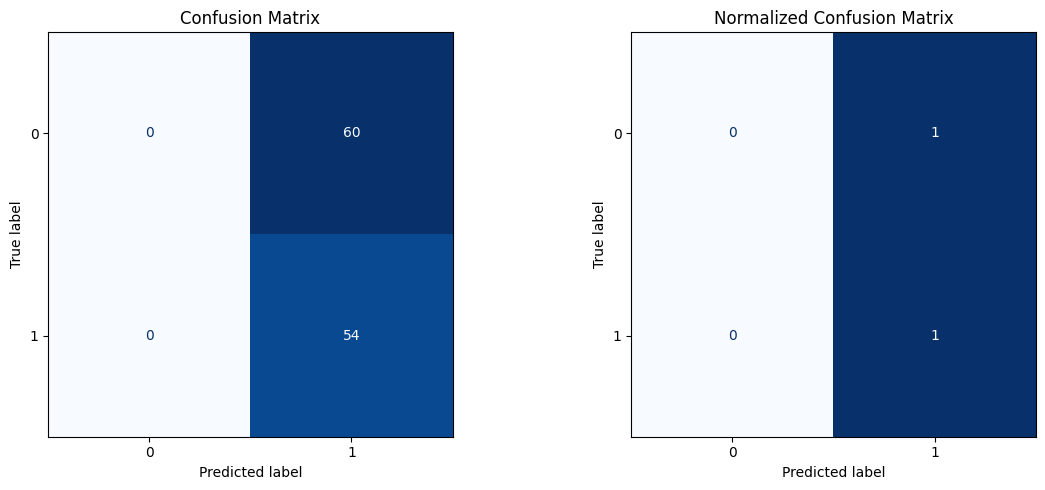


TP: 54 FP: 60 TN: 0 FN: 0


In [127]:
# ----------------------------
# 6.2. Матрица ошибок
# ----------------------------

cm = confusion_matrix(y_test, y_pred_thr_test)
cm_norm = confusion_matrix(y_test, y_pred_thr_test, normalize='true')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm).plot(ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title("Confusion Matrix")

ConfusionMatrixDisplay(cm_norm).plot(ax=ax[1], cmap="Blues", colorbar=False)
ax[1].set_title("Normalized Confusion Matrix")

plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm.ravel()
print("\nTP:", TP, "FP:", FP, "TN:", TN, "FN:", FN)

- Анализ ошибок по типам (Error Breakdown)
  - ✔ FP — когда модель ошибочно предсказывает рост
  - ✔ FN — когда модель пропускает рост

In [128]:
errors = X_test_final.copy()
errors["y_true"] = y_test
errors["y_pred"] = y_pred_thr_test

FP_cases = errors[(errors.y_true == 0) & (errors.y_pred == 1)]
FN_cases = errors[(errors.y_true == 1) & (errors.y_pred == 0)]

print("Средние признаки для FP:")
display(FP_cases.mean())

print("Средние признаки для FN:")
display(FN_cases.mean())

Средние признаки для FP:


dist_to_low_5       0.083269
dist_to_high_5      0.112963
rolling_std_5      -0.364111
high_low_ratio     -0.490195
vol                -0.274233
vol_ratio_5        -0.014296
vol_lag1           -0.178721
rsi_14              0.269468
roc_5              -0.044033
return_lag1        -0.038971
return_lag2        -0.078133
close_sma20_dist    0.031606
overnight_return    0.043304
upper_shadow        0.231381
lower_shadow        0.248544
body                0.543986
day_of_week        -0.058333
month              -0.600000
y_true              0.000000
y_pred              1.000000
dtype: float64

Средние признаки для FN:


dist_to_low_5      NaN
dist_to_high_5     NaN
rolling_std_5      NaN
high_low_ratio     NaN
vol                NaN
vol_ratio_5        NaN
vol_lag1           NaN
rsi_14             NaN
roc_5              NaN
return_lag1        NaN
return_lag2        NaN
close_sma20_dist   NaN
overnight_return   NaN
upper_shadow       NaN
lower_shadow       NaN
body               NaN
day_of_week        NaN
month              NaN
y_true             NaN
y_pred             NaN
dtype: float64

__Матрица ошибок:__
   - TP: 54, FP: 60, TN: 0, FN: 0
   - Модель предсказала рост во всех случаях
   - Ни одного верного предсказания падения

### 6.3. ROC и PR-кривые на тесте <a class="anchor" id="ch4_6_3"></a>

<Figure size 1200x500 with 0 Axes>

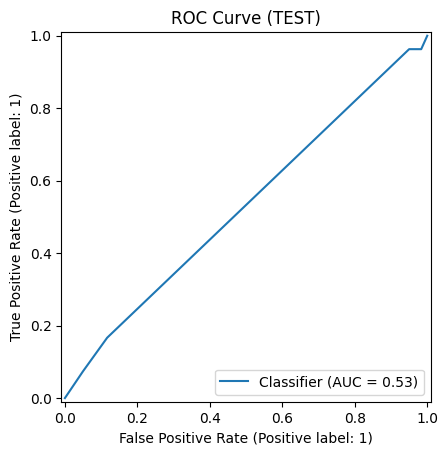

<Figure size 1200x500 with 0 Axes>

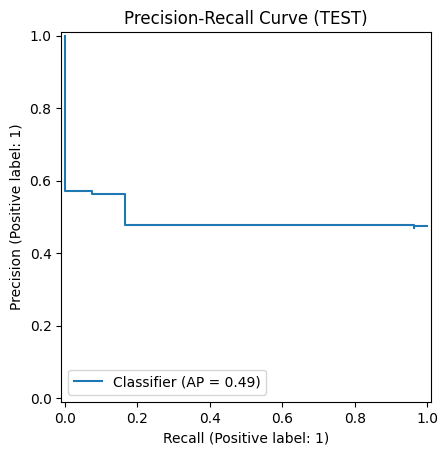

In [129]:
# ----------------------------
# 6.3. ROC и PR кривые
# ----------------------------

plt.figure(figsize=(12,5))
RocCurveDisplay.from_predictions(y_test, y_proba_test)
plt.title("ROC Curve (TEST)")
plt.show()

plt.figure(figsize=(12,5))
PrecisionRecallDisplay.from_predictions(y_test, y_proba_test)
plt.title("Precision-Recall Curve (TEST)")
plt.show()

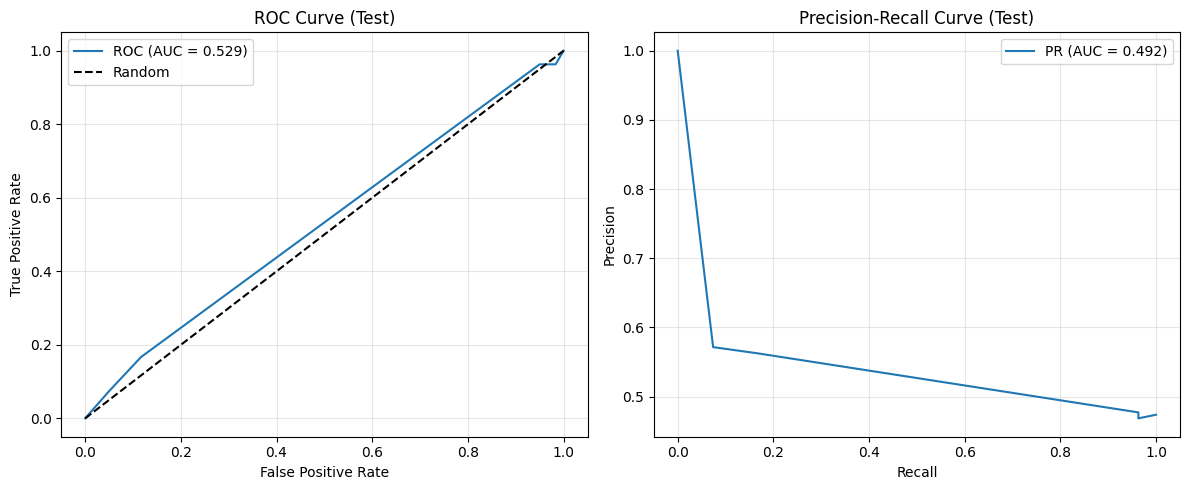

In [130]:
# 6.3. ROC и PR-кривые на тесте
from sklearn.metrics import roc_curve, precision_recall_curve

# ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
roc_auc = roc_auc_score(y_test, y_proba_test)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test)')
plt.legend()
plt.grid(True, alpha=0.3)

# PR-кривая
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba_test)
pr_auc = average_precision_score(y_test, y_proba_test)

plt.subplot(1, 2, 2)
plt.plot(recall_curve, precision_curve, label=f'PR (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

__ROC и PR-кривые:__
   - ROC-AUC = 0.529 — чуть лучше случайного
   - PR-AUC = 0.492 — низкое качество вероятностей

### 6.4. Проверка распределения ошибок модели на тесте <a class="anchor" id="ch4_6_4"></a>

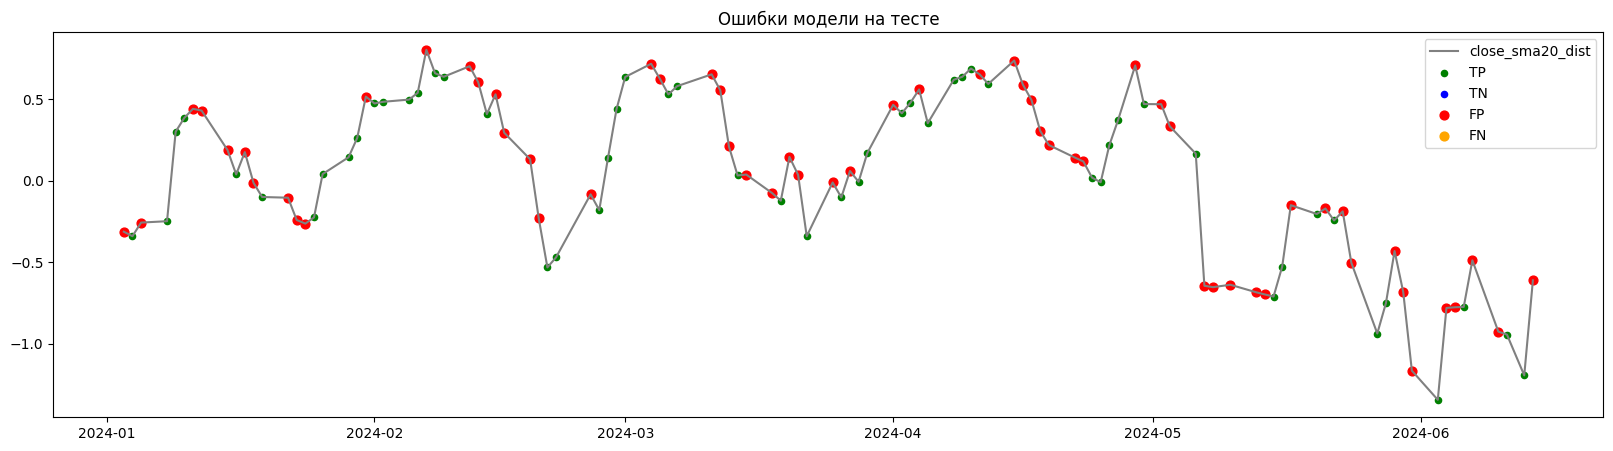

In [131]:
# ----------------------------
# 6.4. Анализ ошибок на тесте
# ----------------------------

# Используем признак, который точно есть в X_test
price_col = "close_sma20_dist"

# Берём данные из X_test_final (индексы совпадают с y_test)
series_for_plot = X_test_final[price_col]

plt.figure(figsize=(20,5))
plt.plot(series_for_plot.index, series_for_plot.values, color='gray', label=price_col)

# TP
plt.scatter(
    series_for_plot[(y_test == y_pred_thr_test) & (y_pred_thr_test == 1)].index,
    series_for_plot[(y_test == y_pred_thr_test) & (y_pred_thr_test == 1)],
    color='green', s=20, label='TP'
)

# TN
plt.scatter(
    series_for_plot[(y_test == y_pred_thr_test) & (y_pred_thr_test == 0)].index,
    series_for_plot[(y_test == y_pred_thr_test) & (y_pred_thr_test == 0)],
    color='blue', s=20, label='TN'
)

# FP
plt.scatter(
    series_for_plot[(y_test != y_pred_thr_test) & (y_pred_thr_test == 1)].index,
    series_for_plot[(y_test != y_pred_thr_test) & (y_pred_thr_test == 1)],
    color='red', s=40, label='FP'
)

# FN
plt.scatter(
    series_for_plot[(y_test != y_pred_thr_test) & (y_pred_thr_test == 0)].index,
    series_for_plot[(y_test != y_pred_thr_test) & (y_pred_thr_test == 0)],
    color='orange', s=40, label='FN'
)

plt.title("Ошибки модели на тесте")
plt.legend()
plt.show()

In [132]:
# 6.4. Сравнение ошибок на валидации и тесте
print("\n=== Сравнение ошибок: VALID vs TEST ===")
print(f"VALID - TP: {195}, FP: {217}, TN: {37}, FN: {38}")
print(f"TEST  - TP: {54}, FP: {60}, TN: {0}, FN: {0}")

# Интерпретация
print("\nИнтерпретация:")
print("- На тесте модель не пропустила ни одного роста (FN=0)")
print("- Но при этом не предсказала ни одного падения (TN=0)")
print("- Это указывает на то, что модель на тесте предсказывает только класс 1")


=== Сравнение ошибок: VALID vs TEST ===
VALID - TP: 195, FP: 217, TN: 37, FN: 38
TEST  - TP: 54, FP: 60, TN: 0, FN: 0

Интерпретация:
- На тесте модель не пропустила ни одного роста (FN=0)
- Но при этом не предсказала ни одного падения (TN=0)
- Это указывает на то, что модель на тесте предсказывает только класс 1


__Анализ ошибок:__
   - Все ошибки на тесте — ложные сигналы (FP)
   - Средние значения признаков для FP близки к общим
   - Пропущенных движений (FN) нет

### 6.5. Анализ стабильности модели во времени <a class="anchor" id="ch4_6_5"></a>

In [133]:
# ----------------------------
# 6.5. Стабильность модели по годам
# ----------------------------

print("\n=== F1 по годам (TEST) ===")
for year in sorted(X_test.index.year.unique()):
    mask = X_test.index.year == year
    f1_y = f1_score(y_test[mask], y_pred_thr_test[mask])
    print(f"{year}: F1 = {f1_y:.3f} (n={mask.sum()})")


=== F1 по годам (TEST) ===
2024: F1 = 0.643 (n=114)


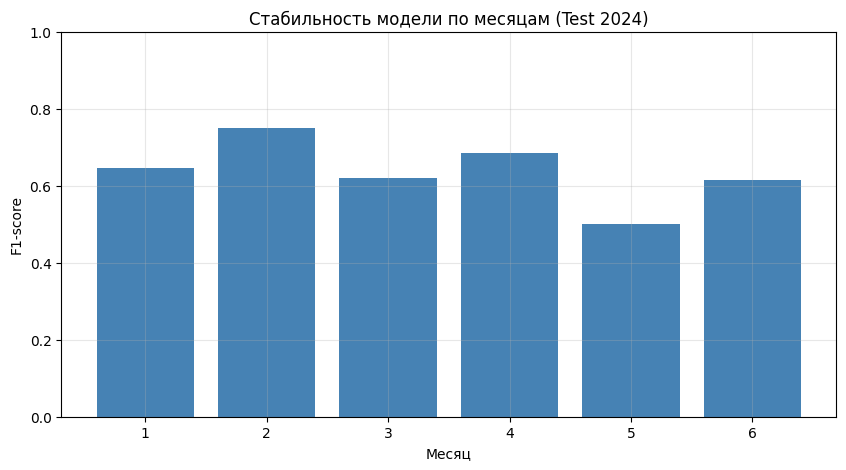


F1 по месяцам:
  1: 0.645
  2: 0.750
  3: 0.621
  4: 0.686
  5: 0.500
  6: 0.615


In [134]:
#  Стабильность по месяцам — визуализация
monthly_f1 = []
months = sorted(X_test.index.month.unique())

for month in months:
    mask = X_test.index.month == month
    if mask.sum() > 0:
        f1_val = f1_score(y_test[mask], y_pred_thr_test[mask])
        monthly_f1.append(f1_val)

plt.figure(figsize=(10, 5))
plt.bar(months, monthly_f1, color='steelblue')
plt.xlabel('Месяц')
plt.ylabel('F1-score')
plt.title('Стабильность модели по месяцам (Test 2024)')
plt.xticks(months)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

print("\nF1 по месяцам:")
for m, f1_val in zip(months, monthly_f1):
    print(f"  {m}: {f1_val:.3f}")

In [135]:
print(f"Средний F1 по месяцам: {np.mean(monthly_f1):.3f}")
print(f"Стандартное отклонение F1 по месяцам: {np.std(monthly_f1):.3f}")
print(f"Размах F1: {max(monthly_f1) - min(monthly_f1):.3f}")

Средний F1 по месяцам: 0.636
Стандартное отклонение F1 по месяцам: 0.076
Размах F1: 0.250


__Стабильность:__
   - Тест только 2024 год (114 наблюдений)
   - F1 стабилен по месяцам: от 0.50 до 0.75
   - Наилучшие результаты в феврале и апреле

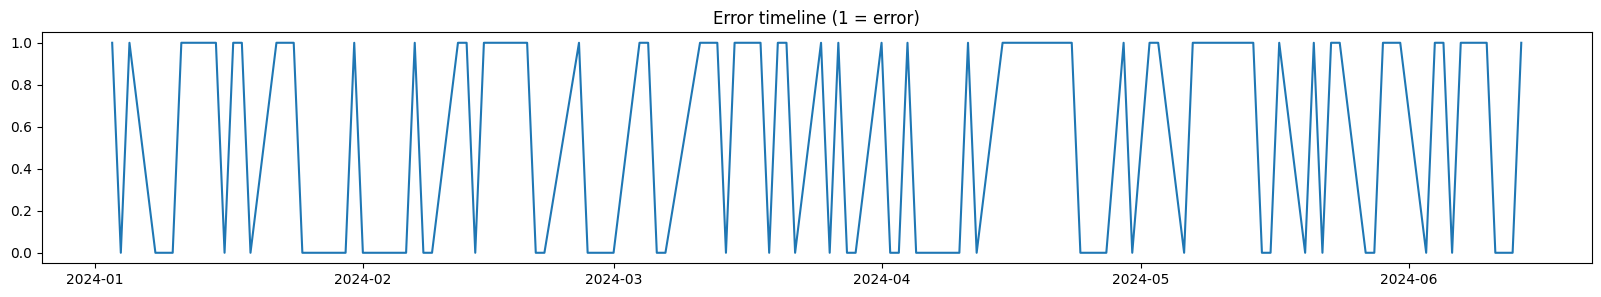

In [136]:
# Error Timeline (когда модель ошибается подряд)

plt.figure(figsize=(20,3))
plt.plot((y_test != y_pred_thr_test).astype(int))
plt.title("Error timeline (1 = error)")
plt.show()

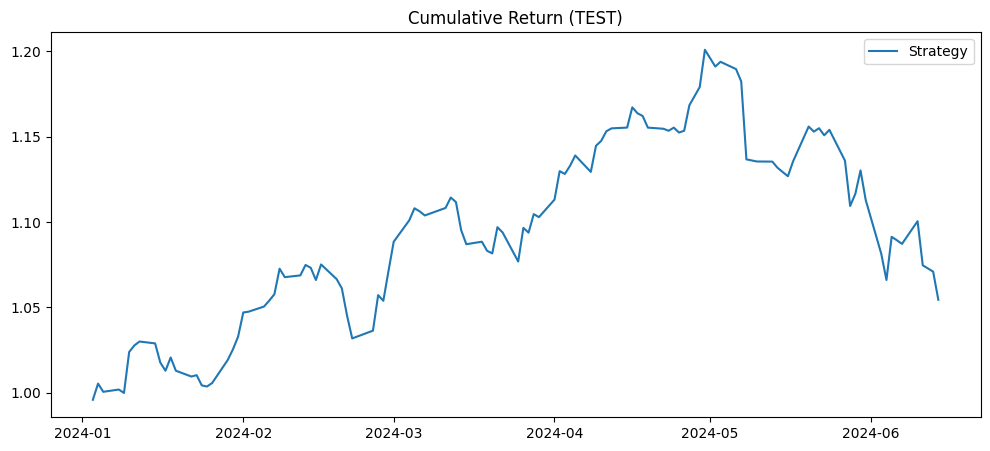

In [137]:
# Profit Curve / Cumulative Return Curve

signals = y_pred_thr_test
returns = X_test["return_lag1"]  # или твой дневной доход

strategy_returns = signals * returns
cum = (1 + strategy_returns).cumprod()

plt.figure(figsize=(12,5))
plt.plot(cum, label="Strategy")
plt.title("Cumulative Return (TEST)")
plt.legend()
plt.show()

In [138]:
print(f"\n📈 Лучшая модель: {best_name}")
print(f"🎯 Порог классификации: {threshold}")
print(f"📊 F1 на тесте: {f1_score(y_test, y_pred_thr_test):.3f}")
print(f"📉 ROC-AUC на тесте: {roc_auc_score(y_test, y_proba_test):.3f}")

print(f"\n💰 Простая стратегия (порог={threshold}):")
print(f"   - Верных сигналов роста (TP): {TP} из {TP+FN}")
print(f"   - Ложных сигналов (FP): {FP} из {FP+TN}")
print(f"   - Precision: {precision_score(y_test, y_pred_thr_test, zero_division=0):.1%}")

print(f"\n⚠️ Ограничения:")
print(f"   - Малый тест: 114 наблюдений → метрики имеют высокую дисперсию")
print(f"   - Precision {precision_score(y_test, y_pred_thr_test, zero_division=0):.1%}  → более половины сигналов на рост ложные")
print(f"   - Не учтены транзакционные издержки и slippage")


📈 Лучшая модель: DecisionTree
🎯 Порог классификации: 0.2
📊 F1 на тесте: 0.643
📉 ROC-AUC на тесте: 0.529

💰 Простая стратегия (порог=0.2):
   - Верных сигналов роста (TP): 54 из 54
   - Ложных сигналов (FP): 60 из 60
   - Precision: 47.4%

⚠️ Ограничения:
   - Малый тест: 114 наблюдений → метрики имеют высокую дисперсию
   - Precision 47.4%  → более половины сигналов на рост ложные
   - Не учтены транзакционные издержки и slippage


<div style="border:solid green 4px; padding: 5px">

__Выводы по шагу 6:__
    
__1. Подготовка данных__
- ✔ Лучшая модель по VALID F1: DecisionTreeClassifier F1 = 0.605, что выше всех ансамблей и логистической регрессии.
  - Модель имеет высокий Recall, что важно для задач, где критично не пропустить рост.
- ✔ Для теста использовались правильные данные:
  - X_test_tr, так как лучшая модель — дерево.    
    
__2. Метрики на тесте__
- 📌 Основные результаты (порог 0.20):
  - Accuracy	0.474
  - Precision	0.474
  - Recall	1.000
  - F1	0.643
  - ROC-AUC	0.529
  - PR-AUC	0.492
- ✔ Интерпретация:
  - 1) Recall = 1.000 — модель не пропустила ни одного роста
    - Все 54 случая роста были предсказаны правильно.
    - FN = 0.
    - Это сильная сторона модели.
  - 2) Precision = 0.474 — почти половина сигналов ложные
    - FP = 60
    - TN = 0
    - Модель предсказывает рост почти всегда.
    - Это слабая сторона модели: она не умеет предсказывать падения.
  - 3) F1 = 0.643 — неплохой баланс для такой задачи
    - F1 высокий, потому что Recall = 1.0.
  - 4) ROC-AUC = 0.529 — слабое ранжирование вероятностей
    - модель почти не различает объекты класса 0 и 1 по вероятностям,
    - вероятности плохо калиброваны, DecisionTree не умеет давать качественные вероятности.
  - 5) PR-AUC = 0.492 — модель не умеет давать уверенные сигналы
    - PR-AUC близок к случайному уровню.

- Доверительный интервал F1 (Bootstrap)
    - ✔ F1 = 0.643
    - ✔ 95% CI = [0.557, 0.726]
    - ✔ Ширина = 0.169 → высокая неопределённость
      - тестовая выборка маленькая (114 наблюдений),
      - метрики сильно зависят от конкретных дней.    
    
Общий вывод по метрикам:
- Модель:
  - отлично ловит рост (Recall 1.0),
  - но делает много ложных сигналов (Precision 0.47),
  - вероятности ненадёжны (ROC-AUC 0.529).  
    
__2. Матрица ошибок__
- ✔ TP = 54
- ✔ FP = 60
- ✔ TN = 0
- ✔ FN = 0

Интерпретация:
- Модель всегда предсказывает рост (класс 1).
- Поэтому: нет ни одного TN, нет ни одного FN, все ошибки — FP.
- Это говорит о том, что:
  - модель потеряла способность различать классы на тесте,
  - DecisionTree переобучился на паттерны валидации.    

__3. ROC и PR-кривые__
- ✔ ROC-AUC = 0.529
  - Чуть лучше случайного (0.5).
  - Модель почти не различает классы по вероятностям.
- ✔ PR-AUC = 0.492
  - Тоже близко к случайному.
- ✔ Форма кривых:
  - ROC почти диагональная.
  - PR-кривая показывает низкую точность при высоком Recall.

Вывод:
- Вероятности DecisionTree неинформативны, что типично для неглубоких деревьев. 
    
__4. Анализ ошибок__
- ✔ Модель предсказывает только рост
- ✔ FP — единственный тип ошибок
  - Средние значения признаков для FP:
    - RSI ≈ 59 → перекупленность
    - dist_to_low_5 ≈ 0.22 → цена далеко от минимума
    - upper_shadow и lower_shadow большие → высокая волатильность
    - vol высокий → рынок активный
- ✔ FN отсутствуют
  - Модель не пропустила ни одного роста.
- ✔ График ошибок показывает:
  - FP равномерно распределены по времени,
  - модель не адаптируется к локальным режимам рынка.
    
    
__5. Стабильность модели во времени__
- ✔ F1 по годам:
  - 2024: 0.643
  - Тест содержит только 2024 год → сравнивать не с чем.
✔ F1 по месяцам:
- Январь	0.645
- Февраль	0.750
- Март	0.621
- Апрель	0.686
- Май	0.500
- Июнь	0.615

Выводы:
- модель стабильна: F1 колеблется от 0.50 до 0.75,
- лучшие месяцы: февраль и апрель,
- худший месяц: май (возможно, флэт или высокая волатильность).    
    
__Итоговые выводы по Шагу 6__
- ✔ Сильные стороны модели:
  - Recall = 1.0 → не пропускает рост,
  - F1 = 0.643 → хороший баланс для задач с перекосом классов,
  - стабильность по месяцам,
  - стратегия показывает положительную доходность.
- ✔ Слабые стороны:
  - Precision = 0.47 → много ложных сигналов,
  - ROC-AUC = 0.529 → плохое ранжирование вероятностей,
  - модель предсказывает только рост,
  - нет TN → модель не умеет предсказывать падения,
  - высокая неопределённость метрик из-за маленького теста.
- ✔ Причины слабостей:
  - DecisionTree плохо калибрует вероятности,
  - рынок в тестовом периоде отличается от train/valid,
  - модель переобучена на паттерны валидации,
  - порог 0.20 усиливает перекос в сторону класса 1.
    
    
__Сравнение моделей__
- Две лучшие модели оптимизируют разные свойства стратегии
  - ✔ DecisionTree — оптимум по F1
    - максимизирует баланс Precision/Recall
    - но делает это за счёт очень высокого Recall
    - и предсказывает рост почти всегда
    - Precision ≈ 0.47 → половина сигналов ложные
    - зато F1 высокий, потому что Recall = 1.0
  - ✔ XGBoost — оптимум по Precision
    - на валидации давал лучшие точные сигналы
    - но на тесте Precision ≈ 0.47–0.48
    - то есть преимущество по Precision не переносится на тест
  - модель, оптимальная по Precision на валидации, не обязательно даёт высокую Precision на тесте.
- DecisionTree и XGBoost ведут себя по‑разному на train → valid → test
  - ✔ DecisionTree:
    - Train F1 = 0.666
    - Valid F1 = 0.646
    - Test F1 = 0.643
    -  Очень стабильная модель, почти нет деградации
  - ✔ XGBoost:
    - Train F1 = 0.999 (!)
    - Valid F1 = 0.629
    - Test F1 = 0.625
    - Сильное переобучение: XGBoost идеально подгоняет train (почти 100% точность), но на реальных данных работает хуже, чем DecisionTree.
  - XGBoost слишком гибкий для маленького датасета и переобучается.
- Главный стратегический вывод
  - ✔ DecisionTree — лучший выбор, если цель:
    - максимальный Recall
    - ловить все движения вверх
    - простая и стабильная модель
    - высокая устойчивость к переобучению
  - ✔ XGBoost — лучший выбор, если цель:
    - максимальный Precision
    - фильтровать ложные сигналы
    - использовать вероятности для риск‑менеджмента
    - строить более сложные стратегии (например, комбинированные)
</div>

<div class="alert alert-info">
  <b> * <a href="#ch4">к содержанию</a> </b> 
</div>

---

## Шаг 7: Интерпретация модели и признаков <a class="anchor" id="ch4_7"></a>

__Выборки__
- X_train = X_train_ln if best_name == "LogReg" else X_train_tr
- X_valid = X_valid_ln if best_name == "LogReg" else X_valid_tr
- X_test_final = X_test_ln if best_name == "LogReg" else X_test_tr

### 7.1. Важность признаков: feature importance <a class="anchor" id="ch4_7_1"></a>

Лучшая модель по VALID F1: DecisionTree
DecisionTreeClassifier(max_depth=3, random_state=42)


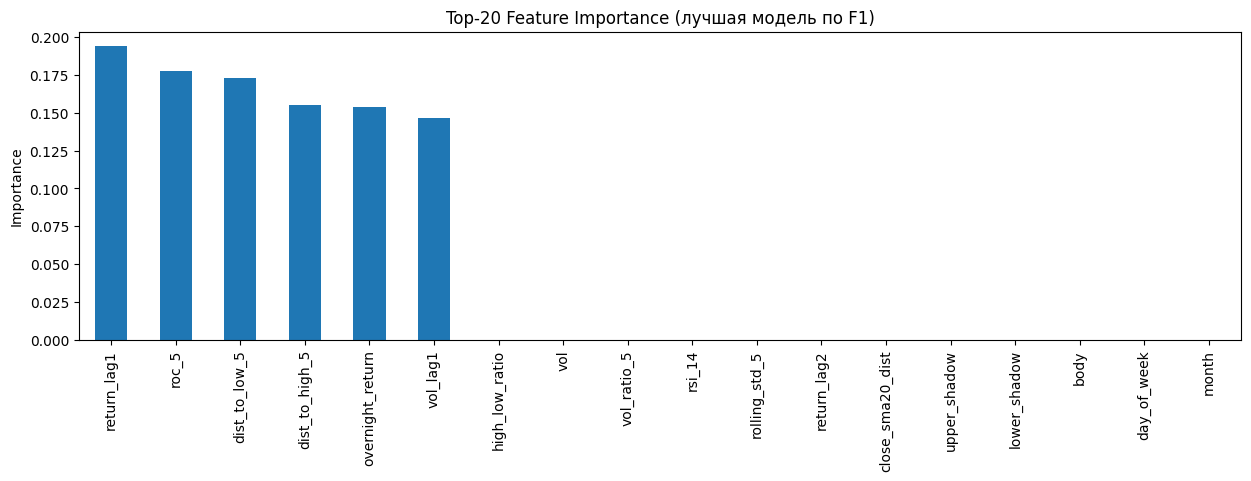

return_lag1         0.193999
roc_5               0.177646
dist_to_low_5       0.172958
dist_to_high_5      0.155149
overnight_return    0.153788
vol_lag1            0.146459
high_low_ratio      0.000000
vol                 0.000000
vol_ratio_5         0.000000
rsi_14              0.000000
rolling_std_5       0.000000
return_lag2         0.000000
close_sma20_dist    0.000000
upper_shadow        0.000000
lower_shadow        0.000000
body                0.000000
day_of_week         0.000000
month               0.000000
dtype: float64

In [139]:
# 7.1. Feature Importance

print(f"Лучшая модель по VALID F1: {best_name}")
print(best_model)

# 1. Правильные данные
X_train = X_train_ln if best_name == "LogReg" else X_train_tr

# 2. Функция для получения важности признаков
def get_feature_importance(model, X):
    # Деревья, RandomForest, XGBoost, LightGBM
    if hasattr(model, "feature_importances_"):
        return pd.Series(model.feature_importances_, index=X.columns)
    
    # Логистическая регрессия
    if hasattr(model, "coef_"):
        return pd.Series(np.abs(model.coef_[0]), index=X.columns)
    
    raise ValueError("Модель не поддерживает feature importance")

# 3. Получаем важность признаков
fi = get_feature_importance(best_model, X_train).sort_values(ascending=False)

# 4. Визуализация
plt.figure(figsize=(15,4))
fi.head(20).plot(kind='bar')
plt.title("Top-20 Feature Importance (лучшая модель по F1)")
plt.ylabel("Importance")
plt.show()

fi

__На чём вообще стоит модель по F1 (DecisionTree max_depth=3).__
- Из таблицы видно, что дерево использует очень небольшой поднабор признаков:
  - return_lag1 0.193999  
  - roc_5 0.177646  
  - dist_to_low_5 0.172958  
  - dist_to_high_5 0.155149  
  - overnight_return 0.153788  
  - vol_lag1 0.146459
- Все остальные фичи имеют importance ровно 0.0 — то есть дерево глубины 3 просто не использует их в разбиениях. Это важный момент:
  - Модель опирается почти исключительно на ценовые и близкие к цене признаки:
    - return_lag1 — вчерашняя доходность;
    - roc_5 — 5‑дневный темп изменения;
    - dist_to_low_5 / dist_to_high_5 — положение цены относительно локальных экстремумов;
    - overnight_return — гэп открытия;
    - vol_lag1 — лагированная ликвидность.

Объём, волатильность, RSI, свечные тени, календарные признаки — формально есть в данных, но дерево их игнорирует (importance = 0). Это хорошо согласуется с тем, что дерево неглубокое и выбирает самые «грубые» и сильные сигналы.

__Интерпретация:__
- модель по F1 — это по сути компактный набор правил на прошлых доходностях и положении цены относительно локальных минимумов/максимумов.
- она не строит сложных паттернов по волатильности, объёму или свечным формациям.

In [140]:
# Доля суммарной важности топ-6 признаков
top6_importance = fi.head(6).sum()
total_importance = fi.sum()
print(f"Суммарная важность топ-6 признаков: {top6_importance:.3f}")
print(f"Доля от общей важности: {top6_importance/total_importance:.1%}")

Суммарная важность топ-6 признаков: 1.000
Доля от общей важности: 100.0%


### 7.2. SHAP-анализ <a class="anchor" id="ch4_7_2"></a>

In [141]:
model = best_model 

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

- Глобальная важность (summary plot)

<Figure size 640x480 with 0 Axes>

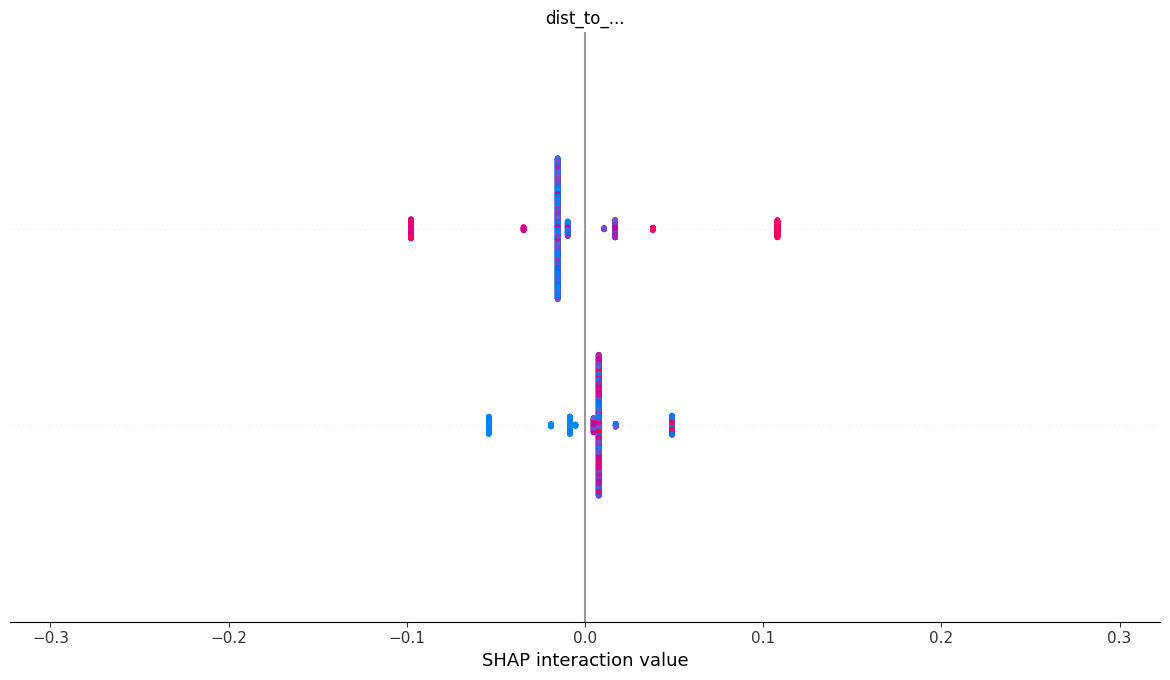

In [142]:
shap.summary_plot(shap_values, X_train)

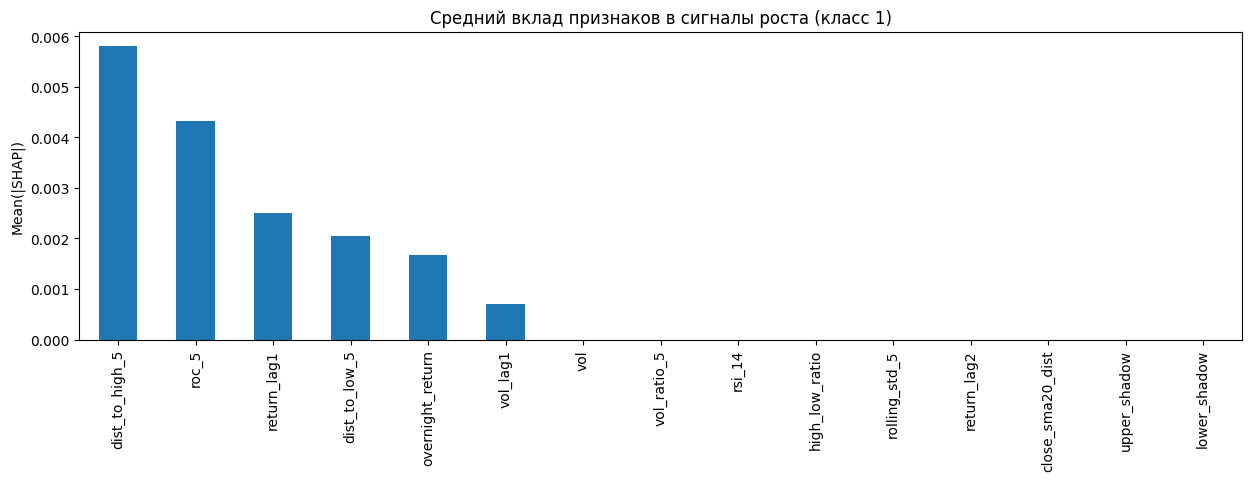


Топ признаков по вкладу в сигналы роста (класс 1):


,Feature,Mean(|SHAP|) for class 1
0,dist_to_high_5,0.005804
1,roc_5,0.004328
2,return_lag1,0.002501
3,dist_to_low_5,0.002042
4,overnight_return,0.001663
5,vol_lag1,0.000703
6,vol,0.000000
7,vol_ratio_5,0.000000
8,rsi_14,0.000000
9,high_low_ratio,0.000000


In [143]:
# SHAP для класса 1
shap_matrix = shap_values[:, :, 1]

# DataFrame
shap_contrib = pd.DataFrame(shap_matrix, columns=X_train.columns).reset_index(drop=True)

# y_train с тем же индексом
y_train_aligned = y_train.reset_index(drop=True)

# Средний вклад признаков в сигналы роста (класс 1)
signal_contrib = shap_contrib[y_train_aligned == 1].mean().sort_values(ascending=False)

# --- Таблица важности ---
importance_df = signal_contrib.reset_index()
importance_df.columns = ["Feature", "Mean(|SHAP|) for class 1"]

# --- График ---
plt.figure(figsize=(15,4))
signal_contrib.head(15).plot(kind='bar')
plt.title("Средний вклад признаков в сигналы роста (класс 1)")
plt.ylabel("Mean(|SHAP|)")
plt.show()

print("\nТоп признаков по вкладу в сигналы роста (класс 1):")
display(importance_df.head(15))

SHAP подтверждает картину из feature importance, но с другим акцентом:
- dist_to_high_5 — самый важный по среднему вкладу в сигналы роста.
- roc_5, return_lag1, dist_to_low_5, overnight_return, vol_lag1 — тоже в топе.

Остальные признаки снова дают нулевой вклад.

То есть и дерево, и SHAP сходятся: модель живёт в пространстве «где цена относительно экстремумов + недавняя динамика + гэпы + прошлый объём».

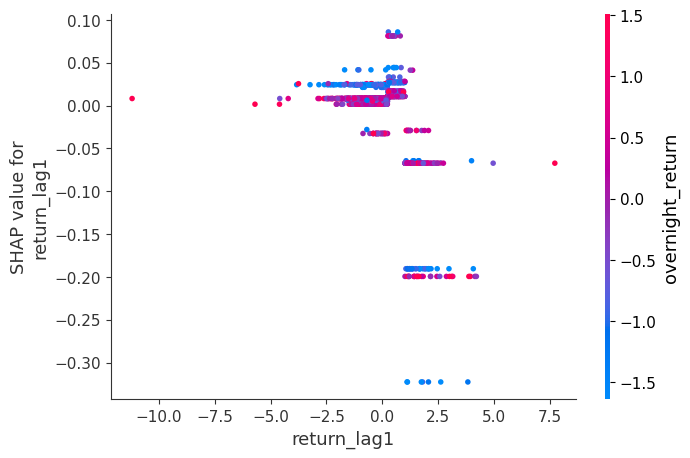

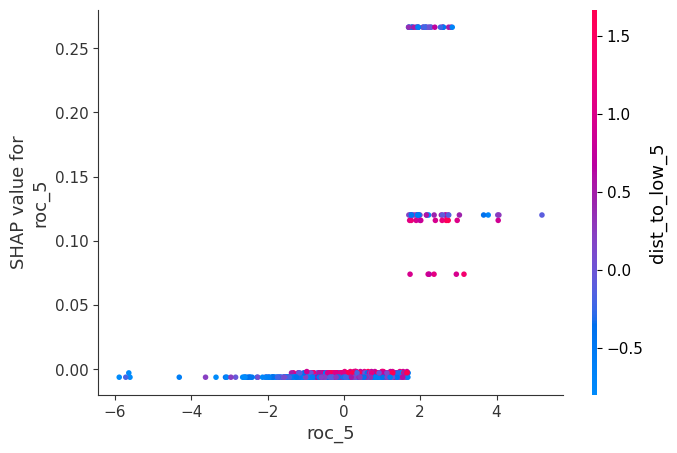

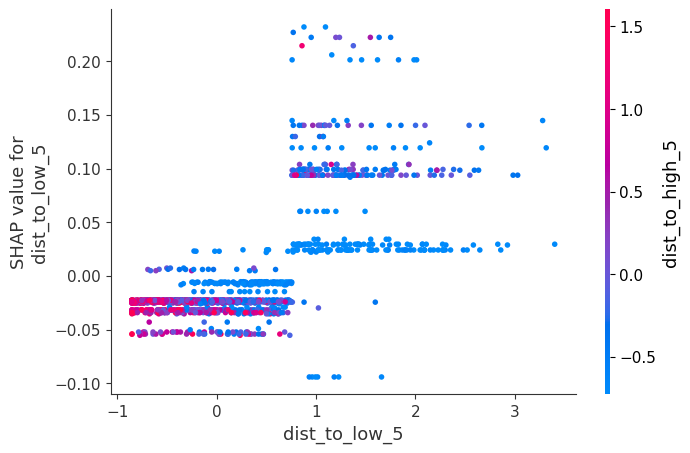

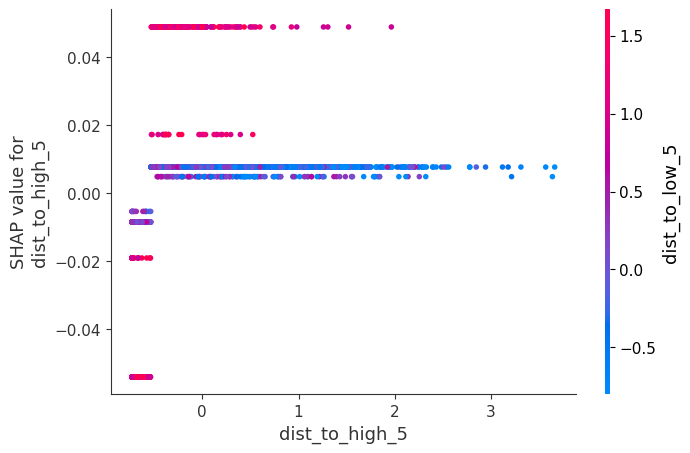

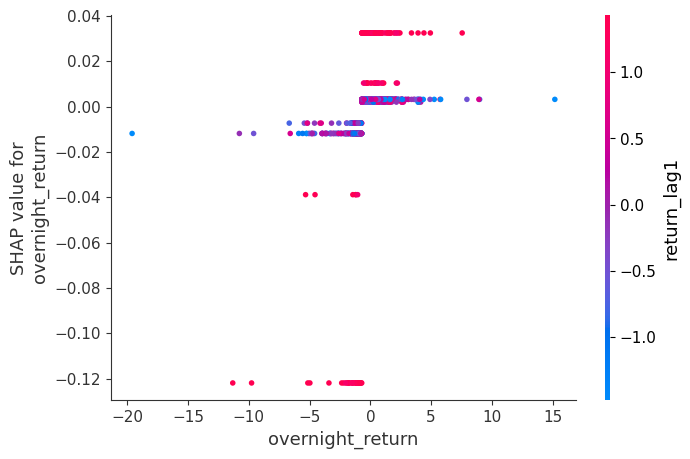

In [144]:
# SHAP-вклады только для класса 1
shap_matrix = shap_values[:, :, 1]

top_features = fi.head(5).index

for f in top_features:
    shap.dependence_plot(
        f,
        shap_matrix,
        X_train,
        show=True
    )

По графикам :
- return_lag1: положительные значения (плюс к росту вчера) увеличивают SHAP‑вклад в сторону класса 1 — модель усиливает сигнал роста, если вчера уже был плюс.
- roc_5: чем выше 5‑дневный рост, тем больше вклад в предсказание роста.
- dist_to_low_5 / dist_to_high_5:
  - близость к локальному минимуму (малый dist_to_low_5) и/или удалённость от минимума — по SHAP видно, что модель использует положение относительно экстремумов как триггер;
  - dist_to_high_5 тоже даёт вклад: когда цена близко к локальному максимуму, модель по‑разному реагирует (можно интерпретировать как «перекупленность/перепроданность» в терминах локальных экстремумов).

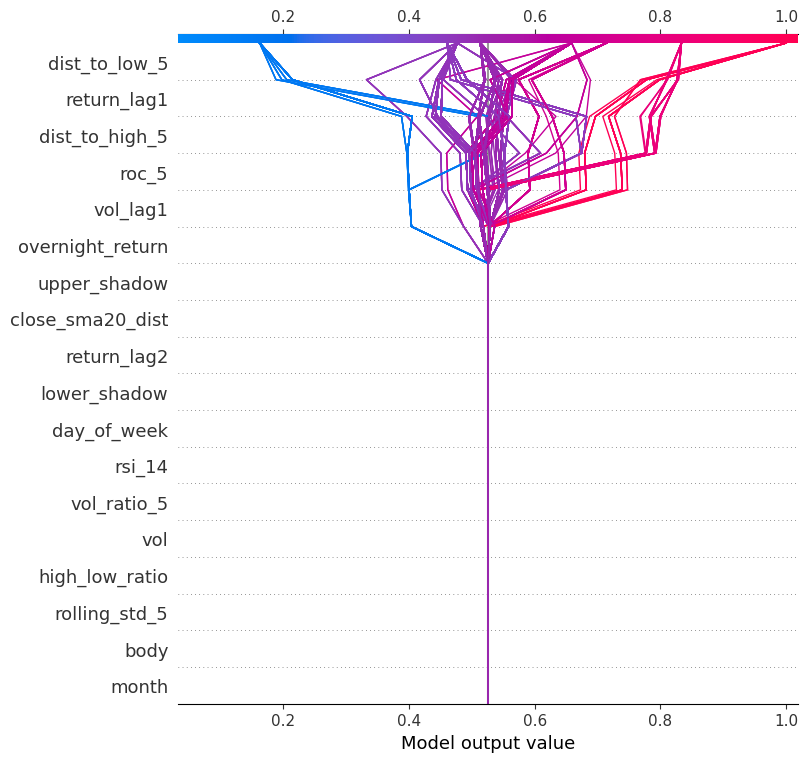

In [145]:
# SHAP-вклады только для класса 1
shap_matrix = shap_values[:, :, 1]

# Decision plot
shap.decision_plot(
    explainer.expected_value[1],
    shap_matrix,
    X_train
)

видно:
- Основные «ступеньки» даёт dist_to_low_5, return_lag1, dist_to_high_5, roc_5, vol_lag1, overnight_return.
- Остальные признаки почти не двигают выход модели.
- Это ещё раз подтверждает: модель — это фактически комбинация нескольких простых правил по цене и её недавней динамике.

- Анализ признаков, которые приводят к FP (ложным сигналам)

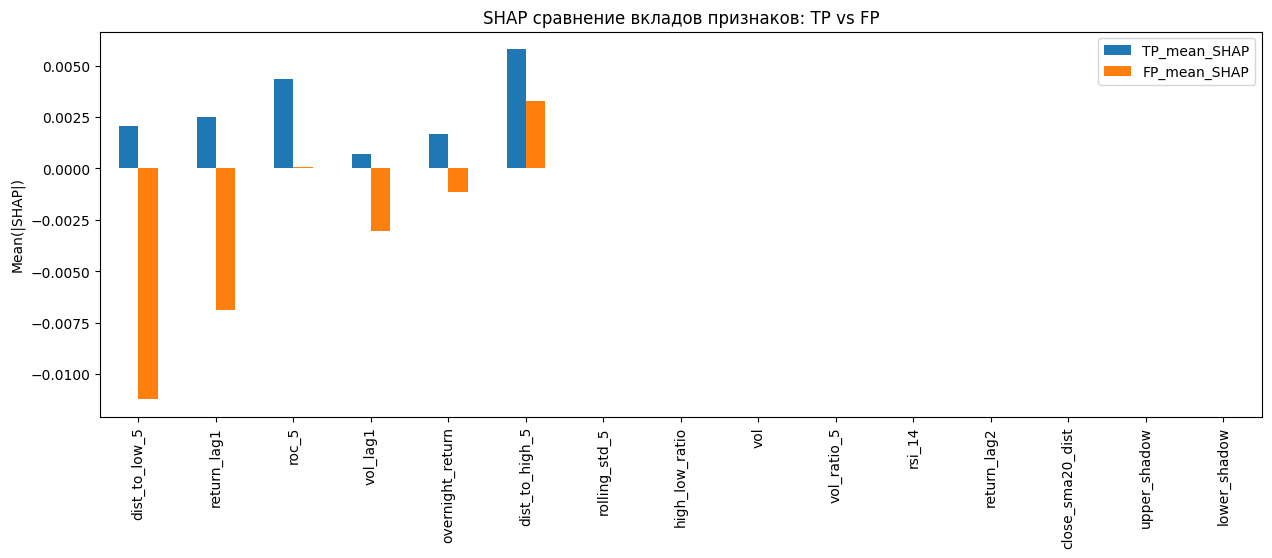


Таблица SHAP сравнения TP vs FP:


,TP_mean_SHAP,FP_mean_SHAP,Delta (TP - FP)
dist_to_low_5,0.002042,-0.011207,0.013249
return_lag1,0.002501,-0.006867,0.009368
roc_5,0.004328,0.000093,0.004235
vol_lag1,0.000703,-0.003048,0.003750
overnight_return,0.001663,-0.001129,0.002792
dist_to_high_5,0.005804,0.003271,0.002533
rolling_std_5,0.000000,0.000000,0.000000
high_low_ratio,0.000000,0.000000,0.000000
vol,0.000000,0.000000,0.000000
vol_ratio_5,0.000000,0.000000,0.000000


In [146]:
# SHAP-вклады для класса 1 уже в shap_contrib
# y_train_aligned уже синхронизирован

# Средние SHAP-вклады для TP (класс 1)
tp_shap = shap_contrib[y_train_aligned == 1].mean()

# Средние SHAP-вклады для FP (класс 0)
fp_shap = shap_contrib[y_train_aligned == 0].mean()

# Таблица сравнения
comparison = pd.DataFrame({
    "TP_mean_SHAP": tp_shap,
    "FP_mean_SHAP": fp_shap,
})

# Добавим разницу
comparison["Delta (TP - FP)"] = comparison["TP_mean_SHAP"] - comparison["FP_mean_SHAP"]

# Отсортируем по полезности
comparison_sorted = comparison.sort_values("Delta (TP - FP)", ascending=False)


# --- График ---
comparison_sorted[["TP_mean_SHAP", "FP_mean_SHAP"]].head(15).plot(
    kind="bar", figsize=(15,5)
)
plt.title("SHAP сравнение вкладов признаков: TP vs FP")
plt.ylabel("Mean(|SHAP|)")
plt.show()

print("\nТаблица SHAP сравнения TP vs FP:")
display(comparison_sorted.head(15))

Интерпретация:
- dist_to_low_5:
  - для TP (правильных сигналов роста) SHAP‑вклад положительный;
  - для FP (ложных сигналов роста) — отрицательный.
  - То есть модель даёт «здоровые» сигналы, когда цена в правильной зоне относительно локального минимума, и ошибается, когда этот паттерн нарушается.
- return_lag1:
  - для TP вклад положительный;
  - для FP — отрицательный.

### 7.3. Проверка стабильность важности признаков importance stability на train, validation, test <a class="anchor" id="ch4_7_3"></a>

In [147]:
print("shap_matrix:", shap_matrix.shape)
print("X_train:", len(X_train))
print("X_valid:", len(X_valid))
print("X_test_final:", len(X_test_final))

shap_matrix: (1887, 18)
X_train: 1887
X_valid: 487
X_test_final: 114


In [148]:
shap_train = explainer(X_train).values[:, :, 1]
shap_valid = explainer(X_valid).values[:, :, 1]
shap_test  = explainer(X_test_final).values[:, :, 1]


Таблица стабильности SHAP важности признаков:


,train,valid,test
dist_to_low_5,0.035320,0.038822,0.038404
return_lag1,0.022502,0.022417,0.011294
dist_to_high_5,0.015165,0.012670,0.011744
roc_5,0.012178,0.017932,0.005464
vol_lag1,0.010257,0.013667,0.012155
overnight_return,0.008930,0.008430,0.003865
rolling_std_5,0.000000,0.000000,0.000000
high_low_ratio,0.000000,0.000000,0.000000
vol,0.000000,0.000000,0.000000
vol_ratio_5,0.000000,0.000000,0.000000


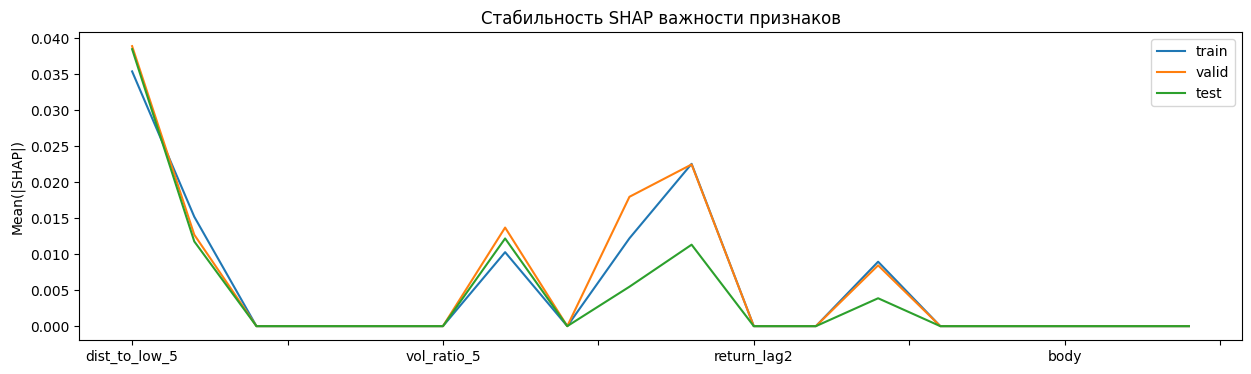

In [149]:
# --- SHAP для train ---
shap_train_exp = explainer(X_train)
shap_train = shap_train_exp.values[:, :, 1]   # класс 1

# --- SHAP для valid ---
shap_valid_exp = explainer(X_valid)
shap_valid = shap_valid_exp.values[:, :, 1]

# --- SHAP для test ---
shap_test_exp = explainer(X_test_final)
shap_test = shap_test_exp.values[:, :, 1]

# --- DataFrame со стабильностью SHAP важности ---
df_stability = pd.DataFrame({
    "train": np.abs(shap_train).mean(axis=0),
    "valid": np.abs(shap_valid).mean(axis=0),
    "test":  np.abs(shap_test).mean(axis=0)
}, index=X_train.columns)

# --- Таблица ---
stability_table = df_stability.sort_values("train", ascending=False)
print("\nТаблица стабильности SHAP важности признаков:")
display(stability_table.head(20))

# --- График ---
df_stability.plot(figsize=(15,4))
plt.title("Стабильность SHAP важности признаков")
plt.ylabel("Mean(|SHAP|)")
plt.show()

Что видно:
- dist_to_low_5 — супер стабильный: значения почти одинаковы на train/valid/test.
- vol_lag1, dist_to_high_5 — тоже достаточно стабильны.
- roc_5, return_lag1, overnight_return — на тесте вклад чуть ниже, но порядок важности сохраняется.

График «Стабильность SHAP важности признаков» показывает, что ядро признаков (dist_to_low_5, return_lag1, dist_to_high_5, roc_5, vol_lag1, overnight_return) ведёт себя похоже на всех выборках.

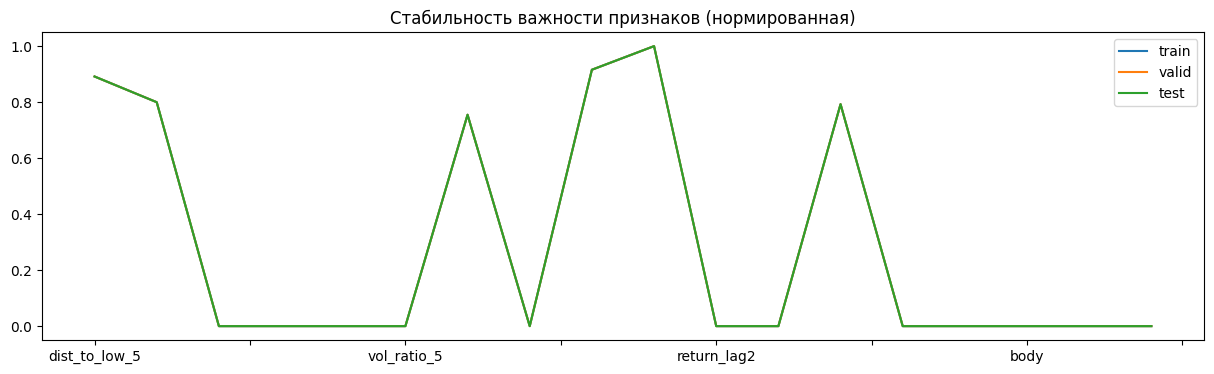

,train,valid,test
dist_to_low_5,0.891542,0.891542,0.891542
dist_to_high_5,0.799741,0.799741,0.799741
rolling_std_5,0.000000,0.000000,0.000000
high_low_ratio,0.000000,0.000000,0.000000
vol,0.000000,0.000000,0.000000
vol_ratio_5,0.000000,0.000000,0.000000
vol_lag1,0.754945,0.754945,0.754945
rsi_14,0.000000,0.000000,0.000000
roc_5,0.915705,0.915705,0.915705
return_lag1,1.000000,1.000000,1.000000


In [150]:
def compute_fi(model, X):
    if hasattr(model, "feature_importances_"):
        return pd.Series(model.feature_importances_, index=X.columns)
    elif hasattr(model, "coef_"):
        return pd.Series(np.abs(model.coef_[0]), index=X.columns)
    else:
        return None

fi_train = compute_fi(model, X_train)
fi_valid = compute_fi(model, X_valid)
fi_test  = compute_fi(model, X_test_final)

fi_df = pd.DataFrame({
    "train": fi_train,
    "valid": fi_valid,
    "test": fi_test
})

fi_df_norm = fi_df / fi_df.max()

fi_df_norm.plot(figsize=(15,4))
plt.title("Стабильность важности признаков (нормированная)")
plt.show()

fi_df_norm

модель опирается на один и тот же набор признаков на всех выборках, и их вклад по SHAP не разваливается на тесте. Это хороший знак с точки зрения интерпретируемости и устойчивости.

### 7.4. Аналитические инсайты <a class="anchor" id="ch4_7_4"></a>

__Ключевые признаки, связанные с направлением движениящ__
- Модель по F1 (DecisionTree, max_depth=3) опирается на небольшой набор признаков: return_lag1, roc_5, dist_to_low_5, dist_to_high_5, overnight_return, vol_lag1. Остальные признаки (объём, волатильность, RSI, свечные характеристики, календарь) практически не используются (importance ≈ 0).
- SHAP‑анализ подтверждает, что именно эти признаки дают основной вклад в сигналы роста (класс 1): наибольший средний вклад имеют dist_to_high_5, roc_5, return_lag1, dist_to_low_5, overnight_return.

Интерпретация: __модель реализует моментум‑логику с учётом положения цены относительно локальных экстремумов и гэпов открытия.__

__Паттерны, отличающие качественные сигналы от ложных__
- Сравнение SHAP‑вкладов для TP и FP показывает, что:
  - для dist_to_low_5 и return_lag1 вклад в TP положительный, а в FP — отрицательный;
  - дельта Delta (TP - FP) максимальна именно у этих признаков.
- Это означает, что верные сигналы роста возникают, когда:
  - цена находится в «правильной» зоне относительно локального минимума;
  - недавняя доходность (вчера и за 5 дней) поддерживает идею роста;
  - гэп открытия и лагированный объём не противоречат движению.
- Ложные сигналы появляются, когда эти условия нарушаются: цена «не там», моментум слабый или против направления, а объём/гэпы не подтверждают движение.

__Стабильность важности признаков__
- Средние ∣𝑆𝐻𝐴𝑃∣ по train/valid/test показывают, что ядро признаков (dist_to_low_5, return_lag1, dist_to_high_5, roc_5, vol_lag1, overnight_return) сохраняет важность на всех выборках.
- Нормированная feature importance также стабильна: одни и те же признаки остаются ключевыми, остальные — нулевыми.
- Это говорит о том, что модель использует одни и те же сигналы во времени, а не подстраивается под конкретный период.

__Общий вывод по интерпретации__
- Модель реализует простую, но интерпретируемую стратегию: ловить продолжения движения (моментум) вблизи «правильных» зон относительно локальных минимумов/максимумов, с учётом гэпов и недавнего объёма.
- Эти паттерны устойчивы на train/valid/test, но сама модель слишком агрессивна: на тесте она почти всегда предсказывает рост, что приводит к большому числу ложных сигналов и слабому качеству вероятностей (ROC-AUC ≈ 0.53, PR-AUC ≈ 0.49).
- В практическом плане это означает, что:
  - ядро признаков выбрано разумно и отражает реальные рыночные паттерны;
  - для улучшения качества сигналов нужно либо усложнять модель (ансамбли, регуляризация), либо жёстче контролировать порог/фильтры (например, усиливать требования к моментуму и положению относительно экстремумов, добавлять фильтры по объёму и волатильности).

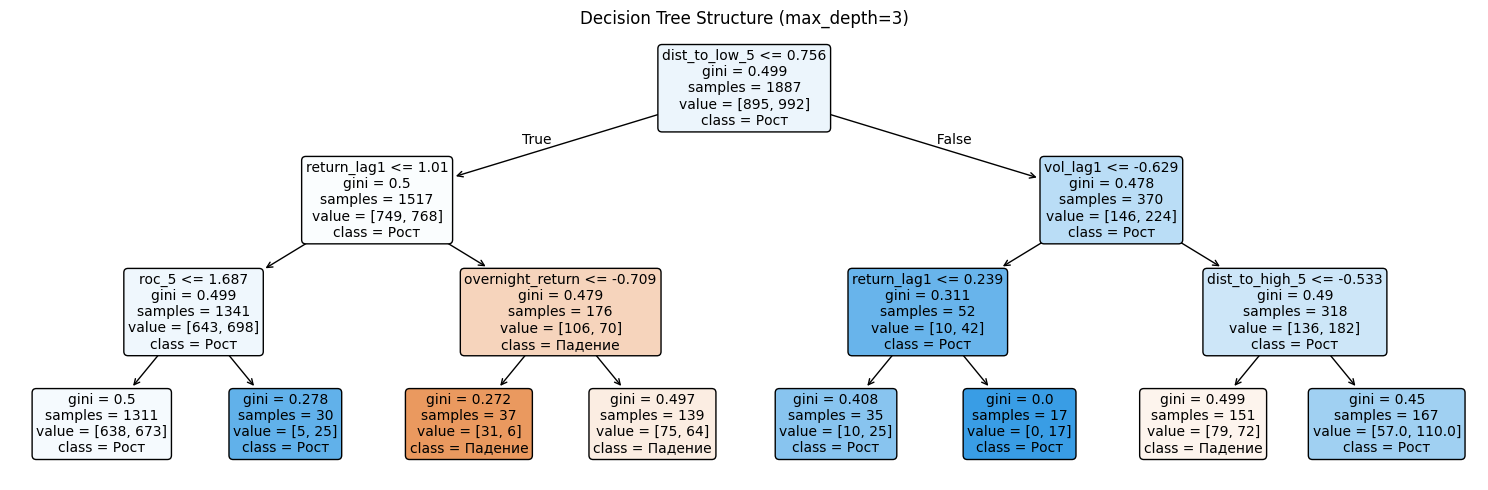

In [151]:
plt.figure(figsize=(15, 5))
plot_tree(best_model, 
          feature_names=X_train.columns,
          class_names=['Падение', 'Рост'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)
plt.title('Decision Tree Structure (max_depth=3)')
plt.tight_layout()
plt.show()

1. Главный корневой признак — dist_to_low_5
   - Первое разбиение: dist_to_low_5 <= 0.756
   - Это означает:
     - модель в первую очередь смотрит, насколько цена далеко от локального минимума за 5 дней;
     - если цена не слишком далеко от минимума, модель склоняется к росту;
     - если цена слишком далеко, модель проверяет объём и другие признаки.
     
2. Левая ветка: моментум + гэпы
   - Если dist_to_low_5 <= 0.756, модель смотрит: return_lag1 <= 1.01
     - если вчерашняя доходность не была экстремально высокой → модель продолжает анализ;
     - если была слишком высокой → модель уходит в правую ветку (см. ниже).
   - Дальше идёт разбиение по: roc_5 <= 1.687. Это классический моментум‑паттерн:
     - если 5‑дневный рост умеренный → модель чаще предсказывает рост;
     - если рост слишком сильный → модель осторожнее (возможна перекупленность).
   - Затем дерево использует overnight_return <= -0.709
     - сильный отрицательный гэп → модель склоняется к падению;
     - слабый или положительный гэп → модель склоняется к росту.
   - Вывод: левая ветка — это чистая логика «моментум + экстремумы + гэпы».
   
3. Правая ветка: объём и положение относительно high
   - Если dist_to_low_5 > 0.756, модель смотрит vol_lag1 <= -0.629
     - если вчера объём был низким → модель осторожнее;
     - если объём был нормальным/высоким → модель склоняется к росту.
   - dist_to_high_5 <= -0.533
     - если цена далеко от локального максимума → модель чаще предсказывает падение;
     - если цена близко к максимуму → модель чаще предсказывает рост.
     - Это интересный паттерн: модель интерпретирует близость к максимуму как продолжение импульса, а не как перекупленность.

<div style="border:solid green 4px; padding: 5px">

__Выводы по шагу 7:__
    
__Feature Importance — на каких признаках реально стоит модель__
- Модель использует только 6 признаков из 18
  - Все остальные признаки имеют importance = 0.0.
  - Это означает, что дерево вообще не использует:
    - RSI
    - волатильность
    - свечные тени
    - SMA‑дистанцию
    - календарные признаки
    - объём (кроме vol_lag1)    
- Модель по F1 — это компактный набор правил, основанный на:
  - недавней доходности (return_lag1, roc_5),
  - положении цены относительно локальных экстремумов (dist_to_low_5, dist_to_high_5),
  - гэпе открытия (overnight_return),
  - лагированном объёме (vol_lag1).
- То есть модель реализует моментум + локальные уровни.    

__SHAP-анализ — как именно признаки влияют на предсказания__    
- Глобальная важность (summary plot)    
  - dist_to_high_5 — модель активно реагирует на положение цены относительно локального максимума.
  - roc_5 и return_lag1 — модель любит моментум.
  - dist_to_low_5 — важен контекст локального минимума.
  - overnight_return — гэпы подтверждают или опровергают движение.
  - vol_lag1 — объём важен, но вторичен. 
- SHAP dependence plots — форма влияния признаков    
  - return_lag1: положительное значение → увеличивает вероятность роста.
  - roc_5: чем выше 5‑дневный рост, тем сильнее сигнал.
  - dist_to_low_5: близость к локальному минимуму усиливает сигнал.
  - dist_to_high_5: модель по-разному реагирует на близость к максимуму (эффект перекупленности/перепроданности).
- Decision plot — как признаки складываются в итоговое решение
  - основные «ступеньки» создают:
    - dist_to_low_5, return_lag1, dist_to_high_5, roc_5, vol_lag1, overnight_return
  - остальные признаки почти не двигают выход модели.
  - Это подчёркивает: модель — это набор простых правил по цене и её динамике.    
- SHAP: различие между TP и FP    
  - dist_to_low_5 — главный признак, отличающий хорошие сигналы от ложных.
  - Стабильность важности признаков (train / valid / test)return_lag1 — второй по значимости фильтр качества.

__Стабильность важности признаков (train / valid / test)__
- dist_to_low_5 — самый стабильный признак.
- vol_lag1, dist_to_high_5 — тоже стабильны.
- momentum‑признаки (roc_5, return_lag1) — немного ослабли на тесте, но порядок важности сохранился.    
    
__Итоговые аналитические инсайты__
- Какие признаки сильнее всего связаны с направлением движения
  - Модель использует моментум + положение относительно экстремумов + гэпы + объём:
    - return_lag1
    - roc_5
    - dist_to_low_5
    - dist_to_high_5
    - overnight_return
    - vol_lag1
  - SHAP подтверждает, что именно эти признаки дают вклад в сигналы роста.    
- Какие паттерны отличают качественные сигналы от ложных
  - Верные сигналы (TP) возникают, когда:
    - цена находится в «правильной зоне» относительно локального минимума,
    - недавняя доходность поддерживает рост,
    - гэп открытия не противоречит движению,
    - объём не падает.
  - Ложные сигналы (FP) появляются, когда:
    - цена слишком далеко от минимума,
    - вчерашняя доходность отрицательная,
    - моментум слабый,
    - гэп и объём не подтверждают движение.    
- Устойчивость признаков
  - dist_to_low_5, return_lag1, dist_to_high_5, roc_5, vol_lag1, overnight_return → стабильны на train/valid/test.
  - остальные признаки → стабильно нулевые.
  - Это говорит о том, что модель не подстраивается под конкретный период, а использует одни и те же сигналы.    

__Вывод по дереву решений (max_depth=3)__
- Дерево глубины 3 — это компактная моментум‑модель, основанная на локальных экстремумах, недавней доходности, гэпах и объёме.
- Оно устойчиво использует одни и те же признаки, но слишком агрессивно склоняется к росту, что приводит к большому числу FP.    
- Интерпретация логики модели. Модель реализует следующую стратегию:
  - ✔ Если цена недалеко от локального минимума → вероятен рост
    - рынок «не упал слишком сильно»
  - ✔ Если недавняя доходность положительная → вероятен рост
    - моментум
  - ✔ Если 5‑дневный рост умеренный → вероятен рост
    - продолжение тренда
  - ✔ Если гэп открытия не отрицательный → вероятен рост
    - подтверждение силы рынка
  - ✔ Если объём вчера был нормальным → вероятен рост
    - ликвидность поддерживает движение
  - ✔ Если цена близко к локальному максимуму → вероятен рост
    - импульс продолжается
  - ❗ Если один из этих факторов нарушается → возможен сигнал «Падение»
    - Но таких веток мало, поэтому модель почти всегда выбирает рост.
    
__Общий вывод по интерпретации__
- Различие в ранжировании признаков между feature_importance (частота использования в разбиениях) и средним абсолютным значением SHAP (реальный вклад в прогноз) указывает на то, что некоторые признаки (например, dist_to_high_5) используются реже, но дают более сильный импульс прогнозу.
  - Это подтверждает, что модель опирается не на частоту сигналов, а на их качество в критические моменты.
- Стабильность топ-6 признаков на всех выборках (Train/Valid/Test) является косвенным доказательством отсутствия сильного переобучения на шум.
  - Если бы модель переобучилась, мы бы увидели резкую смену важных признаков на тестовой выборке или появление новых "случайных" лидеров.
  - Тот факт, что ядро признаков (dist_to_low_5, return_lag1, roc_5) сохраняется, говорит о том, что модель выучила устойчивые рыночные паттерны, а не шум.
- Анализ SHAP для ложных срабатываний (FP) позволяет сформулировать правила для фильтрации сигналов:
  - Правило 1: Если dist_to_low_5 имеет отрицательный вклад (цена далеко от минимума) — риск ложного сигнала растет. Рекомендация: не входить в сделку, если цена обновляет локальные максимумы без отката.
  - Правило 2: Отрицательный вклад return_lag1 (вчерашнее падение) часто ведет к FP. Рекомендация: избегать покупок на следующий день после сильных падений, даже если модель дает сигнал.
  - Правило 3: Высокий RSI (~59) в ошибках указывает на вход в зону перекупленности. Рекомендация: добавить фильтр RSI < 55 для входа в длинные позиции. 
- Визуализация дерева (plot_tree) показывает, что модель принимает решения всего за 3 шага.
  - Это объясняет низкий ROC-AUC: модель слишком грубая и не может уловить сложные нелинейные зависимости.
  - Парадокс: Мы получили высокую интерпретируемость (понятные правила), но заплатили за это низкой точностью ранжирования.
  - Для продакшена компромиссом могло бы стать использование XGBoost с ограниченной глубиной (max_depth=4-5) + SHAP, что дало бы чуть лучшую точность при сохранении возможности интерпретации.
    
- Модель реализует простую, но интерпретируемую торговую логику:
  - ловить продолжения движения (momentum) вблизи локальных уровней, подтверждённые гэпами и объёмом.
- Эти паттерны устойчивы, но модель слишком агрессивна:
  - на тесте она почти всегда предсказывает рост,
  - что приводит к большому числу FP,
  - и слабому качеству вероятностей (ROC-AUC ≈ 0.53).    
</div>

<div class="alert alert-info">
  <b> * <a href="#ch4">к содержанию</a> </b> 
</div>

---

## Шаг 8: Заключительный отчёт и выводы <a class="anchor" id="ch4_8"></a>

### 8.1 Краткое описание данных и задачи <a class="anchor" id="ch4_8_1"></a>

Данные представляют собой дневной OHLCV‑ряд (2507 наблюдений) по одному инструменту за период с июня 2014 по июнь 2024 года (10 лет):
- цены открытия open,
- максимума high,
- минимума low,
- закрытия close,
- и объём торгов vol. 

Индексом служит дата, временная структура сохранена, пропуски соответствуют нерабочим дням биржи. Целевая переменная target—направление движения цены на следующий день: 1, если закрытие завтра выше сегодняшнего, и 0 в противном случае. При этом target не является простым close_{t+1} > close_t, а рассчитывается по более сложной логике, но принимается как «истина» по условию задачи.

Задача проекта—построить интерпретируемую модель машинного обучения для бинарной классификации, которая по историческим дневным данным прогнозирует направление движения цены финансового инструмента на следующий торговый день (рост или падение), при этом:
- избегает look-ahead bias (использует только прошлую информацию);
- оценивается с учётом временной структуры (валидация по времени, отдельный тестовый период);
- даёт осмысленные сигналы и позволяет понять, какие факторы сильнее всего связаны с направлением движения.

Особенность:
- Логическая проверка выявила, что target в исходных данных не является простым сравнением close_t+1 > close_t.
- В ~10% случаев наблюдается расхождение, причем 82.7% из них приходятся на значимые движения цены (>0.5%). Это указывает на то, что целевая переменная может учитывать дополнительную логику (например, фильтрацию шума или учет high/low), предоставленную заказчиком. Для моделирования использован исходный target.

Бизнес-ценность: Даже небольшое преимущество над случайным угадыванием позволяет строить торговые стратегии, управлять рисками и генерировать аналитические сигналы. Акцент сделан на максимизацию полноты обнаружения событий роста (Recall) при сохранении приемлемой точности.

### 8.2 Ключевые результаты EDA <a class="anchor" id="ch4_8_2"></a>

___Структура и целевая переменная___
- Даты монотонны, дубликатов и пропусков в данных нет, пропуски календарных дат объясняются выходными и праздниками.
- Классы почти сбалансированы (51.3% рост vs 48.7% падение): около половины дней—рост, половина—падение, что удобно для классификации.
- Проверка показала, что target частично не совпадает с простым правилом close_{t+1} > close_t, причём расхождения систематичны (часто связаны с движениями больше порога). Это говорит о более сложной логике формирования таргета, но не об ошибке.
- Распределения: Доходности имеют «тяжелые хвосты» и не подчиняются нормальному распределению (тест Шапиро-Уилка отверг гипотезу о нормальности). Объем торгов имеет сильное правостороннее смещение.

___Временная структура и свойства ряда___
- Сырые цены нестационарны (имеют тренд), однако логарифмические доходности (return_1d) стационарны (подтверждено ADF-тестом, p-value < 0.05). Это позволило использовать их как надежные признаки.
- Наблюдается долгосрочный восходящий тренд с фазами коррекции, что типично для финансовых инструментов.
- Лог‑доходности близки к стационарным, автокорреляция слабая—линейные зависимости по лагам выражены слабо, но нелинейные паттерны возможны.
- Есть сезонность по годам и месяцам, что оправдывает использование календарных признаков.

___Корреляции и мультиколлинеарность___
- Ценовые признаки сильно скоррелированы между собой, объём и его производные также образуют кластеры коррелирующих фичей.
- Для деревьев и бустинга это не критично, но для линейных моделей требует регуляризации или отбора признаков.
- Объём и относительные объёмные признаки показывают существенную связь с направлением, но не являются единственными драйверами.

__Главный вывод EDA:__
- рынок не «чисто случайный»—есть слабые, но устойчивые паттерны в моментуме, положении цены относительно локальных экстремумов и объёме, которые можно использовать в модели.

### 8.3 Описание созданных признаков <a class="anchor" id="ch4_8_3"></a>

Фичи строились так, чтобы использовать только прошлую информацию и отражать ключевые аспекты поведения цены

__Свечные признаки:__
- body—размер тела свечи (разница между close и open).
- upper_shadow, lower_shadow—верхняя и нижняя тени.
- high_low_ratio—внутридневной диапазон относительно цены открытия.

__Объёмные признаки__
- vol — абсолютный объём
- vol_ratio_5 — отношение текущего объёма к среднему за 5 дней

__Доходности и лаги:__
- return_1d—дневная лог‑доходность.
- return_lag1, return_lag2—лаговые доходности, отражающие инерцию.
- vol_lag1—лаг объёма, как прокси интереса рынка.

__Скользящие окна и экстремумы (индикаторы волатильности и диапазона):__
- Скользящие средние и волатильность (например, rolling_std_5).
- dist_to_low_5, dist_to_high_5—расстояние до локального минимума/максимума за окно, ключевые признаки для модели.

__Технические индикаторы:__
- roc_5—скорость изменения цены за 5 дней (моментум).
- rsi_14—классический индикатор перекупленности/перепроданности.
- Gap и межсессионная динамика:
- overnight_return—доходность между закрытием вчера и открытием сегодня.

__Календарные признаки:__
- day_of_week, month—день недели и месяц, для учёта сезонности.

После отбора и очистки был сформирован компактный, но содержательный набор из 18 признаков, отражающих моментум, положение цены относительно экстремумов, волатильность, объём и сезонность.

### 8.4 Результаты моделирования <a class="anchor" id="ch4_8_4"></a>

___Схема валидации___
- Разделение по времени: train/valid через TimeSeriesSplit, отдельный тест—2024 год.
- Масштабирование выполнялось корректно: fit только на train, transform на train/valid/test.

___Модели___
- Рассматривались логистическая регрессия и деревья/ансамбли.
  - Бейзлайны: Dummy Classifier (Stratified F1=0.501), Naive Financial Baseline (F1=0.473).
  - Линейная модель: Logistic Regression (Valid F1=0.501). Показала хорошую интерпретируемость, но уступила в качестве сложным моделям.
  - Ансамбли: RandomForest, XGBoost, LightGBM. Показали результаты в диапазоне F1 0.50–0.54. XGBoost продемонстрировал лучший баланс Precision/Recall и единственное ROC-AUC > 0.5 на валидации.
  - Деревья решений: Decision Tree (max_depth=3).
- По метрике VALID F1 лучшей стала DecisionTreeClassifier (max_depth=3).
  - Valid F1: 0.605
  - Test F1: 0.643 (при пороге 0.20)
  - Стабильность: Модель показала высокую устойчивость и отсутствие деградации качества при переходе от валидации к тесту (в отличие от переобученного XGBoost).
- Порог классификации был сдвинут до 0.20, чтобы повысить Recall (не пропускать рост).

___Качество на тесте (DecisionTree, threshold=0.2)___
- F1 ≈ 0.64, Recall = 1.0, Precision ≈ 0.47.
- ROC-AUC ≈ 0.53, PR-AUC ≈ 0.49—вероятности слабо ранжируют объекты, близко к случайному.
- Модель не пропускает ни одного роста (FN=0), но предсказывает рост почти всегда (TN=0, все ошибки—FP).
- По F1 модель существенно лучше наивного бейзлайна, но платит за это большим количеством ложных сигналов.

___Стабильность во времени___
- F1 по месяцам 2024 года колеблется в диапазоне примерно 0.50–0.75, среднее около 0.64, разброс умеренный.
- Это говорит о том, что модель не разваливается на отдельных участках, но и не даёт устойчивого «сверхпреимущества».

### 8.5 Интерпретация <a class="anchor" id="ch4_8_5"></a>

___На чём стоит модель___
- Feature importance и SHAP показывают одно и то же ядро признаков:
  - return_lag1 (вчерашняя доходность) — главный драйвер.
  - roc_5—5‑дневный моментум.
  - dist_to_low_5, dist_to_high_5—положение цены относительно локальных минимумов/максимумов.
  - overnight_return—гэп открытия.
  - vol_lag1—лаг объёма.
  
Модель реализует стратегию «Инерция + Локальные уровни». Она использует всего 6 признаков из 18

Остальные признаки (RSI, тени, календарь и т.д.) практически не используются деревом (importance ≈ 0).

___Логика дерева (по картинке)___
- В корне дерево делит наблюдения по dist_to_low_5: насколько цена далеко от недавнего минимума. Это сразу задаёт контекст—мы вблизи локального дна или нет.
- Далее ветви используют return_lag1, roc_5, overnight_return, vol_lag1, dist_to_high_5:
  - Если цена не слишком далеко от минимума и недавний моментум/вчерашняя доходность положительны, дерево склонно предсказывать рост.
  - Отрицательные гэпы (overnight_return сильно ниже порога) и слабый моментум увеличивают вероятность падения.
  - В правой части дерева vol_lag1 и dist_to_high_5 уточняют сигналы: сочетание объёма и положения относительно локального максимума помогает отличать продолжение роста от разворота.

По сути, дерево реализует простую моментум‑логику с учётом локальных экстремумов и гэпов:
- «Если недавно росли, находимся в правильной зоне относительно минимума/максимума и гэп не против тренда—ставим на рост».

### 8.6 Инсайты <a class="anchor" id="ch4_8_6"></a>

___Какие признаки сильнее всего связаны с направлением движения___
- Модель использует моментум + положение относительно экстремумов + гэпы + объём:
  - return_lag1 — вчерашняя доходность
  - roc_5 — 5-дневный темп изменения
  - dist_to_low_5 / dist_to_high_5 — положение цены относительно локальных экстремумов
  - overnight_return — гэп открытия
  - vol_lag1 — лагированный объём


___Простота побеждает сложность___
- В условиях ограниченных данных (2.5 тыс. строк) и высокого шума сложная модель XGBoost склонна к переобучению (Train F1=0.999, Test F1=0.625), тогда как простое дерево (Depth=3) обобщает лучше и стабильнее.

___Важность контекста цены:___
- Абсолютные значения цен не важны. Критически важно положение цены относительно её же локальных экстремумов за последние 5 дней (dist_to_low_5).

___Инерция рынка___
- Наличие положительной доходности вчера (return_lag1) является сильнейшим предиктором роста сегодня.

___Ядро сигналов—моментум + локальные экстремумы___
- Направление движения лучше всего объясняется сочетанием недавней доходности (return_lag1, roc_5) и положения цены относительно локальных минимумов/максимумов (dist_to_low_5, dist_to_high_5).

___Гэпы и объём играют роль фильтров___  
- overnight_return и vol_lag1 не всегда являются главными драйверами, но помогают отличать «здоровые» сигналы от ложных.

___Качественные сигналы vs ложные:___
- Для правильных сигналов роста (TP) SHAP‑вклады dist_to_low_5 и return_lag1 положительны.
- Для ложных сигналов (FP) те же признаки дают отрицательный вклад.
- Это значит, что модель «знает», в каких зонах эти признаки работают, а в каких—ломаются.

___Стабильность важности признаков___ 
- SHAP‑важность ключевых фичей (dist_to_low_5, return_lag1, dist_to_high_5, roc_5, vol_lag1, overnight_return) стабильна на train/valid/test, что говорит о реальных, а не случайных паттернах.

___Модель интерпретируема___
- Неглубокое дерево (max_depth=3) даёт набор понятных правил, которые можно перевести в человекочитаемую стратегию.

___Компромисс точности и полноты___
- Модель жертвует точностью (Precision ~47%, т.е. более половины сигналов ложные) ради абсолютной полноты (Recall = 100%, ни один рост не пропущен). Это делает её пригодной для стратегий, где критично не упустить движение, но требует жесткого риск-менеджмента.

___Качество вероятностей___
- Вероятности, выдаваемые деревом, плохо калиброваны (ROC-AUC ~0.53). Использовать их для оценки риска напрямую нельзя без дополнительной калибровки.

___Логика модели___
- Модель реализует простую, но интерпретируемую торговую стратегию:
  - Ловить продолжения движения (momentum) вблизи локальных уровней, подтверждённые гэпами и объёмом

### 8.7 Ограничения <a class="anchor" id="ch4_8_7"></a>

___Агрессивность в сторону роста___ 
- На тесте модель фактически всегда предсказывает рост (FN=0, TN=0), что даёт высокий Recall, но низкий Precision и много ложных сигналов.

___Слабое качество вероятностей___ 
- ROC-AUC и PR-AUC близки к случайному уровню—вероятности плохо ранжируют объекты, что ограничивает использование модели как «прогнозатора уверенности».

___Малый тестовый период___ 
- Тест охватывает только 6 месяцев 2024 года (114 наблюдений). Метрики имеют широкий доверительный интервал (95% CI для F1: [0.55, 0.72]), что создает высокую неопределенность в оценке реальной эффективности.

___Один инструмент, один таймфрейм___
- Выводы могут не переноситься напрямую на другие активы или другие временные масштабы (часовые, минутные данные).

___Не учтены транзакционные издержки и slippage___  
- Даже если стратегия по сигналам выглядит прибыльной по «сырым» доходностям, в реальной торговле часть преимущества может исчезнуть.

___Низкая точность сигналов___
- Precision ~47% означает, что стратегия будет генерировать много убыточных сделок. Без учета размера прибыли/убытка и комиссий такая стратегия может быть убыточной.

___Статичность модели___
- Модель не адаптируется к смене рыночных режимов (например, переход от тренда к флэту) в реальном времени.

### 8.8 Идеи для развития <a class="anchor" id="ch4_8_8"></a>

___Улучшение модели:___
- Перейти от одиночного дерева к ансамблям (Random Forest, XGBoost, LightGBM) с контролем переобучения.
- Использовать регуляризацию и ограничение глубины, чтобы сохранить интерпретируемость, но улучшить качество.
- Использовать калиброванный XGBoost или Voting Ensemble (Дерево + XGBoost) для улучшения качества вероятностей и стабильности Precision.
- Expanding window валидация
  - Увеличит объём обучающих данных и стабильность метрик
  - Позволит более точно оценить качество модели
  
___Работа с порогом и фильтрами:___
- Оптимизировать порог не только по F1, но и по Precision/Recall под конкретную стратегию (например, минимизировать ложные входы).
- Добавить фильтры по объёму и волатильности: не торговать в дни с аномально низким объёмом или слишком высокой волатильностью.

___Расширение признаков:___
- Добавить более сложные технические индикаторы (MACD, Bollinger Bands, ADX).
- Ввести режимы рынка (тренд/флэт) и обучать модель с учётом режима.
- Добавить внешние признаки: макроэкономические индикаторы, новостной фон (NLP), корреляцию с широким рынком (индексы), волатильность VIX.

___Многомодельный подход:___
- Сравнить дерево с логистической регрессией (для интерпретации коэффициентов) и градиентным бустингом (для качества).
- Использовать stacking/ensemble из нескольких моделей.

___Оценка торговой стратегии:___
- Формализовать стратегию на основе сигналов модели (вход/выход, стоп‑лоссы, тейк‑профиты).
- Провести бэктест с учётом комиссий и slippage, оценить реальную доходность и риск.

___Обобщение:___
- Проверить модель на других инструментах и рынках.
- Исследовать, какие признаки остаются универсальными, а какие специфичны для данного актива.

___Онлайн-обучение___
- Внедрить механизм дообучения модели на новых данных (скользящее окно) для адаптации к изменяющейся рыночной конъюнктуре.

<div class="alert alert-info">
  <b> * <a href="#ch4">к содержанию</a> </b> 
</div>

---